# Imports

In [1]:
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# from scipy.interpolate import RegularGridInterpolator
# from scipy.interpolate import interp1d

import aespm as ae


In [2]:
HAVE_AESPM  = True
import json

CONFIG = dict(
    # --- paths -----------------------------------------------------------
    data_folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260717\PZTO",
    work_dir    = "output",      # trajectories + logs live here

    # --- microscope / litho ------------------------------------------------
    DRY_RUN       = False,    # False at the microscope
    field_um      = 2.0,     # litho field size (square, corner origin)
    write_speed_ums = 1.0,   # tip speed during litho
    step_um       = 0.02,    # point spacing along trajectory (sets dose uniformity)
    travel_v      = 0.0,     # bias during repositioning strokes
    litho_margin_s = 10.0,   # extra wait after estimated litho duration

    # --- PFM readout ---------------------------------------------------------
    chan_height = 0, chan_amp = 1, chan_phase = 3,   # ibw channel indices (as in v1)
    scan_px     = 256,

    # --- material: PZTO(111), three easy axes at 120 deg --------------------
    # axis0_offset_deg is the lab-frame angle of the first easy axis;
    # you will refine it from the pristine stripe orientations / Session A.
    axis0_offset_deg = 0.0,
    n_variants  = 6,
    easy_axes_deg = None,    # filled below

    # --- switching physics (seed values; Session A refines) -----------------
    v_coercive_guess = 4.0,  # |V| onset (Checa: 4-6 V in PSTO; measure yours)
    v_write          = 6.0,
    # bias sign convention: +1 if positive tip bias selects the variant
    # PARALLEL to tip motion, -1 if anti-parallel (Balke-style). Session A decides.
    bias_sign_convention = -1,
    linewidth_um_guess   = 0.12,   # written track width (from first line tests)
)
CONFIG["easy_axes_deg"] = [CONFIG["axis0_offset_deg"] + k*60 for k in range(6)]
os.makedirs(CONFIG["work_dir"], exist_ok=True)
if not HAVE_AESPM:
    CONFIG["DRY_RUN"] = True
print(json.dumps({k: v for k, v in CONFIG.items() if k != "easy_axes_deg"}, indent=1))
print("easy axes:", CONFIG["easy_axes_deg"])

{
 "data_folder": "C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260717\\PZTO",
 "work_dir": "output",
 "DRY_RUN": false,
 "field_um": 2.0,
 "write_speed_ums": 1.0,
 "step_um": 0.02,
 "travel_v": 0.0,
 "litho_margin_s": 10.0,
 "chan_height": 0,
 "chan_amp": 1,
 "chan_phase": 3,
 "scan_px": 256,
 "axis0_offset_deg": 0.0,
 "n_variants": 6,
 "v_coercive_guess": 4.0,
 "v_write": 6.0,
 "bias_sign_convention": -1,
 "linewidth_um_guess": 0.12
}
easy axes: [0.0, 60.0, 120.0, 180.0, 240.0, 300.0]


# Create exp object

In [3]:
# connection, client = return_connection(host, username, password)

# Read the scan line

folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260806\PZTO"

exp = ae.Experiment(folder=folder)


In [4]:
## Commonly used custom functions

def load_ibw(self, folder="C:\\Users\\Asylum User\\Documents\\AEtesting\\data_exchange", lines=False):
    '''
    Read the latest ibw file saved in a given folder.
    '''
    fname = ae.get_files(path=self.folder, client=self.client)[0]
    return ae.tools.load_ibw(fname)

exp.add_func(load_ibw)

def read_meter(self):
    ae.write_spm(commands="GetMeter()", connection=self.connection)
    w = ae.ibw_read(r"C:\Users\Asylum User\Documents\buffer\Meter.ibw", lines=True, connection=self.connection)
    return w

exp.add_func(read_meter)

# def ramp_drive_setpoint(self, drive, setpoint):
#     commands='SetDriveAmpAndSetpoint({}, {})'.format(drive, setpoint)
#     ae.write_spm(commands=commands, connection=self.connection)
    
# exp.add_func(ramp_drive_setpoint)

def check_files(self, wait=360):
    '''
    Check the number of files in the folder, with 50 s max waiting time.
    '''
    return ae.check_file_number(path=self.folder, retry=int(wait/0.1))
exp.add_func(check_files)

# Pre-define trajectorylitho related functions

In [5]:
def generate_spiral_trajectory(
    turns=6,
    n_points=1200,
    k=1.0,
    offset=0.0,
    v_amplitude=8.0,
    v_offset=0.0,
    field_um=20.0,
    max_radius_um=None,
    filename="spiral_trajectory.txt",
    include_header=True,
    plot=True,
    constant_v=False
):
    """
    Build an Archimedean-spiral (x, y, V) trajectory and save it as a 3-column
    text file for the Igor TrajectoryLitho panel.

    Coordinates are written in METRES, corner origin (0..field), spiral centred
    at (field/2, field/2).  Voltage:  v_amplitude*sin(k*theta + offset) + v_offset.

    Parameters
    ----------
    turns         : full revolutions of the spiral.
    n_points      : number of points along the path.
    k             : angular-frequency multiplier inside the sine.
    offset        : phase offset (radians) inside the sine.
    v_amplitude   : sinusoid amplitude (V).
    v_offset      : DC offset added to the bias (V).
    field_um      : square litho field size in micrometres.
    max_radius_um : outer spiral radius (um). Default 0.95*field/2; must be <= field/2.
    filename      : output .txt path.
    include_header: write a commented header row.
    plot          : show an inline preview.

    Returns
    -------
    (x_m, y_m, v) numpy arrays.
    """
    field_m = field_um * 1e-6
    cx = cy = field_m / 2.0

    if max_radius_um is None:
        max_radius_m = 0.95 * field_m / 2.0
    else:
        max_radius_m = max_radius_um * 1e-6
        if max_radius_m > field_m / 2.0:
            raise ValueError(
                f"max_radius_um ({max_radius_um}) exceeds half the field "
                f"({field_um/2}); the spiral would fall outside the field."
            )

    theta = np.linspace(0.0, turns * 2.0 * np.pi, n_points)
    theta_max = turns * 2.0 * np.pi
    a = max_radius_m / theta_max if theta_max > 0 else 0.0
    r = a * theta

    x_m = cx + r * np.cos(theta)
    y_m = cy + r * np.sin(theta)
    if constant_v:
        v = v_amplitude * np.ones(len(theta))
    else:
        
        v   = v_amplitude * np.sin(k * theta + offset) + v_offset

    data = np.column_stack([x_m, y_m, v])
    header = "X_m\tY_m\tV" if include_header else ""
    np.savetxt(filename, data, delimiter="\t",
               header=header, comments="# ", fmt="%.10g")

    print(f"Wrote {n_points} points to '{filename}'")
    print(f"  field = {field_um} um, center = ({field_um/2}, {field_um/2}) um")
    print(f"  outer radius = {max_radius_m*1e6:.3f} um, turns = {turns}")
    print(f"  X range: [{x_m.min()*1e6:.3f}, {x_m.max()*1e6:.3f}] um")
    print(f"  Y range: [{y_m.min()*1e6:.3f}, {y_m.max()*1e6:.3f}] um")
    print(f"  V = {v_amplitude}*sin({k}*theta + {offset}) + {v_offset}")
    print(f"  V range: [{v.min():.3f}, {v.max():.3f}] V")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
        sc = ax1.scatter(x_m*1e6, y_m*1e6, c=v, cmap="rainbow", s=6)
        ax1.add_patch(plt.Rectangle((0, 0), field_um, field_um,
                                    fill=False, ls="--", ec="k"))
        ax1.set_aspect("equal")
        ax1.set_xlabel("X (um)"); ax1.set_ylabel("Y (um)")
        ax1.set_title("Spiral trajectory (color = bias)")
        fig.colorbar(sc, ax=ax1, label="Bias (V)")

        ax2.plot(theta, v, lw=1)
        ax2.set_xlabel("theta (rad)"); ax2.set_ylabel("Bias (V)")
        ax2.set_title(f"V = {v_amplitude} sin({k} theta + {offset}) + {v_offset}")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return x_m, y_m, v

def visualize_trajectory(tb=None, x_m=None, y_m=None, v=None, *, filename=None,
                         field_um=None, title=None):
    """Same as v1, plus accepts a TrajectoryBuilder directly."""
    if tb is not None:
        x, y, v = tb.to_arrays(); x_m, y_m = x*1e-6, y*1e-6
        field_um = field_um or tb.field_um
    if filename is not None:
        d = np.loadtxt(filename); x_m, y_m, v = d[:,0], d[:,1], d[:,2]
        title = title or f"Trajectory from '{filename}'"
    x_um, y_um, v = np.asarray(x_m)*1e6, np.asarray(y_m)*1e6, np.asarray(v)
    finite = np.isfinite(x_um) & np.isfinite(y_um); idx = np.arange(len(x_um))
    fig = plt.figure(figsize=(13, 5.5)); gs = fig.add_gridspec(2,2,width_ratios=[1.3,1])
    ax0 = fig.add_subplot(gs[:,0])
    sc = ax0.scatter(x_um[finite], y_um[finite], c=v[finite], cmap="rainbow", s=6, zorder=3)
    ax0.plot(x_um, y_um, color="0.8", lw=.5, zorder=1)
    f = idx[finite]
    if len(f):
        ax0.scatter([x_um[f[0]]],[y_um[f[0]]],s=120,marker="o",facecolors="none",
                    edgecolors="g",lw=2,zorder=4,label="start")
        ax0.scatter([x_um[f[-1]]],[y_um[f[-1]]],s=120,marker="s",facecolors="none",
                    edgecolors="r",lw=2,zorder=4,label="end")
    fu = field_um or CONFIG["field_um"]
    ax0.add_patch(plt.Rectangle((0,0), fu, fu, fill=False, ls="--", ec="k"))
    ax0.set_aspect("equal"); ax0.set_xlabel("X (um)"); ax0.set_ylabel("Y (um)")
    ax0.set_title(title or "Trajectory (color = bias)"); ax0.legend(fontsize=8)
    fig.colorbar(sc, ax=ax0, label="Bias (V)", fraction=.046, pad=.04)
    ax1 = fig.add_subplot(gs[0,1]); ax1.plot(idx, v, lw=1)
    ax1.set_xlabel("point index"); ax1.set_ylabel("Bias (V)"); ax1.grid(alpha=.3)
    ax2 = fig.add_subplot(gs[1,1])
    step = np.hypot(np.diff(x_um), np.diff(y_um))
    ax2.plot(step, lw=1, color="C1"); ax2.set_xlabel("point index")
    ax2.set_ylabel("step (um)"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    


In [6]:
# ----------------------------------------------------------------------
# Low-level helpers
# ----------------------------------------------------------------------
def resample_constant_step(x_um, y_um, v, step_um):
    """Resample a polyline to constant arc-length step.

    The TL panel steps through points at a fixed rate, so constant point
    spacing => constant tip speed and constant bias dose per unit length.
    """
    x_um, y_um, v = map(np.asarray, (x_um, y_um, v))
    d = np.hypot(np.diff(x_um), np.diff(y_um))
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] == 0:
        return x_um[:1], y_um[:1], np.atleast_1d(v)[:1]
    n = max(2, int(np.ceil(s[-1] / step_um)) + 1)
    si = np.linspace(0, s[-1], n)
    return (np.interp(si, s, x_um), np.interp(si, s, y_um),
            np.interp(si, s, np.broadcast_to(v, x_um.shape)))


class TrajectoryBuilder:
    """Accumulate biased strokes; insert zero-bias travel moves between them.

    All coordinates in micrometres, corner origin (0..field_um), matching the
    convention of generate_spiral_trajectory in the original notebook.
    """

    def __init__(self, field_um=20.0, step_um=0.02, travel_v=0.0,
                 nan_breaks=False):
        self.field_um = field_um
        self.step_um = step_um
        self.travel_v = travel_v   # bias during repositioning (keep 0!)
        self.nan_breaks = nan_breaks  # PLACEHOLDER: only if TL supports NaN pen-up
        self._segs = []            # list of (x_um, y_um, v) arrays

    def stroke(self, pts_um, v):
        """Add a biased stroke. pts_um: (N,2) array; v: scalar or (N,) array."""
        pts_um = np.asarray(pts_um, float)
        x, y = pts_um[:, 0], pts_um[:, 1]
        x, y, vv = resample_constant_step(x, y, v, self.step_um)
        self._segs.append((x, y, vv))
        return self

    def to_arrays(self):
        """Concatenate strokes, inserting travel moves at travel_v."""
        xs, ys, vs = [], [], []
        for i, (x, y, v) in enumerate(self._segs):
            if i > 0:
                if self.nan_breaks:
                    xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
                else:
                    x0, y0 = xs[-1][-1], ys[-1][-1]
                    tx, ty, tv = resample_constant_step(
                        [x0, x[0]], [y0, y[0]], self.travel_v, self.step_um)
                    xs.append(tx); ys.append(ty); vs.append(tv)
            xs.append(x); ys.append(y); vs.append(v)
        return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))

    def save(self, filename, include_header=True):
        x_um, y_um, v = self.to_arrays()
        data = np.column_stack([x_um * 1e-6, y_um * 1e-6, v])
        header = "X_m\tY_m\tV" if include_header else ""
        np.savetxt(filename, data, delimiter="\t", header=header,
                   comments="# ", fmt="%.10g")
        finite = np.isfinite(x_um)
        d = np.hypot(np.diff(x_um[finite]), np.diff(y_um[finite]))
        print(f"Wrote {len(x_um)} pts to '{filename}'  "
              f"(path length {np.nansum(d):.1f} um, "
              f"{len(self._segs)} strokes)")
        return x_um * 1e-6, y_um * 1e-6, v

    def path_length_um(self):
        x, y, _ = self.to_arrays()
        m = np.isfinite(x)
        return float(np.nansum(np.hypot(np.diff(x[m]), np.diff(y[m]))))

 # New measurement

## Session 1

In [7]:
import numpy as np

# ----------------------------------------------------------------------
# FIX 1 — true stationary dwells (bypass arc-length resampling)
# ----------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Append n stationary points at xy_um, held at bias v.

    Deliberately bypasses resample_constant_step(): a stationary polyline has
    zero arc length, so that function collapses it to a single point and the
    bias-settle hold is lost.
    """
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self

TrajectoryBuilder.dwell = _dwell


# ----------------------------------------------------------------------
# FIX 2 — run-time estimate that counts dwell points
# ----------------------------------------------------------------------
def eta_s(tb, speed_ums, step_um=None, margin_s=10.0):
    """The TL panel steps points at a fixed rate R = speed/step, so run time is
    set by the POINT COUNT, not the path length."""
    x, _, _ = tb.to_arrays()
    step = tb.step_um if step_um is None else step_um
    return len(x) * step / speed_ums + margin_s


# ----------------------------------------------------------------------
# One patch of parallel lines: explicit pitch, selectable bias scheme
# ----------------------------------------------------------------------
def gen_line_patch(center_um, size_um=1.6, pitch_um=0.10, angle_deg=60.0,
                   scheme="bipolar", v=6.0, tb=None, field_um=7.0,
                   step_um=0.02, n_pt=10, travel_v=0.0):
    """Square patch of parallel strokes at fixed PITCH (not fixed row count).

    Pitch is the variable the sign/pitch test needs, so it is set directly in um
    rather than implied by n_rows/side as in gen_raster_backward.

    scheme
      "bipolar"     : forward +|v|, backward -|v|          (current design rule 2)
      "constant"    : forward +|v|, backward +|v|
      "alternating" : both passes of row k at +|v| (k even) or -|v| (k odd);
                      every individual stroke is unipolar, sign flips row to row
      "serpentine"  : ONE traversal per row at +|v|, direction alternating.
                      No retrace at all - the back-scan-free control.

    A settle dwell of n_pt points at the NEW voltage is inserted before every
    stroke whose bias differs from the previous one.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    half = size_um / 2.0

    n_rows = max(1, int(round(size_um / pitch_um)) + 1)
    lys = np.linspace(-half, half, n_rows) if n_rows > 1 else np.array([0.0])
    ends = np.array([-half, half])          # 2 endpoints; stroke() resamples

    def to_world(lx, ly):
        return cx + lx * c - ly * s, cy + lx * s + ly * c

    for k, ly in enumerate(lys):
        row = np.full(2, ly, float)

        if scheme == "serpentine":
            lx = ends if k % 2 == 0 else ends[::-1]
            wx, wy = to_world(lx, row)
            tb.dwell((wx[0], wy[0]), v, n_pt)
            tb.stroke(np.column_stack([wx, wy]), np.full(2, abs(v), float))
            continue

        if scheme == "bipolar":
            v_f, v_b = +abs(v), -abs(v)
        elif scheme == "constant":
            v_f = v_b = +abs(v)
        elif scheme == "alternating":
            v_f = v_b = (+abs(v) if k % 2 == 0 else -abs(v))
        else:
            raise ValueError(f"unknown scheme {scheme!r}")

        fx, fy = to_world(ends, row)
        tb.dwell((fx[0], fy[0]), v_f, n_pt)                     # settle to v_f
        tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

        if v_b != v_f:
            tb.dwell((fx[-1], fy[-1]), v_b, n_pt)               # settle to v_b
        bx, by = to_world(ends[::-1], row)
        tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

    return tb, n_rows


# ----------------------------------------------------------------------
# Session 1 sign/pitch test: four patches, four separate files
# ----------------------------------------------------------------------
def gen_sign_pitch_test(center_um=(3.5, 3.5), size_um=1.6, gap_um=0.8,
                        angle_deg=60.0, v=6.0,
                        pitch_dense_um=0.10, pitch_sparse_um=0.40,
                        field_um=7.0, step_um=0.02, n_pt=10,
                        work_dir=None, prefix="s1"):
    """Four 1-patch trajectory files laid out on a 2x2 grid in one area.

    Separate files on purpose: a single combined file would insert ~3 um
    zero-bias TRAVEL strokes between patches, straight across the unwritten
    reference regions - and a grounded pass is a write event. Four short runs
    with the tip engaged removes that confound entirely.

    Patch assignment (P1/P2 adjacent so the pitch comparison at fixed scheme
    carries the least spatial confound):
      P1  sparse  constant     reinforcement without adjacent-line cancellation
      P2  dense   constant     adjacent-line cancellation
      P3  dense   bipolar      what design rule 2 predicts is best
      P4  sparse  alternating  what the perpendicular-impulse rule predicts is best
    """
    work_dir = work_dir or CONFIG["work_dir"]
    th = np.deg2rad(angle_deg)
    bbox = size_um * (abs(np.cos(th)) + abs(np.sin(th)))   # rotated square bbox
    d = (bbox + gap_um) / 2.0
    cx, cy = center_um

    spec = [
        ("P1", (cx - d, cy - d), pitch_sparse_um, "constant"),
        ("P2", (cx + d, cy - d), pitch_dense_um,  "constant"),
        ("P3", (cx - d, cy + d), pitch_dense_um,  "bipolar"),
        ("P4", (cx + d, cy + d), pitch_sparse_um, "alternating"),
    ]

    manifest, combined = [], TrajectoryBuilder(field_um=field_um, step_um=step_um)
    for label, ctr, pitch, scheme in spec:
        tb, n_rows = gen_line_patch(ctr, size_um=size_um, pitch_um=pitch,
                                    angle_deg=angle_deg, scheme=scheme, v=v,
                                    field_um=field_um, step_um=step_um, n_pt=n_pt)
        fn = os.path.join(work_dir, f"{prefix}_{label}_{scheme}_p{pitch*1000:.0f}nm.txt")
        tb.save(fn)
        combined._segs.extend(tb._segs)                  # preview only
        manifest.append(dict(label=label, file=fn, center_um=ctr, pitch_um=pitch,
                             scheme=scheme, n_rows=n_rows,
                             n_pts=len(tb.to_arrays()[0]),
                             eta_s=eta_s(tb, 1.0)))

    print(f"\nangle {angle_deg} deg | patch {size_um} um | rotated bbox {bbox:.2f} um "
          f"| centre spacing {2*d:.2f} um | edge gap {gap_um} um")
    print(f"pattern extent {cx-d-bbox/2:.2f} to {cx+d+bbox/2:.2f} um\n")
    for m in manifest:
        print(f"  {m['label']}  {m['scheme']:11s} pitch {m['pitch_um']*1000:4.0f} nm  "
              f"{m['n_rows']:3d} lines  {m['n_pts']:6d} pts  "
              f"ETA {m['eta_s']:5.0f} s @1 um/s  centre {m['center_um']}")
    print(f"\n  total ETA {sum(m['eta_s'] for m in manifest):.0f} s")
    return manifest, combined


In [8]:
# FIX 3 - do not inject a travel point when there is no gap to travel
def _to_arrays(self):
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:      # only if there IS a gap
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))

TrajectoryBuilder.to_arrays = _to_arrays

In [9]:
def audit_trajectories(manifest, field_um=7.0, scan_um=None, expect_pitch_um=None,
                       zoom_label=None):
    """Read saved trajectory files back and verify geometry, angle, pitch, bias, bounds."""
    import matplotlib.pyplot as plt
    rows, data = [], {}
    for m in manifest:
        d = np.loadtxt(m["file"]); x, y, v = d[:,0]*1e6, d[:,1]*1e6, d[:,2]
        data[m["label"]] = (x, y, v)
        b = v != 0
        dx, dy = np.diff(x), np.diff(y)
        L = np.hypot(dx, dy)
        mv = L > 1e-9                                    # moving points only
        step_med = np.median(L[mv])
        onstep = mv & (np.abs(L - step_med) < 0.25*step_med)   # exclude travels
        # axial mean of step direction -> stroke director mod 180
        z = np.mean(np.exp(2j*np.arctan2(dy[onstep], dx[onstep])))
        th_meas = np.mod(np.rad2deg(np.angle(z))/2, 180)
        # pitch: cluster the perpendicular coordinate of biased points
        t = np.deg2rad(th_meas)
        perp = np.sort(-x[b]*np.sin(t) + y[b]*np.cos(t))
        cuts = np.where(np.diff(perp) > 0.3*(expect_pitch_um or 0.1))[0]
        centres = [seg.mean() for seg in np.split(perp, cuts+1) if len(seg) > 3]
        pitch = np.median(np.diff(centres)) if len(centres) > 1 else np.nan
        rows.append(dict(label=m["label"], want_th=m["angle"], got_th=th_meas,
                         nlines=len(centres), pitch=pitch, step=step_med,
                         npts=len(x), fpos=(v > 0).mean(), fneg=(v < 0).mean(),
                         fzero=(v == 0).mean(), ndwell=int((L < 1e-9).sum()),
                         xmin=x.min(), xmax=x.max(), ymin=y.min(), ymax=y.max(),
                         order=m["write_order"]))

    print(f"{'patch':8s}{'ord':>4s}{'th want':>8s}{'th got':>7s}{'d':>5s}"
          f"{'lines':>6s}{'pitch':>7s}{'step':>6s}{'dwell':>6s}"
          f"{'%+V':>6s}{'%-V':>6s}{'%0V':>6s}{'  X range':>16s}{'  Y range':>16s}")
    for r in rows:
        d = (r['got_th'] - r['want_th'] + 90) % 180 - 90
        flag = "" if abs(d) < 1.0 else "  <-- ANGLE"
        oob  = " OUT OF BOUNDS" if min(r['xmin'], r['ymin']) < 0 or \
                                  max(r['xmax'], r['ymax']) > field_um else ""
        print(f"{r['label']:8s}{r['order']:>4d}{r['want_th']:8.0f}{r['got_th']:7.1f}{d:+5.1f}"
              f"{r['nlines']:6d}{r['pitch']*1000:7.0f}{r['step']*1000:6.0f}{r['ndwell']:6d}"
              f"{100*r['fpos']:6.1f}{100*r['fneg']:6.1f}{100*r['fzero']:6.1f}"
              f"  [{r['xmin']:5.2f},{r['xmax']:5.2f}]  [{r['ymin']:5.2f},{r['ymax']:5.2f}]"
              f"{flag}{oob}")

    # pairwise overlap on a 20 nm occupancy grid
    G, cell = {}, 0.02
    for lab,(x,y,v) in data.items():
        G[lab] = set(zip((x[v!=0]/cell).astype(int), (y[v!=0]/cell).astype(int)))
    labs = list(G)
    bad = [(a,b,len(G[a] & G[b])) for i,a in enumerate(labs) for b in labs[i+1:]
           if G[a] & G[b]]
    print("\noverlap between patches:", "none" if not bad else bad)

    # ---- figure ----
    fig = plt.figure(figsize=(15, 6.2))
    gs  = fig.add_gridspec(2, 3, width_ratios=[1.5, 1, 1])
    ax  = fig.add_subplot(gs[:, 0])
    for lab,(x,y,v) in data.items():
        for sel, c, s in [(v > 0, 'tab:red', 4), (v < 0, 'tab:blue', 4),
                          (v == 0, '0.75', 2)]:
            ax.scatter(x[sel], y[sel], s=s, c=c, lw=0)
        r = next(q for q in rows if q['label'] == lab)
        ax.text(x[v!=0].mean(), y[v!=0].mean(), f"{lab}\n{r['got_th']:.0f}$\\degree$\n#{r['order']}",
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(fc='w', alpha=.75, lw=0))
    ax.add_patch(plt.Rectangle((0,0), field_um, field_um, fill=False, ls='--', ec='k'))
    if scan_um:
        c0 = field_um/2
        ax.add_patch(plt.Rectangle((c0-scan_um/2, c0-scan_um/2), scan_um, scan_um,
                                   fill=False, ls=':', ec='g', lw=2, label='scan frame'))
        ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal'); ax.set_xlabel('X (um)'); ax.set_ylabel('Y (um)')
    ax.set_title('all patches  (red +V, blue -V, grey travel)  label = measured angle, #write order')

    zl = zoom_label or rows[0]['label']
    x, y, v = data[zl]
    k = slice(0, min(900, len(x)))
    a1 = fig.add_subplot(gs[0, 1])
    a1.plot(x[k], y[k], '-', c='0.8', lw=.6)
    a1.scatter(x[k][v[k] > 0], y[k][v[k] > 0], s=9, c='tab:red', label='+V')
    a1.scatter(x[k][v[k] < 0], y[k][v[k] < 0], s=9, c='tab:blue', label='-V')
    a1.scatter(x[k][v[k] == 0], y[k][v[k] == 0], s=9, c='0.6', label='0 V')
    a1.set_aspect('equal'); a1.legend(fontsize=7); a1.set_title(f'{zl}: first lines', fontsize=9)
    a2 = fig.add_subplot(gs[1, 1]); a2.plot(v[k], lw=.9)
    a2.set_title('bias along path', fontsize=9); a2.grid(alpha=.3); a2.set_xlabel('point index')
    a3 = fig.add_subplot(gs[0, 2])
    a3.plot(np.hypot(np.diff(x[k]), np.diff(y[k]))*1000, lw=.9, c='tab:orange')
    a3.set_title('step (nm) - zeros are dwells', fontsize=9); a3.grid(alpha=.3)
    a4 = fig.add_subplot(gs[1, 2])
    a4.bar([r['label'] for r in rows], [r['got_th'] for r in rows], color='tab:green')
    a4.plot([r['label'] for r in rows], [r['want_th'] for r in rows], 'k_', ms=18, mew=2)
    a4.set_title('measured (bar) vs requested (tick) angle', fontsize=9)
    a4.tick_params(axis='x', rotation=60, labelsize=7)
    plt.tight_layout(); plt.show()
    return rows



Wrote 1378 pts to 'output\s1_P1_constant_p400nm.txt'  (path length 26.0 um, 18 strokes)
Wrote 4578 pts to 'output\s1_P2_constant_p100nm.txt'  (path length 86.0 um, 63 strokes)
Wrote 4789 pts to 'output\s1_P3_bipolar_p100nm.txt'  (path length 86.0 um, 84 strokes)
Wrote 1377 pts to 'output\s1_P4_alternating_p400nm.txt'  (path length 26.0 um, 18 strokes)

angle 60.0 deg | patch 2 um | rotated bbox 2.73 um | centre spacing 3.53 um | edge gap 0.8 um
pattern extent -0.63 to 5.63 um

  P1  constant    pitch  400 nm    6 lines    1378 pts  ETA    38 s @1 um/s  centre (0.7339745962155613, 0.7339745962155613)
  P2  constant    pitch  100 nm   21 lines    4578 pts  ETA   102 s @1 um/s  centre (4.266025403784439, 0.7339745962155613)
  P3  bipolar     pitch  100 nm   21 lines    4789 pts  ETA   106 s @1 um/s  centre (0.7339745962155613, 4.266025403784439)
  P4  alternating pitch  400 nm    6 lines    1377 pts  ETA    38 s @1 um/s  centre (4.266025403784439, 4.266025403784439)

  total ETA 282 s


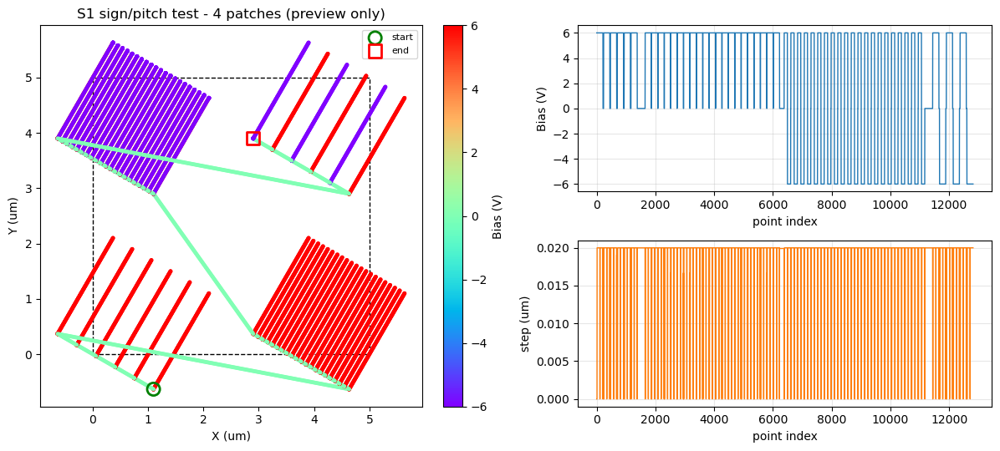

Wrote 12817 pts to 'output\traj.txt'  (path length 237.8 um, 183 strokes)


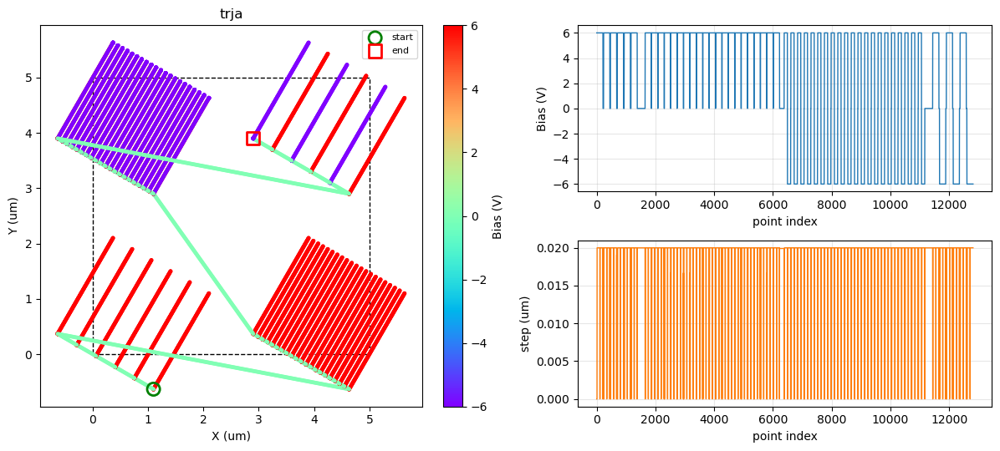

In [21]:
# ======================================================================
manifest, preview = gen_sign_pitch_test(
    center_um=(2.5, 2.5), size_um=2, gap_um=0.8,
    angle_deg=60.0, v=6.0,
    pitch_dense_um=0.10, pitch_sparse_um=0.40,
    field_um=5.0, step_um=0.02, n_pt=10)



visualize_trajectory(tb=preview, field_um=5.0,
                     title="S1 sign/pitch test - 4 patches (preview only)")

fname = os.path.join(CONFIG["work_dir"], "traj.txt")
preview.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=preview, field_um=5.0, title="trja")

In [22]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\traj.txt")


In [23]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [24]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Session 2

In [39]:
def check_bounds(tb, field_um=None):
    x, y, _ = tb.to_arrays()
    f = tb.field_um if field_um is None else field_um
    bad = (x < 0) | (x > f) | (y < 0) | (y > f)
    print(f"extent  X [{np.nanmin(x):.3f}, {np.nanmax(x):.3f}]   "
          f"Y [{np.nanmin(y):.3f}, {np.nanmax(y):.3f}]   field {f} um")
    if bad.any():
        raise ValueError(f"{bad.sum()} of {len(x)} points outside 0..{f} um - "
                         "raise center_um or shrink size_um/gap_um")
    return True

for m in manifest:
    print(m["label"]); check_bounds(TrajectoryBuilder(), field_um=7.0)  # or re-check per file

In [50]:
# angles = [0, 20, 40, 60, 80, 100, 120, 140, 160]
# grid   = [(cx, cy) for cy in (1.5, 3.5, 5.5) for cx in (1.5, 3.5, 5.5)]   # 3x3

# rng      = np.random.default_rng(1)
# slot_of  = rng.permutation(len(angles))     # angle -> grid slot
# write_of = rng.permutation(len(angles))     # temporal order, independent

# manifest = []
# for step, i in enumerate(write_of):
#     th, ctr = angles[i], grid[slot_of[i]]
#     tb, n = gen_line_patch(ctr, size_um=1.25, pitch_um=0.10, angle_deg=th,
#                            scheme="bipolar", v=6.0, field_um=7.0,
#                            step_um=0.02, n_pt=10)
#     check_bounds(tb, field_um=7)
#     fn = os.path.join(CONFIG["work_dir"], f"s2_th{th:03d}.txt"); tb.save(fn)
#     manifest.append(dict(label=f"th{th:03d}", file=fn, angle=th, center_um=ctr,
#                          n_rows=n, eta_s=eta_s(tb, 1.0), write_order=step))
# print("total write time", sum(m["eta_s"] for m in manifest), "s")

# rows = audit_trajectories(manifest, field_um=7, scan_um=6.5,
#                           expect_pitch_um=0.10, zoom_label="th040")

In [49]:
# import time, json

# def load_traj(path):
#     """Load + build one trajectory file in the TL panel."""
#     full = os.path.abspath(path)
#     igor = full.replace("\\", "\\\\")     # Igor eats one level of backslashes
#     cmd  = f'TL_LoadBuildPy("{igor}")'
#     print("    ", cmd)
#     ae.write_spm(commands=cmd)

# def run_traj(speed_ums=1.0, center=None):
#     if center is None:
#         ae.write_spm(commands=f'TL_RunPy({speed_ums}, 0, 0, 0)')   # live scan centre
#     else:
#         ae.write_spm(commands=f'TL_RunPy({speed_ums}, 1, {center[0]}, {center[1]})')

# SPEED, PAD_S = 1.0, 8.0

# ae.write_spm(commands='TL_ToggleOverlay()')          # overlay ON, once

# log = []
# for m in manifest:                                    # already in randomized write order
#     print(f"[{m['write_order']}] {m['label']}  angle={m['angle']:3d}  "
#           f"centre={m['center_um']}  eta={m['eta_s']:.0f}s")
#     load_traj(m["file"])
#     input("      overlay looks right? Enter to run, Ctrl-C to stop ")   # see note below
#     t0 = time.time()
#     run_traj(SPEED)
#     time.sleep(m["eta_s"] + PAD_S)
#     log.append(dict(label=m["label"], angle=m["angle"], center_um=m["center_um"],
#                     write_order=m["write_order"], eta_s=m["eta_s"],
#                     t_start=time.strftime("%H:%M:%S", time.localtime(t0)),
#                     t_elapsed=round(time.time()-t0, 1), speed_ums=SPEED))

# ae.write_spm(commands='TL_ToggleOverlay()')          # overlay OFF, once

# with open(os.path.join(CONFIG["work_dir"], "s2_writelog.json"), "w") as f:
#     json.dump(log, f, indent=1)
# print("wrote s2_writelog.json")

Wrote 1406 pts to 'output\s2_th020.txt'  (path length 23.0 um, 44 strokes)
Wrote 1405 pts to 'output\s2_th040.txt'  (path length 23.0 um, 44 strokes)
Wrote 1414 pts to 'output\s2_th080.txt'  (path length 23.0 um, 44 strokes)
Wrote 1412 pts to 'output\s2_th100.txt'  (path length 23.0 um, 44 strokes)
Wrote 1408 pts to 'output\s2_th060.txt'  (path length 23.0 um, 44 strokes)
Wrote 1423 pts to 'output\s2_th160.txt'  (path length 23.0 um, 44 strokes)
Wrote 1418 pts to 'output\s2_th140.txt'  (path length 23.0 um, 44 strokes)
Wrote 1406 pts to 'output\s2_th000.txt'  (path length 23.0 um, 44 strokes)
Wrote 1430 pts to 'output\s2_th120.txt'  (path length 23.0 um, 44 strokes)
Wrote 19022 pts to 'output\s2_angle9_combined.txt'  (path length 322.5 um, 468 strokes)

combined: 19022 pts   X[0.619,6.354]  Y[0.619,6.381]
  V: +6 45.5%   -6 45.5%   0 9.0%
  ETA @1 um/s: 390 s
  #0 th020  slot 0  centre (1.5, 1.5)  13 lines
  #1 th040  slot 1  centre (3.5, 1.5)  13 lines
  #2 th080  slot 2  centre (5.5,

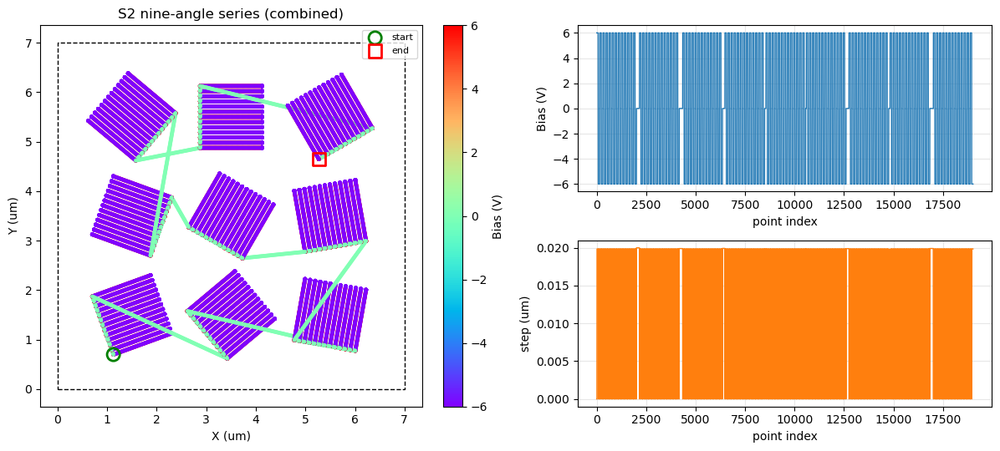

In [52]:
import json

angles = [0, 20, 40, 60, 80, 100, 120, 140, 160]
grid   = [(cx, cy) for cy in (1.5, 3.5, 5.5) for cx in (1.5, 3.5, 5.5)]   # 3x3
serp   = [0, 1, 2, 5, 4, 3, 6, 7, 8]        # serpentine slot order -> short travels

rng     = np.random.default_rng(1)
slot_of = rng.permutation(len(angles))      # angle i -> slot slot_of[i]
angle_at = np.empty(len(angles), int)       # invert it
for i, s in enumerate(slot_of):
    angle_at[s] = i

tb_all = TrajectoryBuilder(field_um=7.0, step_um=0.02, travel_v=0.0)
manifest = []
for step, s in enumerate(serp):
    i   = angle_at[s]
    th  = angles[i]
    ctr = grid[s]
    # append into the shared builder AND save a per-patch file for the analysis
    _, n = gen_line_patch(ctr, size_um=1.25, pitch_um=0.10, angle_deg=th,
                          scheme="bipolar", v=6.0, tb=tb_all,
                          field_um=7.0, step_um=0.02, n_pt=10)
    tb_one, _ = gen_line_patch(ctr, size_um=1.0, pitch_um=0.10, angle_deg=th,
                               scheme="bipolar", v=6.0,
                               field_um=7.0, step_um=0.02, n_pt=10)
    fn = os.path.join(CONFIG["work_dir"], f"s2_th{th:03d}.txt")
    tb_one.save(fn)
    manifest.append(dict(label=f"th{th:03d}", file=fn, angle=th, slot=int(s),
                         center_um=ctr, n_rows=n, write_order=step))

fname = os.path.join(CONFIG["work_dir"], "s2_angle9_combined.txt")
x, y, v = tb_all.save(fname)
x, y = x*1e6, y*1e6

print(f"\ncombined: {len(x)} pts   X[{x.min():.3f},{x.max():.3f}]  Y[{y.min():.3f},{y.max():.3f}]")
print(f"  V: +6 {100*(v>0).mean():.1f}%   -6 {100*(v<0).mean():.1f}%   0 {100*(v==0).mean():.1f}%")
print(f"  ETA @1 um/s: {len(x)*0.02/1.0 + 10:.0f} s")
assert x.min() >= 0 and y.min() >= 0 and x.max() <= 7.0 and y.max() <= 7.0, "OUT OF BOUNDS"
for m in manifest:
    print(f"  #{m['write_order']} {m['label']}  slot {m['slot']}  centre {m['center_um']}  {m['n_rows']} lines")

with open(os.path.join(CONFIG["work_dir"], "s2_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=1)

visualize_trajectory(tb=tb_all, field_um=7.0, title="S2 nine-angle series (combined)")

In [65]:
# Load patterns into the software

fname = os.path.join(CONFIG["work_dir"], "s3_1_write_AB.txt")
full_path = os.path.abspath(fname)
igor_path = full_path.replace("\\", "\\\\")
cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)
ae.write_spm(commands=cmd)
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\s3_1_write_AB.txt")


In [54]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')

In [55]:
ae.write_spm(commands='TL_ToggleOverlay()')

## Session 3

In [85]:
def gen_isotropic_reset(center_um, r_max=0.90, dr_um=0.05, v=8.0,
                        field_um=7.0, step_um=0.02, n_pt=10, tb=None):
    """Concentric circles, bias sign AND traversal direction flipped per circle.

    Isotropic in the path tangent (all directions sampled equally), so it cannot
    imprint a write angle - which is the whole point. Back-scan-free: each circle
    is traversed once, so there is no retrace and no grounded return pass.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um, travel_v=0.0)
    cx, cy = center_um
    radii = np.arange(dr_um, r_max + 1e-9, dr_um)
    for k, r in enumerate(radii):
        npts = max(16, int(np.ceil(2*np.pi*r/step_um)) + 1)
        s = 1 if k % 2 == 0 else -1                 # alternate direction
        vk = (+abs(v) if k % 2 == 0 else -abs(v))   # alternate sign
        a = np.linspace(0, s*2*np.pi, npts)
        pts = np.column_stack([cx + r*np.cos(a), cy + r*np.sin(a)])
        tb.dwell((pts[0,0], pts[0,1]), vk, n_pt)
        tb.stroke(pts, np.full(npts, float(vk)))
    return tb, len(radii)

# --- build the three files ---
WRITE = dict(size_um=2, pitch_um=0.10, angle_deg=60.0, scheme="bipolar",
             v=6.0, field_um=5.0, step_um=0.02, n_pt=10)     # the P3 recipe

tbW, _ = gen_line_patch((1.5, 1.5), **WRITE)                # step 1: write A
gen_line_patch((3.6, 3.6), tb=tbW, **WRITE)                 #         write B
fW = os.path.join(CONFIG["work_dir"], "s3_1_write_AB.txt"); tbW.save(fW)

tbR, ncirc = gen_isotropic_reset((1.5, 1.5), r_max=1.75, dr_um=0.05, v=8.0)
fR = os.path.join(CONFIG["work_dir"], "s3_2_reset_A.txt");  tbR.save(fR)

tbW2, _ = gen_line_patch((1.5, 1.5), **WRITE)               # step 3: rewrite A
fW2 = os.path.join(CONFIG["work_dir"], "s3_3_rewrite_A.txt"); tbW2.save(fW2)

for f in (fW, fR, fW2):
    tb = TrajectoryBuilder(); d = np.loadtxt(f)
    x, y, v = d[:,0]*1e6, d[:,1]*1e6, d[:,2]
    print(f"{os.path.basename(f):22s} {len(x):6d} pts  X[{x.min():.2f},{x.max():.2f}] "
          f"Y[{y.min():.2f},{y.max():.2f}]  +{100*(v>0).mean():.0f}% -{100*(v<0).mean():.0f}% "
          f"0:{100*(v==0).mean():.0f}%  ETA {len(x)*0.02:.0f}s")
print(f"reset: {ncirc} circles to r=0.90 um, 50 nm spacing")

Wrote 9820 pts to 'output\s3_1_write_AB.txt'  (path length 176.0 um, 168 strokes)
Wrote 10434 pts to 'output\s3_2_reset_A.txt'  (path length 199.6 um, 70 strokes)
Wrote 4790 pts to 'output\s3_3_rewrite_A.txt'  (path length 86.0 um, 84 strokes)
s3_1_write_AB.txt        9820 pts  X[0.13,4.97] Y[0.13,4.97]  +48% -48% 0:5%  ETA 196s
s3_2_reset_A.txt        10434 pts  X[-0.25,3.25] Y[-0.25,3.25]  +51% -48% 0:1%  ETA 209s
s3_3_rewrite_A.txt       4790 pts  X[0.13,2.87] Y[0.13,2.87]  +49% -49% 0:3%  ETA 96s
reset: 35 circles to r=0.90 um, 50 nm spacing


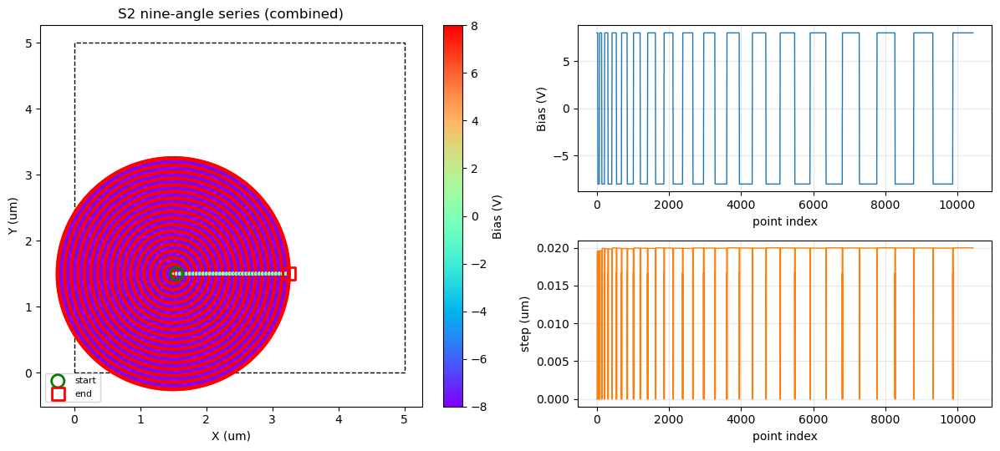

In [87]:
# with open(os.path.join(CONFIG["work_dir"], "s2_manifest.json"), "w") as f:
#     json.dump(manifest, f, indent=1)

visualize_trajectory(tb=tbR, field_um=5.0, title="S2 nine-angle series (combined)")

In [92]:
# Load patterns into the software

fname = os.path.join(CONFIG["work_dir"], "s3_3_rewrite_A.txt")
full_path = os.path.abspath(fname)
igor_path = full_path.replace("\\", "\\\\")
cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)
ae.write_spm(commands=cmd)
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\s3_3_rewrite_A.txt")


In [93]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')

In [94]:
ae.write_spm(commands='TL_ToggleOverlay()')

## 260806-session 1

In [15]:
# ---------------------------------------------------------------------
# Prerequisites (idempotent - safe to re-run)
# ---------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Stationary bias-settle points. Bypasses resample_constant_step, which
    collapses a zero-length polyline to a single point."""
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self
TrajectoryBuilder.dwell = _dwell


def _to_arrays(self):
    """As original, but no travel point is injected when there is no gap to
    travel - that stray 0 V sample was chopping the bias between passes."""
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))
TrajectoryBuilder.to_arrays = _to_arrays


# ---------------------------------------------------------------------
def gen_alternating_square(size_um=3.0, pitch_um=0.10, angle_deg=30.0,
                           center_um=(2.5, 2.5), v=6.0, field_um=5.0,
                           step_um=0.02, n_pt=10, start_sign=+1,
                           alt_period=1, n_cycles=1, flip_each_cycle=False,
                           tb=None, travel_v=0.0, verbose=True):
    """Square raster at an arbitrary angle whose per-line bias phase alternates.

    Line 1:  forward +V, backward -V
    Line 2:  forward -V, backward +V
    Line 3:  forward +V, backward -V   ...

    Every point still sees both polarities, so both C3v orbits stay reachable,
    but the polarity that lands LAST alternates row to row, so the region never
    closes into a single orbit. That is the difference from the S1 P3 recipe,
    which ended every line at -V and came out as a uniform out-of-plane block
    (switched fraction 0.009) with the in-plane state frozen.

    size_um     side of the square, in the rotated frame
    pitch_um    line spacing
    angle_deg   line direction, CCW from +x
    v           magnitude; sign is assigned per pass
    alt_period  consecutive lines sharing one phase before flipping.
                1 = flip every line (as specified). 2 or 3 coarsens the
                out-of-plane modulation while keeping the area unpoled.
    n_cycles    repeats of the whole pattern
    flip_each_cycle  invert the phase pattern on alternate cycles
    n_pt        stationary settle points inserted at every voltage change

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    half = size_um / 2.0
    vmag = abs(float(v))
    alt = max(1, int(alt_period))

    n_rows = max(1, int(round(size_um / pitch_um)) + 1)
    lys = np.linspace(-half, half, n_rows) if n_rows > 1 else np.array([0.0])
    ends = np.array([-half, half])

    def to_world(lx, ly):
        return cx + lx * c - ly * s, cy + lx * s + ly * c

    first_pass = []
    for cyc in range(max(1, int(n_cycles))):
        flip = -1 if (flip_each_cycle and cyc % 2) else 1
        for k, ly in enumerate(lys):
            sgn = start_sign * flip * (1 if (k // alt) % 2 == 0 else -1)
            v_f, v_b = sgn * vmag, -sgn * vmag
            row = np.full(2, ly, float)

            fx, fy = to_world(ends, row)
            tb.dwell((fx[0], fy[0]), v_f, n_pt)                  # settle to v_f
            tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

            tb.dwell((fx[-1], fy[-1]), v_b, n_pt)                # settle to v_b
            bx, by = to_world(ends[::-1], row)
            tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

            if cyc == 0:
                first_pass.append(int(np.sign(v_f)))

    if verbose:
        x, y, vv = tb.to_arrays()
        x, y = x * 1e6, y * 1e6
        bbox = size_um * (abs(c) + abs(s))
        d = np.hypot(np.diff(x), np.diff(y))
        pos = float(np.sum(d[(vv[1:] > 0)])); neg = float(np.sum(d[(vv[1:] < 0)]))
        print(f"alternating square: {angle_deg:.0f} deg, {size_um} um, pitch "
              f"{pitch_um*1000:.0f} nm, {n_rows} lines x {n_cycles} cycle(s)")
        print(f"  first-pass polarity by line: "
              f"{''.join('+' if p > 0 else '-' for p in first_pass)}")
        print(f"  last-pass  polarity by line: "
              f"{''.join('-' if p > 0 else '+' for p in first_pass)}   <- alternates")
        print(f"  biased path: {pos:.1f} um at +V, {neg:.1f} um at -V  "
              f"(imbalance {200*abs(pos-neg)/(pos+neg+1e-9):.2f} %)")
        print(f"  {len(x)} pts, {100*(vv == 0).mean():.1f} % at 0 V (inter-row travel)")
        print(f"  rotated bbox {bbox:.3f} um   extent X[{x.min():.3f}, {x.max():.3f}] "
              f"Y[{y.min():.3f}, {y.max():.3f}]  field {field_um} um")
#         for sp in (0.25, 0.5, 1.0, 2.0):
#             print(f"    ETA @{sp:>4} um/s: {len(x)*step_um/sp:6.0f} s")
#         if x.min() < 0 or y.min() < 0 or x.max() > field_um or y.max() > field_um:
#             raise ValueError("OUT OF BOUNDS - shrink size_um or move center_um")
    return tb

alternating square: 60 deg, 1.5 um, pitch 20 nm, 76 lines x 1 cycle(s)
  first-pass polarity by line: +-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
  last-pass  polarity by line: -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+   <- alternates
  biased path: 114000000.0 um at +V, 114000000.0 um at -V  (imbalance 0.00 %)
  13297 pts, 1.4 % at 0 V (inter-row travel)
  rotated bbox 2.049 um   extent X[-24519.053, 2024519.053] Y[-24519.053, 2024519.053]  field 2.0 um
Wrote 13297 pts to 'output\260807_session_3_2.txt'  (path length 229.5 um, 304 strokes)


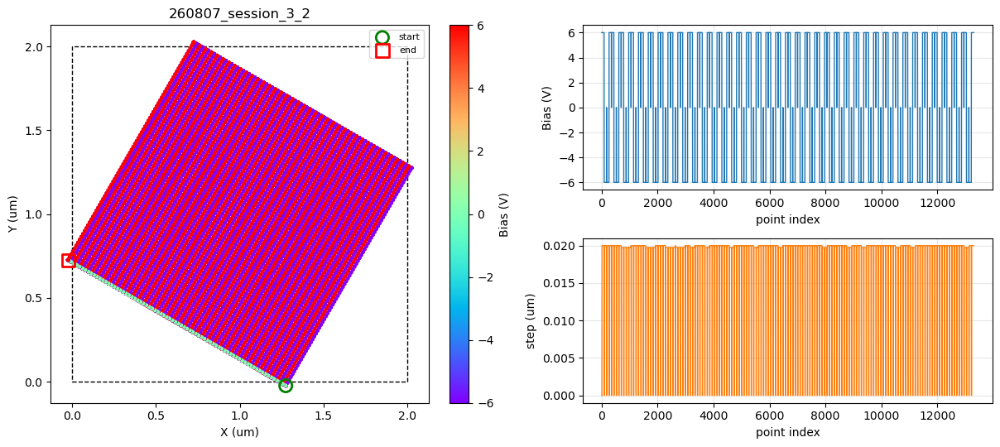

In [56]:
preview = gen_alternating_square(size_um=1.5, pitch_um=0.020, angle_deg=60.0,
                                 center_um=(1, 1), v=6.0, field_um=2.0, flip_each_cycle=True,
                                 step_um=0.02, n_pt=10, alt_period=1, n_cycles=1)

fname = os.path.join(CONFIG["work_dir"], "260807_session_3_2.txt")
preview.save(fname)

visualize_trajectory(tb=preview, field_um=2.0, title="260807_session_3_2")

In [57]:
# Load patterns into the software

fname = os.path.join(CONFIG["work_dir"], "260807_session_3_2.txt")
full_path = os.path.abspath(fname)
igor_path = full_path.replace("\\", "\\\\")
cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)
ae.write_spm(commands=cmd)
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\260807_session_3_2.txt")


In [58]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')

In [59]:
ae.write_spm(commands='TL_ToggleOverlay()')

## Unidirection trajectory

In [65]:
# ---------------------------------------------------------------------
# Prerequisites (idempotent - safe to re-run)
# ---------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Stationary bias-settle points; bypasses resample_constant_step, which
    collapses a zero-length polyline to one point."""
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self
TrajectoryBuilder.dwell = _dwell


def _to_arrays(self):
    """No travel point injected when there is no gap to travel."""
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))
TrajectoryBuilder.to_arrays = _to_arrays


# ---------------------------------------------------------------------
def gen_center_out_raster(W_um=3.0, H_um=3.0, pitch_um=0.35, angle_deg=90.0,
                          center_um=(2.5, 2.5), v=6.0, h_inner_um=0.0,
                          flip_each_cycle=True, within_cycle='same',
                          field_um=5.0, step_um=0.02, n_pt=10,
                          tb=None, travel_v=0.0, verbose=True):
    """W x H raster at an arbitrary angle that grows outward from the centre.

    One CYCLE = one full traverse along +W at separation +y_k from the centre
    line, then one full traverse along -W at -y_k. The separation y_k grows by
    pitch_um each cycle until the pair reaches +-H/2, so the written region
    expands symmetrically from the centre outward.

        cycle 0:  +W at +0.5*pitch      -W at -0.5*pitch
        cycle 1:  +W at +1.5*pitch      -W at -1.5*pitch
        ...

    Line spacing is uniform at pitch_um across the whole rectangle.

    W_um, H_um      rectangle dimensions in the rotated frame (W along the
                    stroke direction, H across it)
    pitch_um        increment of the separation per cycle = the line spacing
    angle_deg       stroke direction, CCW from +x
    h_inner_um      start the growth at this separation instead of 0, i.e.
                    write only the annulus from h_inner_um to H_um. Use this
                    to add a ring without re-dosing the centre
    v               magnitude; sign assigned per cycle / per pass
    flip_each_cycle invert the bias between neighbouring full cycles
    within_cycle    'same'    both passes of a cycle share one sign
                    'bipolar' forward +, backward - within each cycle
    n_pt            stationary settle points at each voltage change

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    vmag = abs(float(v))
    hw = W_um / 2.0

    n_cyc = max(1, int(round((H_um - h_inner_um) / (2.0 * pitch_um))))
    ys = h_inner_um / 2.0 + (np.arange(n_cyc) + 0.5) * pitch_um

    def to_world(u, w):
        return cx + u * c - w * s, cy + u * s + w * c

    pol = []
    for k, y in enumerate(ys):
        sgn = (1 if k % 2 == 0 else -1) if flip_each_cycle else 1
        if within_cycle == 'bipolar':
            v_f, v_b = sgn * vmag, -sgn * vmag
        elif within_cycle == 'same':
            v_f = v_b = sgn * vmag
        else:
            raise ValueError("within_cycle must be 'same' or 'bipolar'")
        pol.append((v_f, v_b))

        # forward: -W/2 -> +W/2 at +y
        fx, fy = to_world(np.array([-hw, hw]), np.array([y, y]))
        tb.dwell((fx[0], fy[0]), v_f, n_pt)
        tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

        # backward: +W/2 -> -W/2 at -y
        bx, by = to_world(np.array([hw, -hw]), np.array([-y, -y]))
        if v_b != v_f:
            tb.dwell((bx[0], by[0]), v_b, n_pt)
        tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

    if verbose:
        x, y, vv = tb.to_arrays(); x, y = x * 1e6, y * 1e6
        d = np.hypot(np.diff(x), np.diff(y))
        pos = float(np.sum(d[vv[1:] > 0])); neg = float(np.sum(d[vv[1:] < 0]))
        ex = (W_um * abs(c) + H_um * abs(s)) / 2.0
        ey = (W_um * abs(s) + H_um * abs(c)) / 2.0
        print(f"centre-out raster: {W_um} x {H_um} um at {angle_deg:.0f} deg, "
              f"pitch {pitch_um*1000:.0f} nm")
        print(f"  {n_cyc} cycles = {2*n_cyc} lines; separation "
              f"{2*ys[0]*1000:.0f} -> {2*ys[-1]*1000:.0f} nm"
              + (f" (inner {h_inner_um} um skipped)" if h_inner_um else ""))
        print(f"  cycle polarity (fwd/bwd): "
              + " ".join(f"{'+' if a>0 else '-'}{'+' if b>0 else '-'}"
                         for a, b in pol[:12]) + (" ..." if n_cyc > 12 else ""))
        print(f"  biased path {pos:.1f} um at +V, {neg:.1f} um at -V  "
              f"(net DC imbalance {200*abs(pos-neg)/(pos+neg+1e-9):.2f} %)")
        print(f"  {len(x)} pts, {100*(vv == 0).mean():.1f} % at 0 V (edge travel)")
        print(f"  rotated half-extent {ex:.3f} x {ey:.3f} um   "
              f"X[{x.min():.3f}, {x.max():.3f}]  Y[{y.min():.3f}, {y.max():.3f}]")
        for sp in (0.25, 0.5, 1.0, 2.0):
            print(f"    ETA @{sp:>4} um/s: {len(x)*step_um/sp:6.0f} s")
#         if x.min() < 0 or y.min() < 0 or x.max() > field_um or y.max() > field_um:
#             raise ValueError("OUT OF BOUNDS - shrink W/H or move center_um")
    return tb

centre-out raster: 4.0 x 4 um at 90 deg, pitch 20 nm
  100 cycles = 200 lines; separation 20 -> 3980 nm
  cycle polarity (fwd/bwd): ++ -- ++ -- ++ -- ++ -- ++ -- ++ -- ...
  biased path 400000000.0 um at +V, 400000000.0 um at -V  (net DC imbalance 0.00 %)
  61358 pts, 32.9 % at 0 V (edge travel)
  rotated half-extent 2.000 x 2.000 um   X[510000.000, 4490000.000]  Y[500000.000, 4500000.000]
    ETA @0.25 um/s:   4909 s
    ETA @ 0.5 um/s:   2454 s
    ETA @ 1.0 um/s:   1227 s
    ETA @ 2.0 um/s:    614 s
Wrote 61358 pts to 'output\260809_session_5_2.txt'  (path length 1198.0 um, 300 strokes)


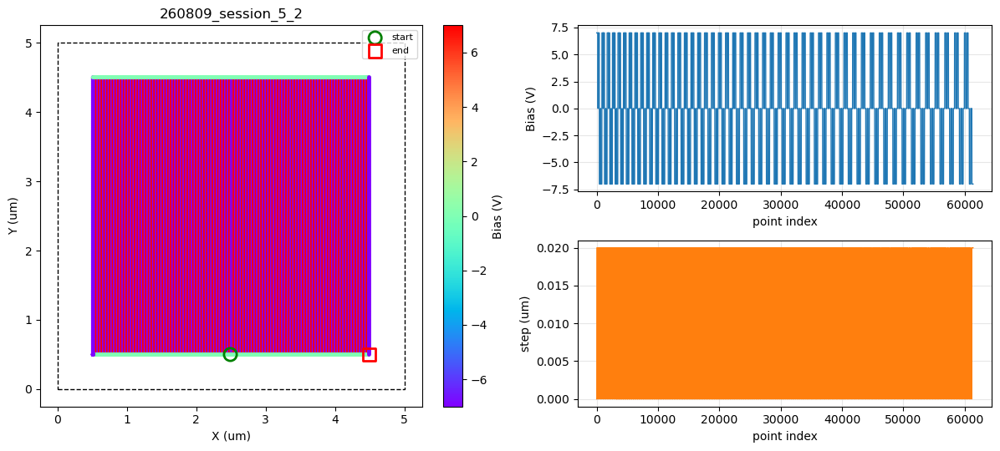

In [91]:
preview = gen_center_out_raster(W_um=4.0, H_um=4, pitch_um=0.02, angle_deg=90.0,
                                center_um=(2.5, 2.5), v=7.0,
                                flip_each_cycle=True, within_cycle='same',
                                field_um=5.0, step_um=0.02, n_pt=10)

fname = os.path.join(CONFIG["work_dir"], "260809_session_5_2.txt")
preview.save(fname)

visualize_trajectory(tb=preview, field_um=5.0, title="260809_session_5_2")

In [92]:
# Load patterns into the software

fname = os.path.join(CONFIG["work_dir"], "260809_session_5_2.txt")
full_path = os.path.abspath(fname)
igor_path = full_path.replace("\\", "\\\\")
cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)
ae.write_spm(commands=cmd)
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\260809_session_5_2.txt")


In [93]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')

In [94]:
ae.write_spm(commands='TL_ToggleOverlay()')

In [7]:
import numpy as np


def gen_diameter_scan(n_lines=6, radius_um=0.8, center_um=(1.0, 1.0), v=-5.5,
                      start_angle_deg=0.0, signed_pass_bias=True,
                      field_um=2.0, step_um=0.01, tb=None, pts_per_line=400,
                      n_rot=1, offset_rot=0.0, v_forward = None, v_retract=None):
    """Diameter-scan poling pattern with angular-sector sign reversal.

    Each line is a full DIAMETER: from one edge, through the center, to the opposite
    edge. The line is written twice -- forward (edge A -> edge B) and back
    (edge B -> edge A) -- then the angle advances to the next diameter.
    Because a diameter at theta and theta+180 deg are the same line, the angles span
    only [0, 180) deg: n_lines diameters at 0, 180/n, 2*180/n, ...

    The new n_rot / offset_rot args divide the 180-degree orientation range into
    n_rot equal angular SECTORS and flip the per-pass voltage sign in alternating
    sectors.  With the default (forward = -|v|, return = +|v|) convention read as
    "- for inward / + for outward", a flipped sector instead uses "+ for inward /
    - for outward" (forward = +|v|, return = -|v|).

    n_lines           : number of distinct diameter orientations (over 180 deg)
    radius_um         : half-length of each diameter (diameter length = 2*radius_um)
    center_um         : (cx, cy) center of the pattern
    v                 : pulse magnitude; sign is set per-pass (see signed_pass_bias).
                        Its absolute value is what matters; the (unflipped) forward
                        pass uses -|v|, the return pass +|v|.
    start_angle_deg   : rotates the whole pattern (align to easy axes)
    signed_pass_bias  : True  -> forward/return passes get opposite signs
                        False -> both passes at v (no per-pass sign flip; n_rot then
                                 has no visible effect since there is no sign to flip)
    pts_per_line      : samples along one diameter traversal (one direction)
    n_rot             : number of equal sectors dividing the 180-deg range.  The sign
                        convention alternates sector-to-sector (sector 0 unflipped,
                        sector 1 flipped, sector 2 unflipped, ...).  e.g. n_rot=3 ->
                        three 60-deg sectors, sign reversed in the middle one (and
                        every other one).  n_rot=1 reproduces the original behavior.
    offset_rot        : offset angle (deg) for the sector division.  Shifts where the
                        sector boundaries fall within the 180-deg range; does NOT
                        rotate the diameters themselves (use start_angle_deg for that).
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R = radius_um
    vmag = abs(v)

    n_rot = max(1, int(n_rot))
    sector_width = np.pi / n_rot                       # sector size within the 180-deg span
    offset_rad = np.deg2rad(offset_rot)

    # diameter orientations over 180 deg only (theta and theta+180 are the same line)
    base = np.linspace(0, np.pi, n_lines, endpoint=False)   # 0..180 deg, relative to start
    angles = np.deg2rad(start_angle_deg) + base

    for phi, theta_rel in zip(angles, base):
        ux, uy = np.cos(phi), np.sin(phi)              # unit vector along this diameter

        # which sector does this orientation fall in? (measured in the 180-deg space,
        # shifted by offset_rot, wrapped into [0, 180) so it stays within n_rot sectors)
        ang_in_span = np.mod(theta_rel - offset_rad, np.pi)
        sector = int(ang_in_span // sector_width)
        flip = (sector % 2 == 1)                       # alternate sectors flip the sign

        # parametrize from -R (edge A) to +R (edge B)
        t = np.linspace(-R, R, pts_per_line, endpoint=True)
        xf = cx + t * ux
        yf = cy + t * uy

        if signed_pass_bias:
            # default: forward -|v|, return +|v|;  flipped sector swaps them
            v_fwd = (+vmag if flip else -vmag)
            v_ret = (-vmag if flip else +vmag)
        else:
            v_fwd = v
            v_ret = v
            
        if v_forward is not None:
            v_fwd = v_forward
        
        if v_retract is not None:
            v_ret = v_retract

        # forward pass: edge A -> edge B
        tb.stroke(np.column_stack([xf, yf]), np.full(pts_per_line, v_fwd, float))
        # return pass: edge B -> edge A  (reverse the same points)
        tb.stroke(np.column_stack([xf[::-1], yf[::-1]]), np.full(pts_per_line, v_ret, float))

    return tb

## Create the pattern

Wrote 37117 pts to 'output\rose_flower_N64_4um.txt'  (path length 1457.0 um, 256 strokes)


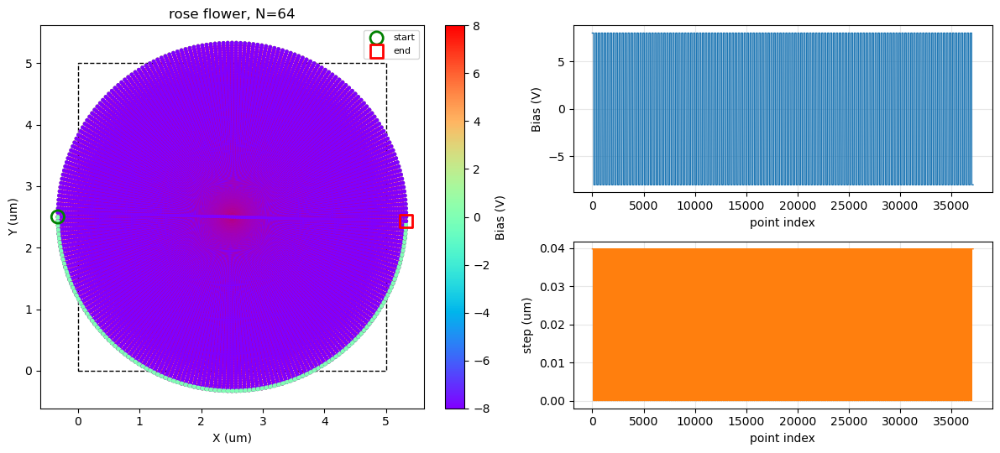

In [23]:
# example: 6-leaf flower in your 2 um frame

tb = gen_diameter_scan(n_lines=128, radius_um=2*np.sqrt(2), center_um=(2.5, 2.5), v=8,
                       n_rot=0, offset_rot=0.0, field_um=4, step_um=0.04, pts_per_line=100,v_forward=8, v_retract=-8 )
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=5.0, title="rose flower, N=64")

In [24]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [25]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')      # live scan center, 0.5 um/s

In [26]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## VDART and LDART scan after litho

In [54]:
ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')

ae.tune_probe(num=3, center=380e3, width=100e3)

In [55]:
exp.execute('ChangeName', "PZTO_VDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

img_v = exp.load_ibw(folder=exp.folder)

In [60]:
cmd = 'XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n\
XPTButtonFunc("WriteXPT")\n\
XPTBoxFunc("DontChangeXPTCheck", 1)'

ae.write_spm(cmd)

time.sleep(2)

In [61]:
ae.tune_probe(num=2, center=850e3, width=100e3)

In [62]:
exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

# exp.check_files()

# img_l = exp.load_ibw(folder=exp.folder)

In [85]:
# Set up AC + DC writing
exp.execute('DARTWidth', 0, wait=1)
exp.execute('DARTFreq', 55, wait=1)
exp.execute('DARTIgain', 0, wait=1)


Invalid action: not found in default list or custom list.


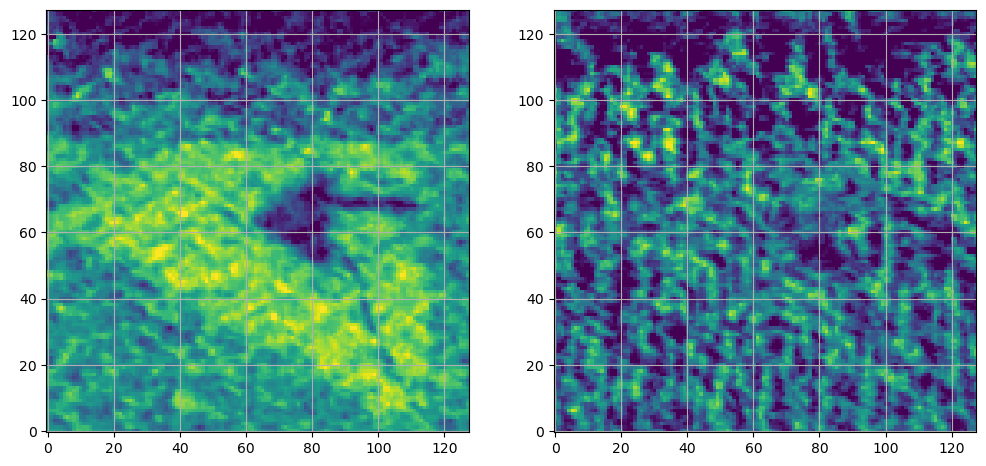

In [76]:
img_l = exp.load_ibw(folder=exp.folder)

fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * np.cos(img_v.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

ax[0].imshow(tp1, clim=[c-2/1*s, c+2/1*s], origin='lower', )
im = ax[1].imshow(img_l.data[2] * np.cos(img_l.data[4] / 180 * np.pi), clim=[c-1/1*s, c+3.5/1*s], origin='lower', )

# plt.colorbar(im, ax=ax[1])
ax[0].grid()
ax[1].grid()

## Pattern with sign jump

In [23]:
import numpy as np


def gen_diameter_scan_backward_flip(n_lines=6, radius_um=0.8, center_um=(1.0, 1.0),
                                    v=5.5, start_angle_deg=0.0,
                                    field_um=2.0, step_um=0.01, tb=None,
                                    pts_per_line=400, flip_sign=False):
    """Diameter-scan poling pattern where ONLY the backward pass applies voltage,
    and the backward voltage flips sign at the pattern center.

    For each diameter orientation:
      * FORWARD pass  (edge A -> center -> edge B): travels at ZERO volts (no poling).
      * BACKWARD pass (edge B -> center -> edge A): applies voltage, with the sign
        REVERSED as the tip crosses the center. So one half-radius of the backward
        line is poled at +|v| and the other half at -|v|.

    Because a diameter at theta and theta+180 deg are the same line, the angles span
    only [0, 180) deg: n_lines diameters at 0, 180/n, 2*180/n, ...

    n_lines         : number of distinct diameter orientations (over 180 deg)
    radius_um       : half-length of each diameter (full diameter = 2*radius_um)
    center_um       : (cx, cy) center of the pattern
    v               : pulse magnitude; only |v| matters (sign is set per half-line).
    start_angle_deg : rotates the whole pattern (align to easy axes)
    pts_per_line    : samples along one diameter traversal (one direction)
    flip_sign       : sets which half gets which sign on the backward pass.
                      False -> backward first half (edge B -> center) = +|v|,
                               backward second half (center -> edge A) = -|v|
                      True  -> the opposite assignment.

    Notes on the center point: the parametrization uses pts_per_line samples from
    +R (edge B) to -R (edge A) on the backward pass. Each sample's voltage is chosen
    by the SIGN OF ITS POSITION along the diameter (t > 0 vs t < 0), so the flip
    happens exactly at the geometric center. The point closest to t = 0 is assigned
    +|v| (or per flip_sign); an exact t == 0 sample is treated as the post-center side.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R = radius_um
    vmag = abs(v)

    # diameter orientations over 180 deg only (theta and theta+180 are the same line)
    angles = np.deg2rad(start_angle_deg) + np.linspace(0, np.pi, n_lines, endpoint=False)

    for phi in angles:
        ux, uy = np.cos(phi), np.sin(phi)              # unit vector along this diameter

        # parametrize from -R (edge A) to +R (edge B)
        t = np.linspace(-R, R, pts_per_line, endpoint=True)
        xf = cx + t * ux
        yf = cy + t * uy

        # ---- FORWARD pass: edge A -> edge B at ZERO volts ----
        tb.stroke(np.column_stack([xf, yf]), np.zeros(pts_per_line, float))

        # ---- BACKWARD pass: edge B -> edge A, voltage flips sign at center ----
        # reverse the points so we travel edge B (t=+R) -> center (t=0) -> edge A (t=-R)
        xb = xf[::-1]
        yb = yf[::-1]
        tb_param = t[::-1]                             # parameter value at each backward sample

        # sign chosen by side of center: the edge-B half (t > 0) vs edge-A half (t < 0).
        # default: edge-B half = +|v|, edge-A half = -|v|.  flip_sign swaps them.
        # treat exactly-center samples (t == 0) as the post-center (edge-A) side.
        side = np.where(tb_param > 0.0, +1.0, -1.0)    # +1 on edge-B half, -1 on edge-A half
        if flip_sign:
            side = -side
        v_back = side * vmag

        tb.stroke(np.column_stack([xb, yb]), v_back.astype(float))

    return tb

Wrote 18683 pts to 'output\rose_flower_N64_4um.txt'  (path length 366.4 um, 128 strokes)


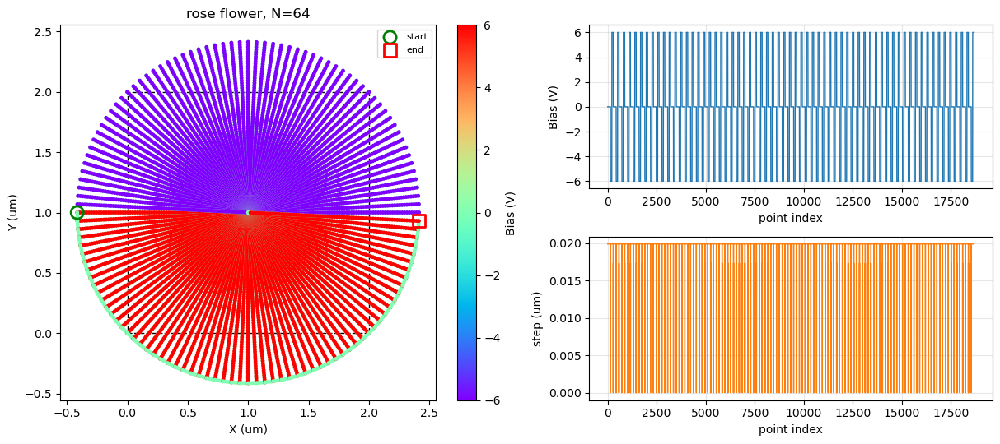

In [26]:
# example: 6-leaf flower in your 2 um frame

tb = gen_diameter_scan_backward_flip(n_lines=64, radius_um=1*np.sqrt(2), center_um=(1, 1), v=6,
                       field_um=2, step_um=0.02, pts_per_line=100, flip_sign=True )
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="rose flower, N=64")

In [27]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [28]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [29]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Concentric circles

In [18]:
import numpy as np


def gen_concentric_circles(n_circles=6, radius_um=0.8, center_um=(1.0, 1.0),
                           v=5.5, field_um=2.0, step_um=0.01, tb=None,
                           pts_per_um=None, min_radius_um=None,
                           start_sign=+1, start_ccw=True,
                           couple_sign_chirality=True, min_pts_per_circle=8):
    """Concentric-circle poling pattern where BOTH the applied voltage sign and the
    direction of travel (chirality) flip between consecutive circles.

    Point density is set by ARC LENGTH (uniform spacing along every circle), not by a
    fixed count per circle -- so inner and outer circles have the same spacing.

    n circles are written at evenly spaced radii (min_radius -> radius_um). For each
    circle k (inner -> outer):
      * voltage sign alternates: start_sign, -start_sign, ...  (magnitude |v|),
      * chirality alternates: CCW, CW, CCW, ...  (direction of travel reverses).
    Each circle is one closed-loop stroke.

    n_circles            : number of concentric circles.
    radius_um            : OUTER circle radius (um).
    center_um            : (cx, cy) center of the pattern.
    v                    : pulse magnitude; only |v| matters (sign set per circle).
    field_um, step_um    : passed to TrajectoryBuilder if tb is not supplied. step_um
                           is ALSO the default along-path spacing (see pts_per_um).
    tb                   : an existing TrajectoryBuilder to append to (else a new one).
    pts_per_um           : along-path point DENSITY in points per micrometre. If None,
                           it is taken as 1/step_um (i.e. one point every step_um),
                           matching the TrajectoryBuilder's step. The number of points
                           on a circle of radius r is round(2*pi*r * pts_per_um), so
                           every circle gets the SAME arc-length spacing.
    min_radius_um        : INNER circle radius (um). Default = radius_um / n_circles.
    start_sign           : +1 or -1, voltage sign of the FIRST (innermost) circle.
    start_ccw            : True -> innermost circle is CCW; chirality alternates after.
    couple_sign_chirality: if True (default) chirality tracks sign (CCW for +, CW for -)
                           so sign and chirality flip together; if False chirality
                           alternates independently from start_ccw.
    min_pts_per_circle   : floor on samples per circle (keeps tiny inner circles sane).

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R_out = radius_um

    n_circles = max(1, int(n_circles))
    if min_radius_um is None:
        R_in = R_out / n_circles
    else:
        R_in = min_radius_um

    if n_circles == 1:
        radii = np.array([R_out])
    else:
        radii = np.linspace(R_in, R_out, n_circles, endpoint=True)

    # along-path density: default one point per step_um
    if pts_per_um is None:
        if step_um is None or step_um <= 0:
            raise ValueError("Provide pts_per_um, or a positive step_um.")
        pts_per_um = 1.0 / step_um

    start_sign = +1 if start_sign >= 0 else -1
    vmag = abs(v)

    for k, rk in enumerate(radii):
        # number of points from arc length * density (uniform spacing across circles)
        circumference = 2.0 * np.pi * rk
        npts = int(max(min_pts_per_circle, round(circumference * pts_per_um)))

        # voltage sign for this circle
        sign = start_sign * (1.0 if (k % 2 == 0) else -1.0)

        # chirality
        if couple_sign_chirality:
            ccw = (sign > 0)                                  # CCW for +, CW for -
        else:
            ccw = (start_ccw if (k % 2 == 0) else (not start_ccw))

        theta = np.linspace(0.0, 2.0 * np.pi, npts, endpoint=True)
        if not ccw:
            theta = theta[::-1]

        x = cx + rk * np.cos(theta)
        y = cy + rk * np.sin(theta)
        vc = np.full(npts, sign * vmag, float)

        tb.stroke(np.column_stack([x, y]), vc)

    return tb

Wrote 19538 pts to 'output\rose_flower_N64_4um.txt'  (path length 290.1 um, 64 strokes)


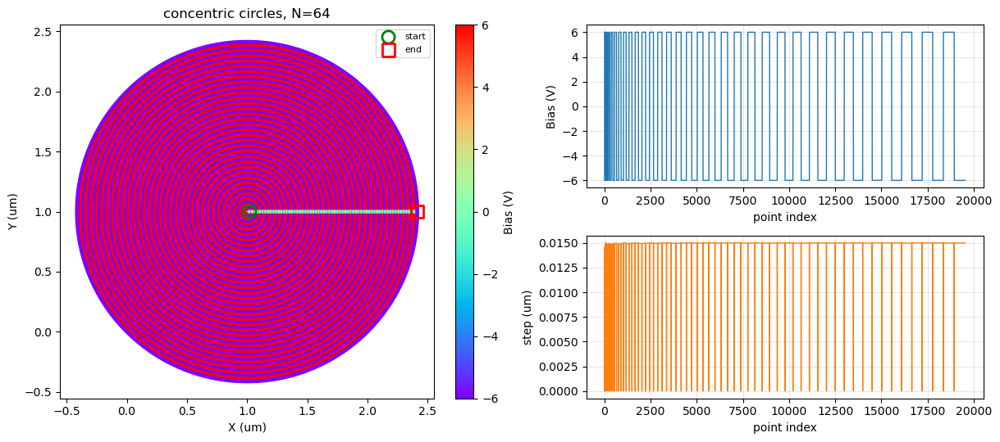

In [33]:
# example: 6-leaf flower in your 2 um frame

tb = gen_concentric_circles(n_circles=64, v=-6.0, radius_um=1*np.sqrt(2), step_um=0.015)   # 10 nm spacing via step_um
# tb = gen_concentric_circles(n_circles=6, radius_um=0.8, pts_per_um=50)  # explicit 20 nm spacing

fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")

tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="concentric circles, N=64")

In [34]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [35]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [36]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Concentric polygons

In [18]:
import numpy as np


def gen_concentric_polygons(n_sides=6, n_polygons=6, radius_um=0.8,
                            center_um=(1.0, 1.0), v=5.5, field_um=2.0,
                            step_um=0.01, tb=None, pts_per_um=None,
                            min_radius_um=None, start_angle_deg=0.0,
                            ccw=True, min_pts_per_edge=2):
    """Concentric regular n-gons (polygons) -- a CONTROL pattern for debugging.

    Deliberately SIMPLE: every polygon uses the SAME voltage sign and the SAME
    travel direction (no sign flip, no chirality reversal between rings).  Use this
    to test whether a problem is caused by the back-scan / sign-flip logic in the
    other patterns: if these clean same-direction, same-sign rings write fine but the
    alternating patterns don't, the trouble is in the reversal, not the geometry.

    n_polygons regular n_sides-gons are drawn at evenly spaced circumradii
    (min_radius -> radius_um). Each polygon is one closed-loop stroke at constant v.

    n_sides         : number of sides of each polygon (3=triangle, 4=square, ...).
    n_polygons      : number of concentric rings.
    radius_um       : OUTER polygon circumradius (um).
    center_um       : (cx, cy) center of the pattern.
    v               : voltage applied on every polygon (constant, same sign for all).
    field_um, step_um: passed to TrajectoryBuilder if tb is None. step_um is also the
                      default along-edge spacing (see pts_per_um).
    tb              : existing TrajectoryBuilder to append to (else a new one).
    pts_per_um      : along-path point density (points/um). Default 1/step_um, so all
                      edges/rings get the SAME spacing regardless of size.
    min_radius_um   : INNER polygon circumradius (um). Default = radius_um / n_polygons.
    start_angle_deg : rotates every polygon's vertices by this angle (same for all, so
                      the rings stay aligned -- no relative twist).
    ccw             : travel direction, SAME for all polygons (True=CCW, False=CW).
    min_pts_per_edge: floor on samples per edge (keeps tiny inner rings sane).

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R_out = radius_um

    n_sides = max(3, int(n_sides))
    n_polygons = max(1, int(n_polygons))
    if min_radius_um is None:
        R_in = R_out / n_polygons
    else:
        R_in = min_radius_um

    if n_polygons == 1:
        radii = np.array([R_out])
    else:
        radii = np.linspace(R_in, R_out, n_polygons, endpoint=True)

    if pts_per_um is None:
        if step_um is None or step_um <= 0:
            raise ValueError("Provide pts_per_um, or a positive step_um.")
        pts_per_um = 1.0 / step_um

    a0 = np.deg2rad(start_angle_deg)
    # vertex angles of a regular n-gon (same orientation for every ring)
    vert_ang = a0 + np.linspace(0.0, 2.0 * np.pi, n_sides, endpoint=False)
    if not ccw:
        vert_ang = vert_ang[::-1]

    for rk in radii:
        # vertices of this polygon (closed: repeat the first vertex at the end)
        vx = cx + rk * np.cos(vert_ang)
        vy = cy + rk * np.sin(vert_ang)
        vx = np.append(vx, vx[0])
        vy = np.append(vy, vy[0])

        # sample each edge at uniform arc-length spacing
        xs, ys = [], []
        for i in range(n_sides):
            x0, y0 = vx[i], vy[i]
            x1, y1 = vx[i + 1], vy[i + 1]
            edge_len = np.hypot(x1 - x0, y1 - y0)
            npts = int(max(min_pts_per_edge, round(edge_len * pts_per_um)))
            # drop the last point of each edge except the final edge, to avoid
            # duplicate vertices where edges meet
            last = (i == n_sides - 1)
            tt = np.linspace(0.0, 1.0, npts, endpoint=last)
            xs.append(x0 + (x1 - x0) * tt)
            ys.append(y0 + (y1 - y0) * tt)
        x = np.concatenate(xs)
        y = np.concatenate(ys)
        vc = np.full(len(x), v, float)        # constant voltage, same sign for all

        tb.stroke(np.column_stack([x, y]), vc)

    return tb

In [205]:
import numpy as np


def gen_concentric_polygons(n_sides=6, n_polygons=6, radius_um=0.8,
                            center_um=(1.0, 1.0), v=5.5, field_um=2.0,
                            step_um=0.01, tb=None, pts_per_um=None,
                            min_radius_um=None, start_angle_deg=0.0,
                            ccw=True, min_pts_per_edge=2, connect_rings=True):
    """Concentric regular n-gons (polygons) -- a CONTROL pattern for debugging.

    Deliberately SIMPLE: every polygon uses the SAME voltage sign and the SAME
    travel direction (no sign flip, no chirality reversal between rings).  Use this
    to test whether a problem is caused by the back-scan / sign-flip logic in the
    other patterns: if these clean same-direction, same-sign rings write fine but the
    alternating patterns don't, the trouble is in the reversal, not the geometry.

    n_polygons regular n_sides-gons are drawn at evenly spaced circumradii
    (min_radius -> radius_um). Each polygon is one closed-loop stroke at constant v.

    n_sides         : number of sides of each polygon (3=triangle, 4=square, ...).
    n_polygons      : number of concentric rings.
    radius_um       : OUTER polygon circumradius (um).
    center_um       : (cx, cy) center of the pattern.
    v               : voltage applied on every polygon (constant, same sign for all).
    field_um, step_um: passed to TrajectoryBuilder if tb is None. step_um is also the
                      default along-edge spacing (see pts_per_um).
    tb              : existing TrajectoryBuilder to append to (else a new one).
    pts_per_um      : along-path point density (points/um). Default 1/step_um, so all
                      edges/rings get the SAME spacing regardless of size.
    min_radius_um   : INNER polygon circumradius (um). Default = radius_um / n_polygons.
    start_angle_deg : rotates every polygon's vertices by this angle (same for all, so
                      the rings stay aligned -- no relative twist).
    ccw             : travel direction, SAME for all polygons (True=CCW, False=CW).
    min_pts_per_edge: floor on samples per edge (keeps tiny inner rings sane).
    connect_rings   : if True (default), link consecutive rings with a straight
                      connector held at the SAME voltage v, emitted as ONE continuous
                      stroke -> NO 0 V points anywhere (the tip stays at v between
                      rings). If False, emit one stroke per ring and let the
                      TrajectoryBuilder handle the gaps (which may insert 0 V points).

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R_out = radius_um

    n_sides = max(3, int(n_sides))
    n_polygons = max(1, int(n_polygons))
    if min_radius_um is None:
        R_in = R_out / n_polygons
    else:
        R_in = min_radius_um

    if n_polygons == 1:
        radii = np.array([R_out])
    else:
        radii = np.linspace(R_in, R_out, n_polygons, endpoint=True)

    if pts_per_um is None:
        if step_um is None or step_um <= 0:
            raise ValueError("Provide pts_per_um, or a positive step_um.")
        pts_per_um = 1.0 / step_um

    a0 = np.deg2rad(start_angle_deg)
    # vertex angles of a regular n-gon (same orientation for every ring)
    vert_ang = a0 + np.linspace(0.0, 2.0 * np.pi, n_sides, endpoint=False)
    if not ccw:
        vert_ang = vert_ang[::-1]

    # build each ring's point list
    ring_pts = []
    for rk in radii:
        # vertices of this polygon (closed: repeat the first vertex at the end)
        vx = cx + rk * np.cos(vert_ang)
        vy = cy + rk * np.sin(vert_ang)
        vx = np.append(vx, vx[0])
        vy = np.append(vy, vy[0])

        # sample each edge at uniform arc-length spacing
        xs, ys = [], []
        for i in range(n_sides):
            x0, y0 = vx[i], vy[i]
            x1, y1 = vx[i + 1], vy[i + 1]
            edge_len = np.hypot(x1 - x0, y1 - y0)
            npts = int(max(min_pts_per_edge, round(edge_len * pts_per_um)))
            # drop the last point of each edge except the final edge, to avoid
            # duplicate vertices where edges meet
            last = (i == n_sides - 1)
            tt = np.linspace(0.0, 1.0, npts, endpoint=last)
            xs.append(x0 + (x1 - x0) * tt)
            ys.append(y0 + (y1 - y0) * tt)
        ring_pts.append(np.column_stack([np.concatenate(xs), np.concatenate(ys)]))

    if not connect_rings:
        # original behavior: one stroke per ring (the TrajectoryBuilder decides what
        # happens BETWEEN strokes -- which may insert 0 V connector points).
        for pts in ring_pts:
            tb.stroke(pts, np.full(len(pts), v, float))
        return tb

    # connect_rings=True: emit ONE continuous stroke that walks ring0 -> connector ->
    # ring1 -> connector -> ... with voltage v EVERYWHERE (connectors included), so no
    # 0 V points are inserted between rings.
    seg_x, seg_y = [], []
    for j, pts in enumerate(ring_pts):
        seg_x.append(pts[:, 0]); seg_y.append(pts[:, 1])
        if j < len(ring_pts) - 1:
            # straight connector from this ring's last point to the next ring's first,
            # sampled at the same density (exclude both endpoints; they're already in
            # the rings, avoiding duplicate points).
            x0, y0 = pts[-1]
            x1, y1 = ring_pts[j + 1][0]
            clen = np.hypot(x1 - x0, y1 - y0)
            cn = int(max(1, round(clen * pts_per_um)))
            tt = np.linspace(0.0, 1.0, cn + 2)[1:-1]   # interior points only
            if len(tt):
                seg_x.append(x0 + (x1 - x0) * tt)
                seg_y.append(y0 + (y1 - y0) * tt)
    X = np.concatenate(seg_x)
    Y = np.concatenate(seg_y)
    tb.stroke(np.column_stack([X, Y]), np.full(len(X), v, float))
    return tb

Wrote 61329 pts to 'output\rose_flower_N64_4um.txt'  (path length 919.1 um, 1 strokes)


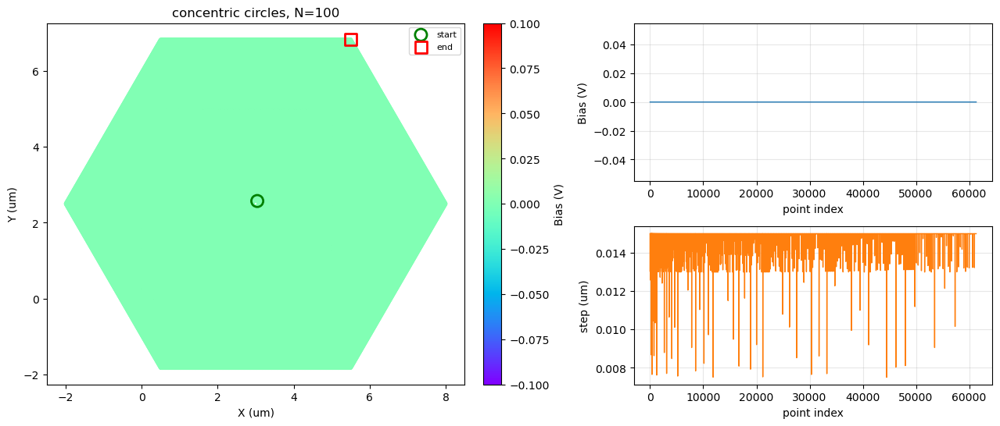

In [206]:
# example: 6-leaf flower in your 2 um frame

tb = gen_concentric_polygons(n_sides=6, n_polygons=60, radius_um=5*1,
                            center_um=(3, 2.5), v=0, field_um=5,
                            step_um=0.015, tb=None, pts_per_um=None,
                            min_radius_um=None, start_angle_deg=60.0,
                            ccw=True, min_pts_per_edge=1)

fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")

tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=5, title="concentric circles, N=100")

In [81]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [82]:
ae.write_spm(commands='TL_RunPy(1.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [83]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Triangles with both signs and directions

In [88]:
import numpy as np


def gen_concentric_polygons(n_sides=6, n_polygons=6, radius_um=0.8,
                            center_um=(1.0, 1.0), v1=5.5, v2=-5.5,
                            field_um=2.0, step_um=0.01, tb=None, pts_per_um=None,
                            min_radius_um=None, start_angle_deg=0.0,
                            min_pts_per_edge=2, connect_rings=True):
    """Concentric regular n-gons, each traced BOTH directions with two voltages.

    For every polygon (inner -> outer):
      1. trace it CCW at voltage v1,
      2. trace the SAME polygon CW at voltage v2,
    then move on to the next (larger) polygon.  So each ring is written twice -- once
    CCW at v1, once CW at v2 -- before advancing.

    n_polygons regular n_sides-gons are drawn at evenly spaced circumradii
    (min_radius -> radius_um).

    n_sides         : number of sides of each polygon (3=triangle, 4=square, ...).
    n_polygons      : number of concentric rings.
    radius_um       : OUTER polygon circumradius (um).
    center_um       : (cx, cy) center of the pattern.
    v1              : voltage on the CCW pass (first pass of each ring).
    v2              : voltage on the CW pass (second pass of each ring).
    field_um, step_um: passed to TrajectoryBuilder if tb is None. step_um is also the
                      default along-edge spacing (see pts_per_um).
    tb              : existing TrajectoryBuilder to append to (else a new one).
    pts_per_um      : along-path point density (points/um). Default 1/step_um, so all
                      edges/rings get the SAME spacing regardless of size.
    min_radius_um   : INNER polygon circumradius (um). Default = radius_um / n_polygons.
    start_angle_deg : rotates every polygon's vertices by this angle (same for all).
    min_pts_per_edge: floor on samples per edge (keeps tiny inner rings sane).
    connect_rings   : if True (default), link the CW pass of one ring to the CCW pass
                      of the NEXT ring with a straight connector, and emit everything
                      as ONE continuous stroke.  The connector voltage matches the
                      voltage of the pass it FOLLOWS (v2, the CW pass just finished),
                      so no 0 V points are inserted.  If False, emit each pass as its
                      own stroke (the TrajectoryBuilder handles the gaps, which may
                      insert 0 V connector points).

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R_out = radius_um

    n_sides = max(3, int(n_sides))
    n_polygons = max(1, int(n_polygons))
    if min_radius_um is None:
        R_in = R_out / n_polygons
    else:
        R_in = min_radius_um

    if n_polygons == 1:
        radii = np.array([R_out])
    else:
        radii = np.linspace(R_in, R_out, n_polygons, endpoint=True)

    if pts_per_um is None:
        if step_um is None or step_um <= 0:
            raise ValueError("Provide pts_per_um, or a positive step_um.")
        pts_per_um = 1.0 / step_um

    a0 = np.deg2rad(start_angle_deg)
    # CCW vertex angles of a regular n-gon (same orientation for every ring)
    vert_ang_ccw = a0 + np.linspace(0.0, 2.0 * np.pi, n_sides, endpoint=False)

    def polygon_points(rk, ccw):
        """Sampled closed-loop points of the ring at radius rk, traced CCW or CW."""
        ang = vert_ang_ccw if ccw else vert_ang_ccw[::-1]
        vx = cx + rk * np.cos(ang)
        vy = cy + rk * np.sin(ang)
        vx = np.append(vx, vx[0])
        vy = np.append(vy, vy[0])
        xs, ys = [], []
        for i in range(n_sides):
            x0, y0 = vx[i], vy[i]
            x1, y1 = vx[i + 1], vy[i + 1]
            edge_len = np.hypot(x1 - x0, y1 - y0)
            npts = int(max(min_pts_per_edge, round(edge_len * pts_per_um)))
            last = (i == n_sides - 1)
            tt = np.linspace(0.0, 1.0, npts, endpoint=last)
            xs.append(x0 + (x1 - x0) * tt)
            ys.append(y0 + (y1 - y0) * tt)
        return np.column_stack([np.concatenate(xs), np.concatenate(ys)])

    # build the two passes (CCW@v1, CW@v2) for every ring
    passes = []   # list of (points, voltage)
    for rk in radii:
        passes.append((polygon_points(rk, ccw=True),  v1))    # CCW pass at v1
        passes.append((polygon_points(rk, ccw=False), v2))    # CW  pass at v2

    if not connect_rings:
        # each pass is its own stroke; TrajectoryBuilder handles gaps (may add 0 V pts)
        for pts, vv in passes:
            tb.stroke(pts, np.full(len(pts), vv, float))
        return tb

    # connect_rings=True: emit ONE continuous stroke walking
    #   ring0 CCW@v1 -> ring0 CW@v2 -> connector -> ring1 CCW@v1 -> ring1 CW@v2 -> ...
    # Each pass keeps its own voltage; a connector to the next ring is held at the
    # voltage of the pass it follows (the CW pass, v2), so there are no 0 V points.
    seg_x, seg_y, seg_v = [], [], []
    for p, (pts, vv) in enumerate(passes):
        seg_x.append(pts[:, 0]); seg_y.append(pts[:, 1])
        seg_v.append(np.full(len(pts), vv, float))
        # add a connector to the NEXT pass's first point (unless this is the last pass)
        if p < len(passes) - 1:
            nxt = passes[p + 1][0]
            x0, y0 = pts[-1]
            x1, y1 = nxt[0]
            clen = np.hypot(x1 - x0, y1 - y0)
            if clen > 0:
                cn = int(max(1, round(clen * pts_per_um)))
                tt = np.linspace(0.0, 1.0, cn + 2)[1:-1]   # interior points only
                if len(tt):
                    seg_x.append(x0 + (x1 - x0) * tt)
                    seg_y.append(y0 + (y1 - y0) * tt)
                    seg_v.append(np.full(len(tt), vv, float))   # hold the pass's V
    X = np.concatenate(seg_x)
    Y = np.concatenate(seg_y)
    V = np.concatenate(seg_v)
    tb.stroke(np.column_stack([X, Y]), V)
    return tb

Wrote 46465 pts to 'output\rose_flower_N64_4um.txt'  (path length 1850.3 um, 1 strokes)


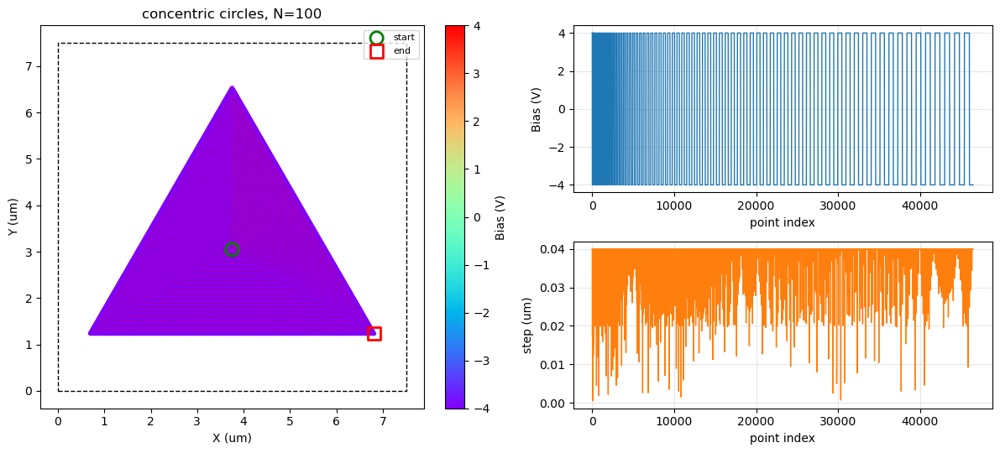

In [118]:
# example: 6-leaf flower in your 2 um frame

tb = gen_concentric_polygons(n_sides=3, n_polygons=75, radius_um=2.5*np.sqrt(2),
                        center_um=(3.75,3.), v1=+4, v2=-4,
                        field_um=5.0, step_um=0.04, tb=None, pts_per_um=None,
                        min_radius_um=None, start_angle_deg=90.0,
                        min_pts_per_edge=2, connect_rings=True)

# gen_concentric_polygons(n_sides=3, n_polygons=60, radius_um=5*1,
#                             center_um=(3, 2.5), v=0, field_um=5,
#                             step_um=0.015, tb=None, pts_per_um=None,
#                             min_radius_um=None, start_angle_deg=60.0,
#                             ccw=True, min_pts_per_edge=1)

fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")

tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=7.5, title="concentric circles, N=100")

In [119]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [120]:
ae.write_spm(commands='TL_RunPy(1.5, 0, 0,  0)')      # live scan center, 0.5 um/s

In [121]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Rotated raster scan

In [19]:
import numpy as np


def gen_raster_backward(n_rows=10, pts_per_row=400, v1=6, v2=-6,
                        center_um=(1.0, 1.0), field_um=2.0, step_um=0.01,
                        tb=None, coverage=1.0):
    """Axis-aligned (0-degree) row-by-row raster poling pattern.

    A regular grid of n_rows rows x pts_per_row columns, filling a centered square of
    side (coverage * field_um).  EVERY row is identical:
      * FORWARD pass : LEFT  -> RIGHT  at voltage v1,
      * BACKWARD pass: RIGHT -> LEFT   at voltage v2  (returns to the left / start side),
    then step UP to the next row and repeat -- so each row always begins at the left.

    n_rows      : number of rows (slow / y axis steps).
    pts_per_row : samples per row (fast / x axis resolution).
    v1          : DC voltage on the forward (left -> right) pass.
    v2          : DC voltage on the backward (right -> left) pass.
    center_um   : (cx, cy) center of the pattern.
    field_um    : side of the square field.
    step_um     : passed to TrajectoryBuilder if tb is None.
    tb          : existing TrajectoryBuilder to append to (else a new one).
    coverage    : 0..1 fraction of the field the raster spans (1.0 = full field).

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um

    side = float(np.clip(coverage, 1e-6, 1.0)) * field_um
    half = side / 2.0

    n_rows = max(1, int(n_rows))
    pts_per_row = max(2, int(pts_per_row))

    # y positions of the rows (slow axis), x samples along a row (fast axis)
    if n_rows == 1:
        ys = np.array([cy])
    else:
        ys = np.linspace(cy - half, cy + half, n_rows, endpoint=True)
    xs_LtoR = np.linspace(cx - half, cx + half, pts_per_row, endpoint=True)  # left->right

    for y in ys:
        yrow = np.full(pts_per_row, y, float)
        # FORWARD pass at v1: LEFT -> RIGHT
        tb.stroke(np.column_stack([xs_LtoR, yrow]), np.full(pts_per_row, v1, float))
        # BACKWARD pass at v2: RIGHT -> LEFT (back to the start side)
        tb.stroke(np.column_stack([xs_LtoR[::-1], yrow]), np.full(pts_per_row, v2, float))

    return tb

In [20]:
# import numpy as np


# def gen_raster_backward(n_rows=10, pts_per_row=400, v1=6, v2=-6,
#                         center_um=(1.0, 1.0), field_um=2.0, step_um=0.01,
#                         tb=None, coverage=1.0, angle_deg=0.0):
#     """Row-by-row raster poling pattern, optionally rotated by an angle.

#     A regular grid of n_rows rows x pts_per_row columns.  EVERY row is identical (in
#     the rotated frame):
#       * FORWARD pass : START -> END  at voltage v1,
#       * BACKWARD pass: END -> START  at voltage v2  (returns to the start side),
#     then step to the next row and repeat -- so each row always begins on the same side.

#     The whole grid is rotated by angle_deg about center_um.  The scanned area is shrunk
#     so the rotated grid still fits inside the field_um x field_um square (a rotated
#     square of side s fits inside a square of side field only if
#     s <= field / (|cos| + |sin|)); we use that bound, optionally scaled by coverage.
#     At angle_deg = 0 this reduces to a full-field axis-aligned raster (forward L->R,
#     backward R->L).

#     n_rows      : number of rows (slow-axis steps).
#     pts_per_row : samples per row (fast-axis resolution).
#     v1          : DC voltage on the forward (start -> end) pass.
#     v2          : DC voltage on the backward (end -> start) pass.
#     center_um   : (cx, cy) center of the pattern (and rotation center).
#     field_um    : side of the square field the pattern must stay within.
#     step_um     : passed to TrajectoryBuilder if tb is None.
#     tb          : existing TrajectoryBuilder to append to (else a new one).
#     coverage    : 0..1 fraction of the max fitting size to use (1.0 = touch the field
#                   edges; <1 leaves a margin).
#     angle_deg   : rotation of the whole raster about the center (deg, CCW).

#     Returns the TrajectoryBuilder.
#     """
#     tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
#     cx, cy = center_um
#     th = np.deg2rad(angle_deg)
#     c, s = np.cos(th), np.sin(th)

#     # largest centered square that, rotated by th, still fits in the field
#     # (at angle 0 this is just field_um; scaled by coverage for a margin).
#     fit = field_um / (abs(c) + abs(s))
#     side = float(np.clip(coverage, 1e-6, 1.0)) * fit
#     half = side / 2.0

#     n_rows = max(1, int(n_rows))
#     pts_per_row = max(2, int(pts_per_row))

#     # local (unrotated) grid, centered on origin, spanning +/- half
#     if n_rows == 1:
#         lys = np.array([0.0])
#     else:
#         lys = np.linspace(-half, half, n_rows, endpoint=True)      # slow axis
#     lxs = np.linspace(-half, half, pts_per_row, endpoint=True)      # fast axis (start->end)

#     def to_world(lx, ly):
#         # rotate local (lx, ly) by th, translate to center
#         wx = cx + lx * c - ly * s
#         wy = cy + lx * s + ly * c
#         return wx, wy

#     for ly in lys:
#         lyrow = np.full(pts_per_row, ly, float)
#         # FORWARD pass at v1: start -> end (local +x direction)
#         fx, fy = to_world(lxs, lyrow)
#         tb.stroke(np.column_stack([fx, fy]), np.full(pts_per_row, v1, float))
#         # BACKWARD pass at v2: end -> start (reversed), back to the start side
#         bx, by = to_world(lxs[::-1], lyrow)
#         tb.stroke(np.column_stack([bx, by]), np.full(pts_per_row, v2, float))

#     return tb

In [10]:
import numpy as np


def gen_raster_backward(n_rows=10, pts_per_row=400, v1=6, v2=-6,
                        center_um=(1.0, 1.0), field_um=2.0, step_um=0.01,
                        tb=None, coverage=1.0, angle_deg=0.0, n_pt=10):
    """Row-by-row raster poling pattern, optionally rotated, with BIAS-SETTLE dwells
    at every voltage transition.

    A regular grid of n_rows rows x pts_per_row columns.  EVERY row is identical (in
    the rotated frame):
      * FORWARD pass : START -> END  at voltage v1,
      * BACKWARD pass: END -> START  at voltage v2  (returns to the start side),
    then step to the next row and repeat.

    At each point where the applied voltage CHANGES, n_pt stationary "settle" points
    are inserted (the tip holds its position while the bias fully transitions to the
    new value before it starts moving):
      * at the END point, hold v2 for n_pt samples BEFORE the backward pass,
      * at the START point, hold v1 for n_pt samples BEFORE the next row's forward pass.
    This guarantees the bias has fully reached the new value before the tip moves into
    the next trace.

    The whole grid is rotated by angle_deg about center_um and shrunk to fit inside the
    field (a rotated square of side s fits if s <= field/(|cos|+|sin|), scaled by
    coverage). At angle_deg = 0 this is a full-field axis-aligned raster.

    n_rows      : number of rows (slow-axis steps).
    pts_per_row : samples per row (fast-axis resolution).
    v1          : DC voltage on the forward (start -> end) pass.
    v2          : DC voltage on the backward (end -> start) pass.
    center_um   : (cx, cy) center of the pattern (and rotation center).
    field_um    : side of the square field the pattern must stay within.
    step_um     : passed to TrajectoryBuilder if tb is None.
    tb          : existing TrajectoryBuilder to append to (else a new one).
    coverage    : 0..1 fraction of the max fitting size to use.
    angle_deg   : rotation of the whole raster about the center (deg, CCW).
    n_pt        : number of stationary settle points inserted at each voltage change
                  (held at the NEW voltage, at the tip's current position). 0 disables.

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)

    fit = field_um / (abs(c) + abs(s))
    side = float(np.clip(coverage, 1e-6, 1.0)) * fit
    half = side / 2.0

    n_rows = max(1, int(n_rows))
    pts_per_row = max(2, int(pts_per_row))
    n_pt = max(0, int(n_pt))

    if n_rows == 1:
        lys = np.array([0.0])
    else:
        lys = np.linspace(-half, half, n_rows, endpoint=True)      # slow axis
    lxs = np.linspace(-half, half, pts_per_row, endpoint=True)      # fast axis

    def to_world(lx, ly):
        wx = cx + lx * c - ly * s
        wy = cy + lx * s + ly * c
        return wx, wy

    def dwell(x, y, v):
        """n_pt stationary points at (x,y) held at voltage v (bias settle)."""
        if n_pt <= 0:
            return
        pts = np.column_stack([np.full(n_pt, x, float), np.full(n_pt, y, float)])
        tb.stroke(pts, np.full(n_pt, v, float))

    for ly in lys:
        lyrow = np.full(pts_per_row, ly, float)

        # FORWARD pass at v1: start -> end
        fx, fy = to_world(lxs, lyrow)
        tb.stroke(np.column_stack([fx, fy]), np.full(pts_per_row, v1, float))

        # voltage change v1 -> v2: settle at the END point before backward pass
        dwell(fx[-1], fy[-1], v2)

        # BACKWARD pass at v2: end -> start
        bx, by = to_world(lxs[::-1], lyrow)
        tb.stroke(np.column_stack([bx, by]), np.full(pts_per_row, v2, float))

        # voltage change v2 -> v1: settle at the START point before the next row's
        # forward pass (do this after every row so the next row begins already at v1).
        dwell(bx[-1], by[-1], v1)

    return tb

Wrote 32829 pts to 'output\lines.txt'  (path length 959.0 um, 384 strokes)


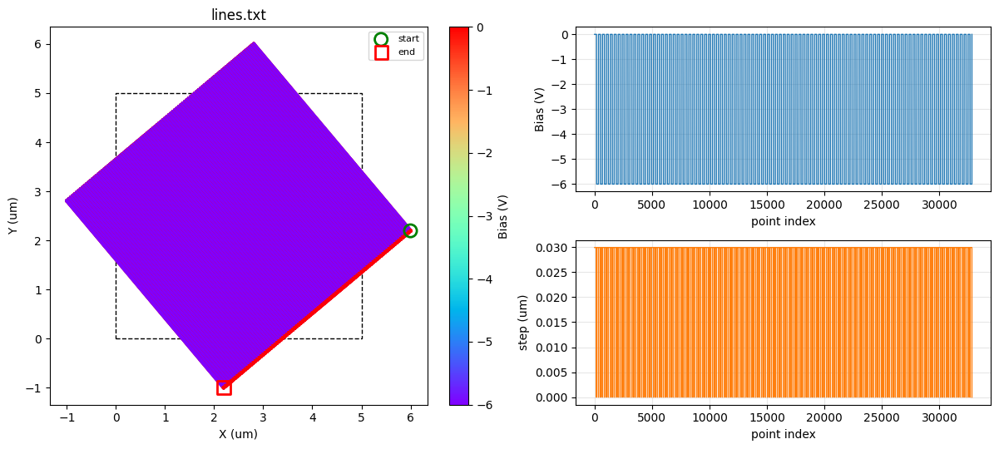

In [40]:


tb = gen_raster_backward(n_rows=96, pts_per_row=0, angle_deg=130,
                                v1=0, v2=-6, center_um=(2.5, 2.5), field_um=7.*1,
                                step_um=0.03, tb=None, coverage=1.0,
                                )

fname = os.path.join(CONFIG["work_dir"], "lines.txt")
tb.save(fname)

visualize_trajectory(tb=tb, field_um=5, title="lines.txt")

In [41]:
5000/128

39.0625

In [42]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\lines.txt")


In [43]:
ae.write_spm(commands='TL_RunPy(1, 0, 0,  0)')      # live scan center, 0.5 um/s

In [44]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Domain selective writing

### Helper Functions 

In [44]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.path import Path as MplPath

# # segmentation / labeling
# from scipy import ndimage as ndi
# try:
#     from skimage.filters import threshold_otsu
#     from skimage.measure import label as cc_label, regionprops, find_contours
#     from skimage.morphology import remove_small_objects, disk
#     try:
#         from skimage.morphology import binary_closing
#     except Exception:
#         from skimage.morphology import closing as binary_closing
#     _HAVE_SKIMAGE = True
# except Exception:
#     _HAVE_SKIMAGE = False


# def segment_pfm_map(img, channel="phase", n_levels=2, smooth_px=1.0,
#                     min_size_px=20, close_px=1):
#     """Segment a PFM amplitude or phase map into labeled domains.

#     img        : 2D array (the lateral PFM amplitude or phase map).
#     channel    : "phase" -> threshold into n_levels bands (phase is the clean domain
#                  contrast for switching; default 2 levels = two phase states).
#                  "amplitude" -> low-amplitude pixels are domain WALLS; domains are the
#                  high-amplitude connected regions between them.
#     n_levels   : for channel="phase", number of phase bands to split into (2 typical).
#     smooth_px  : Gaussian pre-smoothing (pixels) to tame noise before thresholding.
#     min_size_px: drop connected components smaller than this many pixels.
#     close_px   : binary-closing radius (pixels) to fill pinholes.

#     Returns
#     -------
#     labels : 2D int array, 0 = background/wall, 1..N = domain ids.
#     info   : dict with 'centroids' {id:(row,col)}, 'areas' {id:px}, 'channel'.
#     """
#     img = np.asarray(img, float)
#     a = img.copy()
#     # fill NaNs with the median so thresholding is stable
#     if np.any(~np.isfinite(a)):
#         a[~np.isfinite(a)] = np.nanmedian(a)
#     if smooth_px and smooth_px > 0:
#         a = ndi.gaussian_filter(a, smooth_px)

#     if channel.lower().startswith("phase"):
#         # split the phase range into n_levels bands; each band -> its own mask, then
#         # connected-component label across all bands so each contiguous domain is unique.
#         lo, hi = np.percentile(a, [1, 99])
#         edges = np.linspace(lo, hi, n_levels + 1)
#         band = np.zeros(a.shape, int)
#         for i in range(n_levels):
#             band[(a >= edges[i]) & (a <= edges[i + 1])] = i + 1
#         # label each band's regions separately, then merge into one id space
#         labels = np.zeros(a.shape, int)
#         next_id = 1
#         for i in range(1, n_levels + 1):
#             m = band == i
#             if close_px and _HAVE_SKIMAGE:
#                 m = binary_closing(m, disk(close_px))
#             lab = _cc(m)
#             for rid in range(1, lab.max() + 1):
#                 comp = lab == rid
#                 if comp.sum() >= min_size_px:
#                     labels[comp] = next_id
#                     next_id += 1
#     else:
#         # amplitude: high amplitude = domain interior, low = wall. Otsu split.
#         thr = (threshold_otsu(a) if _HAVE_SKIMAGE else np.percentile(a, 50))
#         interior = a >= thr
#         if close_px and _HAVE_SKIMAGE:
#             interior = binary_closing(interior, disk(close_px))
#         labels = _cc(interior)
#         # drop small
#         if _HAVE_SKIMAGE:
#             big = remove_small_objects(labels > 0, min_size=min_size_px)
#             labels[~big] = 0
#             labels = _cc(labels > 0)

#     # centroids & areas
#     centroids, areas = {}, {}
#     for rid in range(1, labels.max() + 1):
#         comp = labels == rid
#         if comp.sum() == 0:
#             continue
#         rr, cc = np.nonzero(comp)
#         centroids[rid] = (rr.mean(), cc.mean())
#         areas[rid] = int(comp.sum())
#     info = {"centroids": centroids, "areas": areas, "channel": channel}
#     return labels, info


# def _cc(mask):
#     """Connected-component label (skimage if available, else scipy)."""
#     if _HAVE_SKIMAGE:
#         return cc_label(mask)
#     lab, _ = ndi.label(mask)
#     return lab


# def _px_to_um(rc, shape, field_um, center_um, origin="corner"):
#     """Map (row, col) pixel coords to (x_um, y_um).
#     Assumes a square field of field_um across `shape` pixels, with the image's
#     physical extent [0, field_um] in both axes (corner origin) centered so the
#     field center is at center_um. Image row increases DOWNWARD; we flip to make
#     +y point up (standard physical convention). Adjust if your data differs.
#     """
#     rows, cols = shape
#     r, c = rc[..., 0], rc[..., 1]
#     # pixel -> [0, field_um]
#     x = (c + 0.5) / cols * field_um
#     y = (1.0 - (r + 0.5) / rows) * field_um     # flip row so +y is up
#     # shift so the field center sits at center_um
#     cx, cy = center_um
#     x = x - field_um / 2.0 + cx
#     y = y - field_um / 2.0 + cy
#     return np.stack([x, y], axis=-1)


# def gen_domain_fix_traces(img, field_um=2.0, center_um=(1.0, 1.0), step_um=0.01,
#                           channel="phase", n_levels=2,
#                           select_id=None, select_xy_um=None,
#                           angle_deg=0.0, line_spacing_um=0.05,
#                           v_forward=0.0, v_backward=-5.5,
#                           margin_um=0.0, pts_per_um=None, tb=None,
#                           smooth_px=1.0, min_size_px=20, close_px=1,
#                           interactive=True, plot=True):
#     """Segment a PFM map, let the user pick a domain, and generate angled linear
#     poling traces that cover the selected domain.

#     Each trace line is written as TWO strokes:
#       * FORWARD  pass at v_forward  (default 0 V -> travel only),
#       * BACKWARD pass at v_backward (the poling pass).
#     Parallel lines at `angle_deg` are spaced `line_spacing_um` apart and clipped to
#     the selected domain (only the portions inside the domain are written).

#     img            : 2D PFM amplitude or phase map (the domain image to segment).
#     field_um       : physical size of the (square) scan field (um).
#     center_um      : (cx, cy) physical center of the field (um) -- where the litho
#                      pattern is centered; must match your litho center.
#     step_um        : TrajectoryBuilder step; also default along-line spacing if
#                      pts_per_um is None.
#     channel        : "phase" or "amplitude" (see segment_pfm_map).
#     n_levels       : phase bands (channel="phase").
#     select_id      : domain label id to write. If None, selection is interactive
#                      (click) or via select_xy_um.
#     select_xy_um   : (x_um, y_um) point inside the domain to select (non-interactive).
#     angle_deg      : orientation of the poling lines (deg, CCW from +x).
#     line_spacing_um: spacing between adjacent parallel lines (um).
#     v_forward      : voltage on the forward pass of each line (default 0).
#     v_backward     : voltage on the backward (poling) pass of each line.
#     margin_um      : grow (or, if negative, shrink) the domain mask by this much
#                      before clipping the lines (um).
#     pts_per_um     : along-line point density (points/um). Default 1/step_um.
#     tb             : existing TrajectoryBuilder to append to (else a new one).
#     smooth_px/min_size_px/close_px : segmentation knobs.
#     interactive    : if True and no select_id/select_xy_um given, open a click picker.
#     plot           : show the segmentation + chosen lines.

#     Returns
#     -------
#     (tb, labels, chosen_id)
#     """
#     tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
#     img = np.asarray(img, float)
#     rows, cols = img.shape

#     # 1) segment
#     labels, info = segment_pfm_map(img, channel=channel, n_levels=n_levels,
#                                    smooth_px=smooth_px, min_size_px=min_size_px,
#                                    close_px=close_px)
#     if labels.max() == 0:
#         raise RuntimeError("Segmentation found no domains; adjust channel/thresholds.")

#     # 2) choose a domain
#     chosen_id = select_id
#     if chosen_id is None and select_xy_um is not None:
#         # map the physical point back to a pixel and read its label
#         x, y = select_xy_um
#         cx, cy = center_um
#         col = int(round(((x - cx + field_um / 2.0) / field_um) * cols - 0.5))
#         row = int(round((1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5))
#         row = np.clip(row, 0, rows - 1); col = np.clip(col, 0, cols - 1)
#         chosen_id = int(labels[row, col])
#         if chosen_id == 0:
#             # snap to nearest labeled pixel
#             chosen_id = _nearest_label(labels, row, col)
#     if chosen_id is None and interactive:
#         chosen_id = _pick_domain_interactive(img, labels)
#     if chosen_id is None:
#         # fallback: largest domain
#         chosen_id = max(info["areas"], key=info["areas"].get)
#         print(f"No selection given; defaulting to largest domain id={chosen_id}.")
#     if chosen_id not in info["areas"]:
#         raise ValueError(f"Domain id {chosen_id} not found. Available: {sorted(info['areas'])}")

#     # 3) build the domain mask (optionally grown/shrunk by margin)
#     mask = labels == chosen_id
#     if margin_um and margin_um != 0:
#         px = max(1, int(round(abs(margin_um) / (field_um / cols))))
#         if margin_um > 0:
#             mask = ndi.binary_dilation(mask, iterations=px)
#         else:
#             mask = ndi.binary_erosion(mask, iterations=px)

#     # 4) generate parallel lines at angle_deg, clipped to the mask, then stroke them
#     seg_list = _lines_clipped_to_mask(mask, field_um, center_um,
#                                       angle_deg, line_spacing_um,
#                                       step_um, pts_per_um)
#     n_written = 0
#     for pts in seg_list:               # pts: (M,2) array of (x_um, y_um) inside domain
#         if len(pts) < 2:
#             continue
#         # forward pass (e.g. 0 V travel), then backward pass (poling)
#         tb.stroke(pts, np.full(len(pts), v_forward, float))
#         tb.stroke(pts[::-1], np.full(len(pts), v_backward, float))
#         n_written += 1

#     print(f"Domain id={chosen_id}: area={info['areas'][chosen_id]} px; "
#           f"wrote {n_written} lines at {angle_deg} deg, spacing {line_spacing_um} um; "
#           f"V_fwd={v_forward}, V_back={v_backward}.")

#     if plot:
#         _plot_result(img, labels, chosen_id, seg_list, field_um, center_um, channel)

#     return tb, labels, chosen_id


# # ---------------------------------------------------------------------------
# # helpers
# # ---------------------------------------------------------------------------
# def _nearest_label(labels, row, col):
#     rr, cc = np.nonzero(labels > 0)
#     if len(rr) == 0:
#         return 0
#     d = (rr - row) ** 2 + (cc - col) ** 2
#     i = np.argmin(d)
#     return int(labels[rr[i], cc[i]])


# def _pick_domain_interactive(img, labels):
#     """Show the map + labels and let the user click a domain. Returns the clicked id."""
#     fig, ax = plt.subplots(figsize=(6, 6))
#     ax.imshow(img, cmap="viridis")
#     ax.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.5)
#     ax.set_title("Click inside the domain to WRITE, then close the window")
#     clicked = {}

#     def onclick(event):
#         if event.inaxes != ax or event.xdata is None:
#             return
#         c, r = int(round(event.xdata)), int(round(event.ydata))
#         rid = int(labels[np.clip(r, 0, labels.shape[0]-1),
#                          np.clip(c, 0, labels.shape[1]-1)])
#         if rid == 0:
#             rid = _nearest_label(labels, r, c)
#         clicked["id"] = rid
#         ax.set_title(f"Selected domain id={rid} (close window to confirm)")
#         fig.canvas.draw_idle()

#     cid = fig.canvas.mpl_connect("button_press_event", onclick)
#     plt.show()
#     fig.canvas.mpl_disconnect(cid)
#     return clicked.get("id", None)


# def _lines_clipped_to_mask(mask, field_um, center_um, angle_deg, spacing_um,
#                            step_um, pts_per_um):
#     """Generate parallel lines at angle_deg spanning the mask bbox, sample each line
#     densely, keep only the samples inside the mask, and split into contiguous runs."""
#     rows, cols = mask.shape
#     cx, cy = center_um
#     # pixel size in um
#     px_um = field_um / cols
#     if pts_per_um is None:
#         pts_per_um = 1.0 / step_um if (step_um and step_um > 0) else (1.0 / px_um)

#     th = np.deg2rad(angle_deg)
#     u = np.array([np.cos(th), np.sin(th)])          # along-line direction
#     n = np.array([-np.sin(th), np.cos(th)])         # line-to-line (normal) direction

#     # physical coords of all mask pixels (centers)
#     rr, cc = np.nonzero(mask)
#     if len(rr) == 0:
#         return []
#     P = _px_to_um(np.stack([rr, cc], axis=-1), mask.shape, field_um, center_um)
#     s_along = P @ u                                  # projection along line dir
#     s_norm = P @ n                                   # projection along normal
#     smin_a, smax_a = s_along.min(), s_along.max()
#     smin_n, smax_n = s_norm.min(), s_norm.max()

#     # build a fast point-in-mask test via the label grid
#     def inside(xy):
#         x, y = xy[..., 0], xy[..., 1]
#         col = ((x - cx + field_um / 2.0) / field_um) * cols - 0.5
#         row = (1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5
#         ci = np.clip(np.round(col).astype(int), 0, cols - 1)
#         ri = np.clip(np.round(row).astype(int), 0, rows - 1)
#         return mask[ri, ci]

#     n_offsets = max(1, int(np.floor((smax_n - smin_n) / spacing_um)) + 1)
#     along = np.arange(smin_a - px_um, smax_a + px_um, 1.0 / pts_per_um)

#     segments = []
#     for j in range(n_offsets):
#         off = smin_n + j * spacing_um
#         line_pts = (np.outer(along, u) + off * n)    # (L,2) physical coords
#         ins = inside(line_pts)
#         if not ins.any():
#             continue
#         # split into contiguous inside-runs
#         idx = np.nonzero(ins)[0]
#         splits = np.split(idx, np.nonzero(np.diff(idx) > 1)[0] + 1)
#         for run in splits:
#             if len(run) >= 2:
#                 segments.append(line_pts[run])
#     return segments


# def _plot_result(img, labels, chosen_id, seg_list, field_um, center_um, channel):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
#     ax1.imshow(img, origin='lower', cmap="viridis")
#     ax1.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.4)
#     ax1.contour(labels == chosen_id, levels=[0.5], colors="r", linewidths=1.5)
#     ax1.set_title(f"Segmentation ({channel}); selected domain in red (id={chosen_id})")

#     cx, cy = center_um
#     ext = [cx - field_um/2, cx + field_um/2, cy - field_um/2, cy + field_um/2]
#     ax2.imshow(img, origin='lower', cmap="gray", extent=ext, alpha=0.4)
#     for pts in seg_list:
#         ax2.plot(pts[:, 0], pts[:, 1], "-", lw=1.0)
#     ax2.set_aspect("equal")
#     ax2.add_patch(plt.Rectangle((cx-field_um/2, cy-field_um/2), field_um, field_um,
#                                 fill=False, ls="--", ec="k"))
#     ax2.set_xlabel("X (um)"); ax2.set_ylabel("Y (um)")
#     ax2.set_title("Poling lines clipped to the selected domain")
#     plt.tight_layout(); plt.show()
    


In [45]:
"""
Helper utilities + step-by-step usage for gen_domain_fix_traces in a Jupyter notebook.

Two ways to select a domain:
  (A) CLICK  -> needs an interactive matplotlib backend (ipympl / %matplotlib widget)
  (B) BY ID  -> works in ANY notebook (inline backend): show numbered domains, pass id
                (recommended, most robust)
"""
import numpy as np
import matplotlib.pyplot as plt
# from gen_domain_fix_traces import segment_pfm_map, gen_domain_fix_traces


def show_domains(img, channel="phase", n_levels=2, smooth_px=1.0,
                 min_size_px=20, close_px=1, figsize=(7, 7)):
    """Segment and DISPLAY all domains with their ID numbers printed at each centroid.
    Works with the plain inline backend. Read off the id you want, then pass it as
    select_id=... to gen_domain_fix_traces.

    Returns (labels, info) so you can also inspect areas/centroids programmatically.
    """
    labels, info = segment_pfm_map(img, channel=channel, n_levels=n_levels,
                                   smooth_px=smooth_px, min_size_px=min_size_px,
                                   close_px=close_px)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img,  origin='lower', cmap="viridis")
    ax.contour(labels, levels=np.arange(0.5, labels.max() + 1),
               colors="w", linewidths=0.5)
    for rid, (r, c) in info["centroids"].items():
        ax.text(c, r, str(rid), color="red", fontsize=12, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="red", alpha=0.8))
    ax.set_title(f"Domains ({channel}, {labels.max()} found) — note the ID you want")
    plt.tight_layout(); plt.show()

    # also print a sorted table by area
    print("id :  area(px)   centroid(row,col)")
    for rid in sorted(info["areas"], key=info["areas"].get, reverse=True):
        r, c = info["centroids"][rid]
        print(f"{rid:>3}: {info['areas'][rid]:>8}   ({r:.0f}, {c:.0f})")
    return labels, info

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

# segmentation / labeling
from scipy import ndimage as ndi
try:
    from skimage.filters import threshold_otsu
    from skimage.measure import label as cc_label, regionprops, find_contours
    from skimage.morphology import remove_small_objects, disk
    try:
        from skimage.morphology import binary_closing
    except Exception:
        from skimage.morphology import closing as binary_closing
    _HAVE_SKIMAGE = True
except Exception:
    _HAVE_SKIMAGE = False


def segment_pfm_map(img, channel="phase", n_levels=2, smooth_px=1.0,
                    min_size_px=20, close_px=1):
    """Segment a PFM amplitude or phase map into labeled domains.

    img        : 2D array (the lateral PFM amplitude or phase map).
    channel    : "phase" -> threshold into n_levels bands (phase is the clean domain
                 contrast for switching; default 2 levels = two phase states).
                 "amplitude" -> low-amplitude pixels are domain WALLS; domains are the
                 high-amplitude connected regions between them.
    n_levels   : for channel="phase", number of phase bands to split into (2 typical).
    smooth_px  : Gaussian pre-smoothing (pixels) to tame noise before thresholding.
    min_size_px: drop connected components smaller than this many pixels.
    close_px   : binary-closing radius (pixels) to fill pinholes.

    Returns
    -------
    labels : 2D int array, 0 = background/wall, 1..N = domain ids.
    info   : dict with 'centroids' {id:(row,col)}, 'areas' {id:px}, 'channel'.
    """
    img = np.asarray(img, float)
    a = img.copy()
    # fill NaNs with the median so thresholding is stable
    if np.any(~np.isfinite(a)):
        a[~np.isfinite(a)] = np.nanmedian(a)
    if smooth_px and smooth_px > 0:
        a = ndi.gaussian_filter(a, smooth_px)

    if channel.lower().startswith("phase"):
        # split the phase range into n_levels bands; each band -> its own mask, then
        # connected-component label across all bands so each contiguous domain is unique.
        lo, hi = np.percentile(a, [1, 99])
        edges = np.linspace(lo, hi, n_levels + 1)
        band = np.zeros(a.shape, int)
        for i in range(n_levels):
            band[(a >= edges[i]) & (a <= edges[i + 1])] = i + 1
        # label each band's regions separately, then merge into one id space
        labels = np.zeros(a.shape, int)
        next_id = 1
        for i in range(1, n_levels + 1):
            m = band == i
            if close_px and _HAVE_SKIMAGE:
                m = binary_closing(m, disk(close_px))
            lab = _cc(m)
            for rid in range(1, lab.max() + 1):
                comp = lab == rid
                if comp.sum() >= min_size_px:
                    labels[comp] = next_id
                    next_id += 1
    else:
        # amplitude: high amplitude = domain interior, low = wall. Otsu split.
        thr = (threshold_otsu(a) if _HAVE_SKIMAGE else np.percentile(a, 50))
        interior = a >= thr
        if close_px and _HAVE_SKIMAGE:
            interior = binary_closing(interior, disk(close_px))
        labels = _cc(interior)
        # drop small
        if _HAVE_SKIMAGE:
            big = remove_small_objects(labels > 0, min_size=min_size_px)
            labels[~big] = 0
            labels = _cc(labels > 0)

    # centroids & areas
    centroids, areas = {}, {}
    for rid in range(1, labels.max() + 1):
        comp = labels == rid
        if comp.sum() == 0:
            continue
        rr, cc = np.nonzero(comp)
        centroids[rid] = (rr.mean(), cc.mean())
        areas[rid] = int(comp.sum())
    info = {"centroids": centroids, "areas": areas, "channel": channel}
    return labels, info


def _cc(mask):
    """Connected-component label (skimage if available, else scipy)."""
    if _HAVE_SKIMAGE:
        return cc_label(mask)
    lab, _ = ndi.label(mask)
    return lab


def _px_to_um(rc, shape, field_um, center_um, flip_y=False):
    """Map (row, col) pixel coords to (x_um, y_um).
    Square field of field_um across `shape` pixels, physical extent [0, field_um] in
    both axes, field center at center_um.

    flip_y : how image ROW maps to physical Y.
      False (default) -> row 0 = TOP of the field (largest y).  This matches how the
                         segmentation is displayed with imshow(origin='upper'), so the
                         lines land exactly where the red domain appears on screen.
      True            -> row 0 = BOTTOM (+y up, standard math convention). Use only if
                         your AFM stores/streams Y with that orientation.
    """
    rows, cols = shape
    r, c = rc[..., 0], rc[..., 1]
    x = (c + 0.5) / cols * field_um
    if flip_y:
        y = (1.0 - (r + 0.5) / rows) * field_um     # row 0 at bottom (+y up)
    else:
        y = (r + 0.5) / rows * field_um             # row 0 at top (matches imshow)
    cx, cy = center_um
    x = x - field_um / 2.0 + cx
    y = y - field_um / 2.0 + cy
    return np.stack([x, y], axis=-1)


def gen_domain_fix_traces(img, field_um=2.0, center_um=(1.0, 1.0), step_um=0.01,
                          channel="phase", n_levels=2,
                          select_id=None, select_xy_um=None,
                          angle_deg=0.0, line_spacing_um=0.05,
                          v_forward=0.0, v_backward=-5.5,
                          margin_um=0.0, pts_per_um=None, tb=None,
                          smooth_px=1.0, min_size_px=20, close_px=1,
                          interactive=True, plot=True, flip_y=False):
    """Segment a PFM map, let the user pick a domain, and generate angled linear
    poling traces that cover the selected domain.

    Each trace line is written as TWO strokes:
      * FORWARD  pass at v_forward  (default 0 V -> travel only),
      * BACKWARD pass at v_backward (the poling pass).
    Parallel lines at `angle_deg` are spaced `line_spacing_um` apart and clipped to
    the selected domain (only the portions inside the domain are written).

    img            : 2D PFM amplitude or phase map (the domain image to segment).
    field_um       : physical size of the (square) scan field (um).
    center_um      : (cx, cy) physical center of the field (um) -- where the litho
                     pattern is centered; must match your litho center.
    step_um        : TrajectoryBuilder step; also default along-line spacing if
                     pts_per_um is None.
    channel        : "phase" or "amplitude" (see segment_pfm_map).
    n_levels       : phase bands (channel="phase").
    select_id      : domain label id to write. If None, selection is interactive
                     (click) or via select_xy_um.
    select_xy_um   : (x_um, y_um) point inside the domain to select (non-interactive).
    angle_deg      : orientation of the poling lines (deg, CCW from +x).
    line_spacing_um: spacing between adjacent parallel lines (um).
    v_forward      : voltage on the forward pass of each line (default 0).
    v_backward     : voltage on the backward (poling) pass of each line.
    margin_um      : grow (or, if negative, shrink) the domain mask by this much
                     before clipping the lines (um).
    pts_per_um     : along-line point density (points/um). Default 1/step_um.
    tb             : existing TrajectoryBuilder to append to (else a new one).
    smooth_px/min_size_px/close_px : segmentation knobs.
    interactive    : if True and no select_id/select_xy_um given, open a click picker.
    plot           : show the segmentation + chosen lines.

    Returns
    -------
    (tb, labels, chosen_id)
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    img = np.asarray(img, float)
    rows, cols = img.shape

    # 1) segment
    labels, info = segment_pfm_map(img, channel=channel, n_levels=n_levels,
                                   smooth_px=smooth_px, min_size_px=min_size_px,
                                   close_px=close_px)
    if labels.max() == 0:
        raise RuntimeError("Segmentation found no domains; adjust channel/thresholds.")

    # 2) choose a domain
    chosen_id = select_id
    if chosen_id is None and select_xy_um is not None:
        # map the physical point back to a pixel and read its label
        x, y = select_xy_um
        cx, cy = center_um
        col = int(round(((x - cx + field_um / 2.0) / field_um) * cols - 0.5))
        if flip_y:
            row = int(round((1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5))
        else:
            row = int(round(((y - cy + field_um / 2.0) / field_um) * rows - 0.5))
        row = np.clip(row, 0, rows - 1); col = np.clip(col, 0, cols - 1)
        chosen_id = int(labels[row, col])
        if chosen_id == 0:
            # snap to nearest labeled pixel
            chosen_id = _nearest_label(labels, row, col)
    if chosen_id is None and interactive:
        chosen_id = _pick_domain_interactive(img, labels)
    if chosen_id is None:
        # fallback: largest domain
        chosen_id = max(info["areas"], key=info["areas"].get)
        print(f"No selection given; defaulting to largest domain id={chosen_id}.")
    if chosen_id not in info["areas"]:
        raise ValueError(f"Domain id {chosen_id} not found. Available: {sorted(info['areas'])}")

    # 3) build the domain mask (optionally grown/shrunk by margin)
    mask = labels == chosen_id
    if margin_um and margin_um != 0:
        px = max(1, int(round(abs(margin_um) / (field_um / cols))))
        if margin_um > 0:
            mask = ndi.binary_dilation(mask, iterations=px)
        else:
            mask = ndi.binary_erosion(mask, iterations=px)

    # 4) generate parallel lines at angle_deg, clipped to the mask, then stroke them
    seg_list = _lines_clipped_to_mask(mask, field_um, center_um,
                                      angle_deg, line_spacing_um,
                                      step_um, pts_per_um, flip_y=flip_y)
    n_written = 0
    for pts in seg_list:               # pts: (M,2) array of (x_um, y_um) inside domain
        if len(pts) < 2:
            continue
        # forward pass (e.g. 0 V travel), then backward pass (poling)
        tb.stroke(pts, np.full(len(pts), v_forward, float))
        tb.stroke(pts[::-1], np.full(len(pts), v_backward, float))
        n_written += 1

    print(f"Domain id={chosen_id}: area={info['areas'][chosen_id]} px; "
          f"wrote {n_written} lines at {angle_deg} deg, spacing {line_spacing_um} um; "
          f"V_fwd={v_forward}, V_back={v_backward}.")

    if plot:
        _plot_result(img, labels, chosen_id, seg_list, field_um, center_um, channel,
                     flip_y=flip_y)

    return tb, labels, chosen_id


# ---------------------------------------------------------------------------
# helpers
# ---------------------------------------------------------------------------
def _nearest_label(labels, row, col):
    rr, cc = np.nonzero(labels > 0)
    if len(rr) == 0:
        return 0
    d = (rr - row) ** 2 + (cc - col) ** 2
    i = np.argmin(d)
    return int(labels[rr[i], cc[i]])


def _pick_domain_interactive(img, labels):
    """Show the map + labels and let the user click a domain. Returns the clicked id."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap="viridis")
    ax.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.5)
    ax.set_title("Click inside the domain to WRITE, then close the window")
    clicked = {}

    def onclick(event):
        if event.inaxes != ax or event.xdata is None:
            return
        c, r = int(round(event.xdata)), int(round(event.ydata))
        rid = int(labels[np.clip(r, 0, labels.shape[0]-1),
                         np.clip(c, 0, labels.shape[1]-1)])
        if rid == 0:
            rid = _nearest_label(labels, r, c)
        clicked["id"] = rid
        ax.set_title(f"Selected domain id={rid} (close window to confirm)")
        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()
    fig.canvas.mpl_disconnect(cid)
    return clicked.get("id", None)


def _lines_clipped_to_mask(mask, field_um, center_um, angle_deg, spacing_um,
                           step_um, pts_per_um, flip_y=False):
    """Generate parallel lines at angle_deg spanning the mask bbox, sample each line
    densely, keep only the samples inside the mask, and split into contiguous runs."""
    rows, cols = mask.shape
    cx, cy = center_um
    # pixel size in um
    px_um = field_um / cols
    if pts_per_um is None:
        pts_per_um = 1.0 / step_um if (step_um and step_um > 0) else (1.0 / px_um)

    th = np.deg2rad(angle_deg)
    u = np.array([np.cos(th), np.sin(th)])          # along-line direction
    n = np.array([-np.sin(th), np.cos(th)])         # line-to-line (normal) direction

    # physical coords of all mask pixels (centers)
    rr, cc = np.nonzero(mask)
    if len(rr) == 0:
        return []
    P = _px_to_um(np.stack([rr, cc], axis=-1), mask.shape, field_um, center_um,
                  flip_y=flip_y)
    s_along = P @ u                                  # projection along line dir
    s_norm = P @ n                                   # projection along normal
    smin_a, smax_a = s_along.min(), s_along.max()
    smin_n, smax_n = s_norm.min(), s_norm.max()

    # build a fast point-in-mask test via the label grid (inverse of _px_to_um)
    def inside(xy):
        x, y = xy[..., 0], xy[..., 1]
        col = ((x - cx + field_um / 2.0) / field_um) * cols - 0.5
        if flip_y:
            row = (1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5
        else:
            row = ((y - cy + field_um / 2.0) / field_um) * rows - 0.5
        ci = np.clip(np.round(col).astype(int), 0, cols - 1)
        ri = np.clip(np.round(row).astype(int), 0, rows - 1)
        return mask[ri, ci]

    n_offsets = max(1, int(np.floor((smax_n - smin_n) / spacing_um)) + 1)
    along = np.arange(smin_a - px_um, smax_a + px_um, 1.0 / pts_per_um)

    segments = []
    for j in range(n_offsets):
        off = smin_n + j * spacing_um
        line_pts = (np.outer(along, u) + off * n)    # (L,2) physical coords
        ins = inside(line_pts)
        if not ins.any():
            continue
        # split into contiguous inside-runs
        idx = np.nonzero(ins)[0]
        splits = np.split(idx, np.nonzero(np.diff(idx) > 1)[0] + 1)
        for run in splits:
            if len(run) >= 2:
                segments.append(line_pts[run])
    return segments


def _plot_result(img, labels, chosen_id, seg_list, field_um, center_um, channel,
                 flip_y=False):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
    ax1.imshow(img,  origin='lower', cmap="viridis")
    ax1.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.4)
    ax1.contour(labels == chosen_id, levels=[0.5], colors="r", linewidths=1.5)
    ax1.set_title(f"Segmentation ({channel}); selected domain in red (id={chosen_id})")

    cx, cy = center_um
    ext = [cx - field_um/2, cx + field_um/2, cy - field_um/2, cy + field_um/2]
    # display the background so it matches the SAME physical mapping the lines use:
    # flip_y=False -> row 0 maps to the TOP (largest y); imshow(origin='upper') with
    # the y-axis inverted reproduces the left-panel orientation exactly.
    ax2.imshow(img, cmap="gray", extent=ext,  origin='lower', alpha=0.4)
    for pts in seg_list:
        ax2.plot(pts[:, 0], pts[:, 1], "-", lw=1.0)
    ax2.set_aspect("equal")
#     if not flip_y:
#         ax2.invert_yaxis()       # row 0 at top -> match the segmentation panel
    ax2.add_patch(plt.Rectangle((cx-field_um/2, cy-field_um/2), field_um, field_um,
                                fill=False, ls="--", ec="k"))
    ax2.set_xlabel("X (um)"); ax2.set_ylabel("Y (um)")
    ax2.set_title("Poling lines clipped to the selected domain")
    plt.tight_layout(); plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

# segmentation / labeling
from scipy import ndimage as ndi
try:
    from skimage.filters import threshold_otsu
    from skimage.measure import label as cc_label, regionprops, find_contours
    from skimage.morphology import remove_small_objects, disk
    try:
        from skimage.morphology import binary_closing
    except Exception:
        from skimage.morphology import closing as binary_closing
    _HAVE_SKIMAGE = True
except Exception:
    _HAVE_SKIMAGE = False


def segment_pfm_map(img, channel="phase", n_levels=2, smooth_px=1.0,
                    min_size_px=20, close_px=1):
    """Segment a PFM amplitude or phase map into labeled domains.

    img        : 2D array (the lateral PFM amplitude or phase map).
    channel    : "phase" -> threshold into n_levels bands (phase is the clean domain
                 contrast for switching; default 2 levels = two phase states).
                 "amplitude" -> low-amplitude pixels are domain WALLS; domains are the
                 high-amplitude connected regions between them.
    n_levels   : for channel="phase", number of phase bands to split into (2 typical).
    smooth_px  : Gaussian pre-smoothing (pixels) to tame noise before thresholding.
    min_size_px: drop connected components smaller than this many pixels.
    close_px   : binary-closing radius (pixels) to fill pinholes.

    Returns
    -------
    labels : 2D int array, 0 = background/wall, 1..N = domain ids.
    info   : dict with 'centroids' {id:(row,col)}, 'areas' {id:px}, 'channel'.
    """
    img = np.asarray(img, float)
    a = img.copy()
    # fill NaNs with the median so thresholding is stable
    if np.any(~np.isfinite(a)):
        a[~np.isfinite(a)] = np.nanmedian(a)
    if smooth_px and smooth_px > 0:
        a = ndi.gaussian_filter(a, smooth_px)

    if channel.lower().startswith("phase"):
        # split the phase range into n_levels bands; each band -> its own mask, then
        # connected-component label across all bands so each contiguous domain is unique.
        lo, hi = np.percentile(a, [1, 99])
        edges = np.linspace(lo, hi, n_levels + 1)
        band = np.zeros(a.shape, int)
        for i in range(n_levels):
            band[(a >= edges[i]) & (a <= edges[i + 1])] = i + 1
        # label each band's regions separately, then merge into one id space
        labels = np.zeros(a.shape, int)
        next_id = 1
        for i in range(1, n_levels + 1):
            m = band == i
            if close_px and _HAVE_SKIMAGE:
                m = binary_closing(m, disk(close_px))
            lab = _cc(m)
            for rid in range(1, lab.max() + 1):
                comp = lab == rid
                if comp.sum() >= min_size_px:
                    labels[comp] = next_id
                    next_id += 1
    else:
        # amplitude: high amplitude = domain interior, low = wall. Otsu split.
        thr = (threshold_otsu(a) if _HAVE_SKIMAGE else np.percentile(a, 50))
        interior = a >= thr
        if close_px and _HAVE_SKIMAGE:
            interior = binary_closing(interior, disk(close_px))
        labels = _cc(interior)
        # drop small
        if _HAVE_SKIMAGE:
            big = remove_small_objects(labels > 0, min_size=min_size_px)
            labels[~big] = 0
            labels = _cc(labels > 0)

    # centroids & areas
    centroids, areas = {}, {}
    for rid in range(1, labels.max() + 1):
        comp = labels == rid
        if comp.sum() == 0:
            continue
        rr, cc = np.nonzero(comp)
        centroids[rid] = (rr.mean(), cc.mean())
        areas[rid] = int(comp.sum())
    info = {"centroids": centroids, "areas": areas, "channel": channel}
    return labels, info


def _cc(mask):
    """Connected-component label (skimage if available, else scipy)."""
    if _HAVE_SKIMAGE:
        return cc_label(mask)
    lab, _ = ndi.label(mask)
    return lab


def _px_to_um(rc, shape, field_um, center_um, flip_y=False):
    """Map (row, col) pixel coords to (x_um, y_um).
    Square field of field_um across `shape` pixels, physical extent [0, field_um] in
    both axes, field center at center_um.

    flip_y : how image ROW maps to physical Y.
      False (default) -> row 0 = TOP of the field (largest y).  This matches how the
                         segmentation is displayed with imshow(origin='upper'), so the
                         lines land exactly where the red domain appears on screen.
      True            -> row 0 = BOTTOM (+y up, standard math convention). Use only if
                         your AFM stores/streams Y with that orientation.
    """
    rows, cols = shape
    r, c = rc[..., 0], rc[..., 1]
    x = (c + 0.5) / cols * field_um
    if flip_y:
        y = (1.0 - (r + 0.5) / rows) * field_um     # row 0 at bottom (+y up)
    else:
        y = (r + 0.5) / rows * field_um             # row 0 at top (matches imshow)
    cx, cy = center_um
    x = x - field_um / 2.0 + cx
    y = y - field_um / 2.0 + cy
    return np.stack([x, y], axis=-1)


def gen_domain_fix_traces(img, field_um=2.0, center_um=(1.0, 1.0), step_um=0.01,
                          channel="phase", n_levels=2,
                          select_id=None, select_xy_um=None,
                          angle_deg=0.0, line_spacing_um=0.05,
                          v_forward=0.0, v_backward=-5.5,
                          margin_um=0.0, pts_per_um=None, tb=None,
                          smooth_px=1.0, min_size_px=20, close_px=1,
                          interactive=True, plot=True, flip_y=False):
    """Segment a PFM map, let the user pick a domain, and generate angled linear
    poling traces that cover the selected domain.

    Each trace line is written as TWO strokes:
      * FORWARD  pass at v_forward  (default 0 V -> travel only),
      * BACKWARD pass at v_backward (the poling pass).
    Parallel lines at `angle_deg` are spaced `line_spacing_um` apart and clipped to
    the selected domain (only the portions inside the domain are written).

    img            : 2D PFM amplitude or phase map (the domain image to segment).
    field_um       : physical size of the (square) scan field (um).
    center_um      : (cx, cy) physical center of the field (um) -- where the litho
                     pattern is centered; must match your litho center.
    step_um        : TrajectoryBuilder step; also default along-line spacing if
                     pts_per_um is None.
    channel        : "phase" or "amplitude" (see segment_pfm_map).
    n_levels       : phase bands (channel="phase").
    select_id      : domain label id to write. If None, selection is interactive
                     (click) or via select_xy_um.
    select_xy_um   : (x_um, y_um) point inside the domain to select (non-interactive).
    angle_deg      : orientation of the poling lines (deg, CCW from +x).
    line_spacing_um: spacing between adjacent parallel lines (um).
    v_forward      : voltage on the forward pass of each line (default 0).
    v_backward     : voltage on the backward (poling) pass of each line.
    margin_um      : grow (or, if negative, shrink) the domain mask by this much
                     before clipping the lines (um).
    pts_per_um     : along-line point density (points/um). Default 1/step_um.
    tb             : existing TrajectoryBuilder to append to (else a new one).
    smooth_px/min_size_px/close_px : segmentation knobs.
    interactive    : if True and no select_id/select_xy_um given, open a click picker.
    plot           : show the segmentation + chosen lines.

    Returns
    -------
    (tb, labels, chosen_id)
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    img = np.asarray(img, float)
    rows, cols = img.shape

    # 1) segment
    labels, info = segment_pfm_map(img, channel=channel, n_levels=n_levels,
                                   smooth_px=smooth_px, min_size_px=min_size_px,
                                   close_px=close_px)
    if labels.max() == 0:
        raise RuntimeError("Segmentation found no domains; adjust channel/thresholds.")

    # 2) choose domain(s) -- select_id may be a single id OR a list/iterable of ids
    chosen_id = select_id
    if chosen_id is None and select_xy_um is not None:
        # map the physical point back to a pixel and read its label
        x, y = select_xy_um
        cx, cy = center_um
        col = int(round(((x - cx + field_um / 2.0) / field_um) * cols - 0.5))
        if flip_y:
            row = int(round((1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5))
        else:
            row = int(round(((y - cy + field_um / 2.0) / field_um) * rows - 0.5))
        row = np.clip(row, 0, rows - 1); col = np.clip(col, 0, cols - 1)
        chosen_id = int(labels[row, col])
        if chosen_id == 0:
            # snap to nearest labeled pixel
            chosen_id = _nearest_label(labels, row, col)
    if chosen_id is None and interactive:
        chosen_id = _pick_domain_interactive(img, labels)
    if chosen_id is None:
        # fallback: largest domain
        chosen_id = max(info["areas"], key=info["areas"].get)
        print(f"No selection given; defaulting to largest domain id={chosen_id}.")

    # normalize to a list of ids (so one id or many are handled the same way)
    if np.isscalar(chosen_id):
        chosen_ids = [int(chosen_id)]
    else:
        chosen_ids = [int(i) for i in chosen_id]
    # validate every requested id exists
    missing = [i for i in chosen_ids if i not in info["areas"]]
    if missing:
        raise ValueError(f"Domain id(s) {missing} not found. "
                         f"Available: {sorted(info['areas'])}")

    # 3) build the domain mask = UNION of all selected domains (optionally grown/shrunk)
    mask = np.isin(labels, chosen_ids)
    if margin_um and margin_um != 0:
        px = max(1, int(round(abs(margin_um) / (field_um / cols))))
        if margin_um > 0:
            mask = ndi.binary_dilation(mask, iterations=px)
        else:
            mask = ndi.binary_erosion(mask, iterations=px)

    # 4) generate parallel lines at angle_deg, clipped to the mask, then stroke them
    seg_list = _lines_clipped_to_mask(mask, field_um, center_um,
                                      angle_deg, line_spacing_um,
                                      step_um, pts_per_um, flip_y=flip_y)
    n_written = 0
    for pts in seg_list:               # pts: (M,2) array of (x_um, y_um) inside domain
        if len(pts) < 2:
            continue
        # forward pass (e.g. 0 V travel), then backward pass (poling)
        tb.stroke(pts, np.full(len(pts), v_forward, float))
        tb.stroke(pts[::-1], np.full(len(pts), v_backward, float))
        n_written += 1

    total_area = sum(info["areas"][i] for i in chosen_ids)
    print(f"Domain id(s)={chosen_ids}: total area={total_area} px; "
          f"wrote {n_written} lines at {angle_deg} deg, spacing {line_spacing_um} um; "
          f"V_fwd={v_forward}, V_back={v_backward}.")

    if plot:
        _plot_result(img, labels, chosen_ids, seg_list, field_um, center_um, channel,
                     flip_y=flip_y)

    return tb, labels, chosen_ids


# ---------------------------------------------------------------------------
# helpers
# ---------------------------------------------------------------------------
def _nearest_label(labels, row, col):
    rr, cc = np.nonzero(labels > 0)
    if len(rr) == 0:
        return 0
    d = (rr - row) ** 2 + (cc - col) ** 2
    i = np.argmin(d)
    return int(labels[rr[i], cc[i]])


def _pick_domain_interactive(img, labels):
    """Show the map + labels and let the user click a domain. Returns the clicked id."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap="viridis")
    ax.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.5)
    ax.set_title("Click inside the domain to WRITE, then close the window")
    clicked = {}

    def onclick(event):
        if event.inaxes != ax or event.xdata is None:
            return
        c, r = int(round(event.xdata)), int(round(event.ydata))
        rid = int(labels[np.clip(r, 0, labels.shape[0]-1),
                         np.clip(c, 0, labels.shape[1]-1)])
        if rid == 0:
            rid = _nearest_label(labels, r, c)
        clicked["id"] = rid
        ax.set_title(f"Selected domain id={rid} (close window to confirm)")
        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()
    fig.canvas.mpl_disconnect(cid)
    return clicked.get("id", None)


def _lines_clipped_to_mask(mask, field_um, center_um, angle_deg, spacing_um,
                           step_um, pts_per_um, flip_y=False):
    """Generate parallel lines at angle_deg spanning the mask bbox, sample each line
    densely, keep only the samples inside the mask, and split into contiguous runs."""
    rows, cols = mask.shape
    cx, cy = center_um
    # pixel size in um
    px_um = field_um / cols
    if pts_per_um is None:
        pts_per_um = 1.0 / step_um if (step_um and step_um > 0) else (1.0 / px_um)

    th = np.deg2rad(angle_deg)
    u = np.array([np.cos(th), np.sin(th)])          # along-line direction
    n = np.array([-np.sin(th), np.cos(th)])         # line-to-line (normal) direction

    # physical coords of all mask pixels (centers)
    rr, cc = np.nonzero(mask)
    if len(rr) == 0:
        return []
    P = _px_to_um(np.stack([rr, cc], axis=-1), mask.shape, field_um, center_um,
                  flip_y=flip_y)
    s_along = P @ u                                  # projection along line dir
    s_norm = P @ n                                   # projection along normal
    smin_a, smax_a = s_along.min(), s_along.max()
    smin_n, smax_n = s_norm.min(), s_norm.max()

    # build a fast point-in-mask test via the label grid (inverse of _px_to_um)
    def inside(xy):
        x, y = xy[..., 0], xy[..., 1]
        col = ((x - cx + field_um / 2.0) / field_um) * cols - 0.5
        if flip_y:
            row = (1.0 - (y - cy + field_um / 2.0) / field_um) * rows - 0.5
        else:
            row = ((y - cy + field_um / 2.0) / field_um) * rows - 0.5
        ci = np.clip(np.round(col).astype(int), 0, cols - 1)
        ri = np.clip(np.round(row).astype(int), 0, rows - 1)
        return mask[ri, ci]

    n_offsets = max(1, int(np.floor((smax_n - smin_n) / spacing_um)) + 1)
    along = np.arange(smin_a - px_um, smax_a + px_um, 1.0 / pts_per_um)

    segments = []
    for j in range(n_offsets):
        off = smin_n + j * spacing_um
        line_pts = (np.outer(along, u) + off * n)    # (L,2) physical coords
        ins = inside(line_pts)
        if not ins.any():
            continue
        # split into contiguous inside-runs
        idx = np.nonzero(ins)[0]
        splits = np.split(idx, np.nonzero(np.diff(idx) > 1)[0] + 1)
        for run in splits:
            if len(run) >= 2:
                segments.append(line_pts[run])
    return segments


def _plot_result(img, labels, chosen_id, seg_list, field_um, center_um, channel,
                 flip_y=False):
    # chosen_id may be a single id or a list of ids
    ids = chosen_id if (not np.isscalar(chosen_id)) else [chosen_id]
    sel_mask = np.isin(labels, ids)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
    ax1.imshow(img, origin="lower", cmap="viridis")
    ax1.contour(labels, levels=np.arange(0.5, labels.max() + 1), colors="w", linewidths=0.4)
    ax1.contour(sel_mask, levels=[0.5], colors="r", linewidths=1.5)
    ax1.set_title(f"Segmentation ({channel}); selected domain(s) in red (id={ids})")

    cx, cy = center_um
    ext = [cx - field_um/2, cx + field_um/2, cy - field_um/2, cy + field_um/2]
    # display the background so it matches the SAME physical mapping the lines use:
    # flip_y=False -> row 0 maps to the TOP (largest y); imshow(origin='upper') with
    # the y-axis inverted reproduces the left-panel orientation exactly.
    ax2.imshow(img, cmap="gray", extent=ext, origin="lower", alpha=0.4)
    for pts in seg_list:
        ax2.plot(pts[:, 0], pts[:, 1], "-", lw=1.0)
    ax2.set_aspect("equal")
#     if not flip_y:
#         ax2.invert_yaxis()       # row 0 at top -> match the segmentation panel
    ax2.add_patch(plt.Rectangle((cx-field_um/2, cy-field_um/2), field_um, field_um,
                                fill=False, ls="--", ec="k"))
    ax2.set_xlabel("X (um)"); ax2.set_ylabel("Y (um)")
    ax2.set_title("Poling lines clipped to the selected domain")
    plt.tight_layout(); plt.show()

### Domain selective writing

In [134]:
img = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260626\PZTO\PZTO_LDART_0006.ibw")

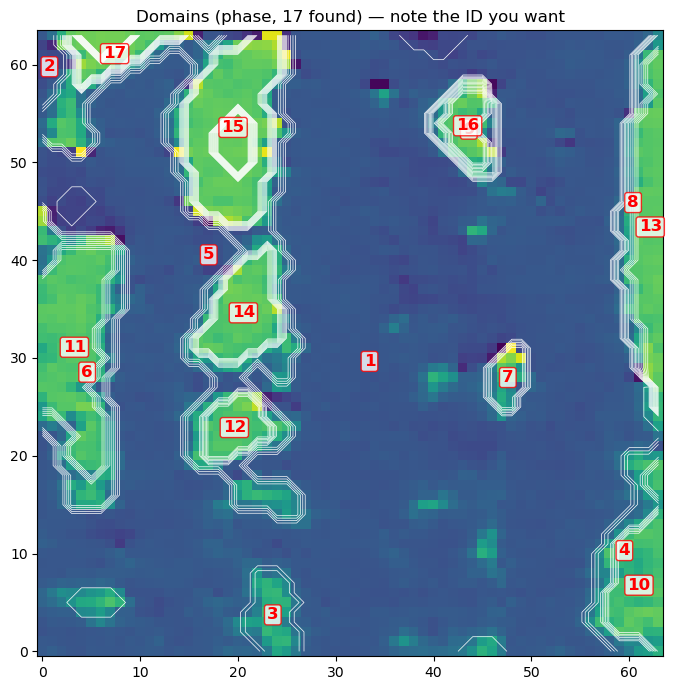

id :  area(px)   centroid(row,col)
  1:     2924   (30, 33)
  5:      239   (41, 17)
 11:      132   (31, 3)
 15:      124   (54, 20)
 13:       91   (43, 62)
  6:       80   (29, 5)
 14:       65   (35, 21)
 10:       64   (7, 61)
  4:       49   (10, 60)
  8:       45   (46, 60)
  3:       41   (4, 24)
 12:       35   (23, 20)
 16:       27   (54, 43)
 17:       26   (61, 7)
  9:       25   (53, 44)
  7:       22   (28, 48)
  2:       18   (60, 1)


In [136]:
labels, info = show_domains(img.data[4], channel="phase", n_levels=3)   # see numbered domains

Domain id(s)=[1]: total area=2571 px; wrote 94 lines at 60.0 deg, spacing 0.04 um; V_fwd=0, V_back=6.


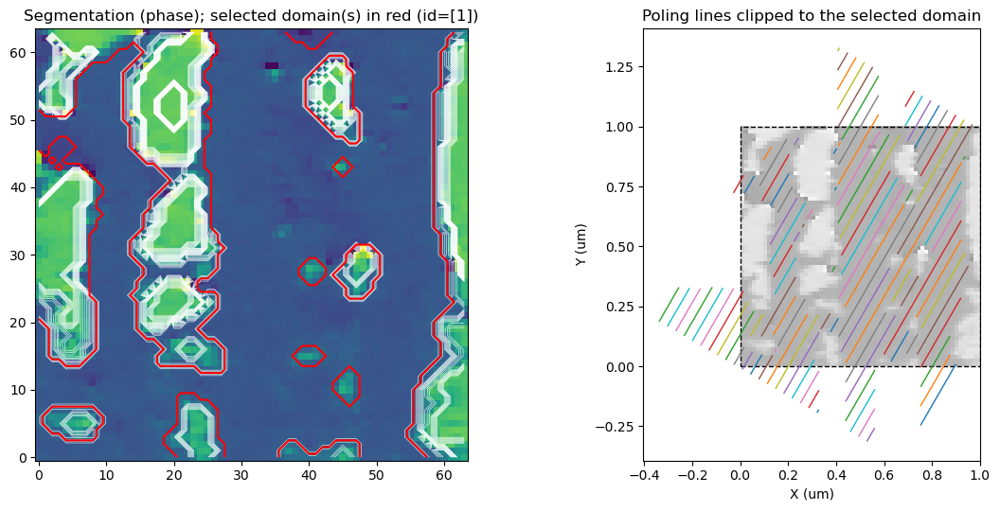

In [137]:
# from gen_domain_fix_traces import gen_domain_fix_traces
# from domain_fix_usage import show_domains



tb, labels, chosen = gen_domain_fix_traces(
    img.data[4], field_um=1, center_um=(0.5, 0.5), step_um=0.01,
    channel="phase", n_levels=5,
    select_id=[1],                 # <- the id you read off
    angle_deg=60.0, line_spacing_um=0.04,
    v_forward=0, v_backward=6,
    interactive=False, plot=True, flip_y=False,
)

Wrote 9583 pts to 'output\rose_flower_N64_4um.txt'  (path length 90.6 um, 188 strokes)


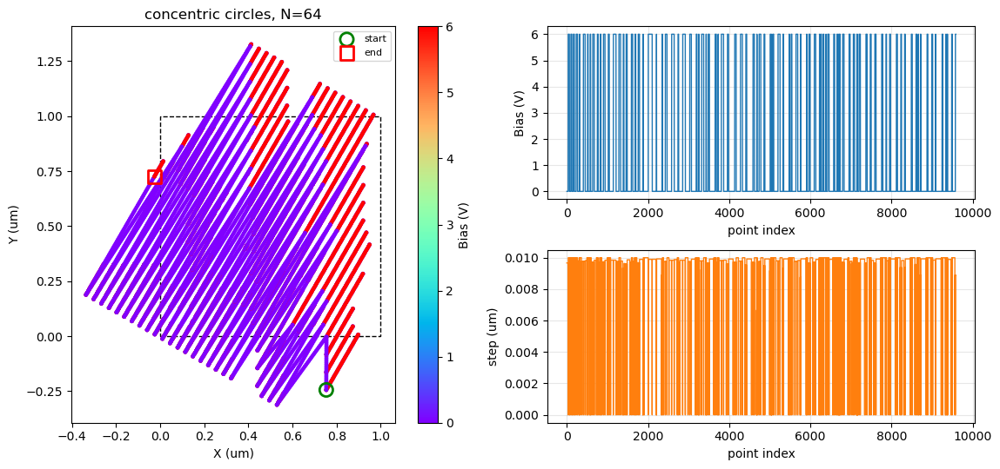

In [138]:
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")

tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=1.0, title="concentric circles, N=64")

In [139]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [140]:
ae.write_spm(commands='TL_RunPy(0.2, 0, 0, 0)')      # live scan center, 0.5 um/s

In [141]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Super-domain directional selection

In [81]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import ndimage as ndi

# # reuse the segmentation + geometry from the earlier domain-writing tool
# # from gen_domain_fix_traces import (segment_pfm_map, _px_to_um,
# #                                    _lines_clipped_to_mask, _nearest_label)
# try:
#     from skimage.measure import regionprops
#     _HAVE_SKIMAGE = True
# except Exception:
#     _HAVE_SKIMAGE = False


# def _domain_orientation(mask):
#     """Elongation angle (deg, 0..180) of a single domain mask, plus how elongated it
#     is (eccentricity 0..1). Uses the second-moment (inertia) tensor of the region:
#     the major-axis orientation is the 'band direction'. Angle is measured CCW from the
#     +x (column) axis, in image coordinates (row increases downward).
#     """
#     rr, cc = np.nonzero(mask)
#     if len(rr) < 3:
#         return None, 0.0
#     r0 = rr - rr.mean()
#     c0 = cc - cc.mean()
#     # covariance of pixel coords (x=col, y=row); note image row grows downward
#     Sxx = np.mean(c0 * c0)
#     Syy = np.mean(r0 * r0)
#     Sxy = np.mean(c0 * r0)
#     # principal axis angle of the covariance (major axis)
#     theta = 0.5 * np.arctan2(2 * Sxy, (Sxx - Syy))     # radians, CCW from +x
#     ang = np.rad2deg(theta) % 180.0                     # fold to [0,180)
#     # eccentricity from eigenvalues
#     tr = Sxx + Syy
#     det = Sxx * Syy - Sxy * Sxy
#     disc = max(0.0, (tr / 2) ** 2 - det)
#     l1 = tr / 2 + np.sqrt(disc)
#     l2 = tr / 2 - np.sqrt(disc)
#     ecc = 0.0 if l1 <= 0 else np.sqrt(max(0.0, 1.0 - l2 / l1))
#     return ang, ecc


# def segment_by_direction(img, channel="phase", n_levels=2, n_dir_groups=3,
#                          dir_offset_deg=0.0, min_ecc=0.0,
#                          smooth_px=1.0, min_size_px=20, close_px=1):
#     """Segment a PFM map into domains, measure each domain's band ORIENTATION
#     (elongation angle), and GROUP the domains by that direction.

#     img          : 2D PFM amplitude or phase map.
#     channel      : "phase" or "amplitude" (passed to segment_pfm_map).
#     n_levels     : phase bands for channel="phase".
#     n_dir_groups : number of direction groups to bin the 0..180 deg angle range into
#                    (e.g. 3 for PZTO's three 120-deg-separated in-plane variants -> but
#                    note band angles fold into 180 deg, so 3 groups = 60-deg bins).
#     dir_offset_deg: rotates the group bin boundaries (align bins to your easy axes).
#     min_ecc      : drop near-round domains (eccentricity < min_ecc) whose orientation
#                    is ill-defined; 0 keeps everything.
#     smooth_px/min_size_px/close_px : segmentation knobs (see segment_pfm_map).

#     Returns
#     -------
#     labels  : 2D int label image (0 = background, 1..N = domains).
#     dinfo   : dict with, per domain id:
#                 'angle'  {id: deg},  'ecc' {id: 0..1},  'group' {id: 0..n_dir_groups-1},
#                 'areas'  {id: px},   'centroids' {id: (row,col)},
#                 'group_ids' {g: [ids...]},  'group_center_deg' {g: bin center deg},
#                 'channel', 'n_dir_groups', 'dir_offset_deg'.
#     """
#     labels, info = segment_pfm_map(img, channel=channel, n_levels=n_levels,
#                                    smooth_px=smooth_px, min_size_px=min_size_px,
#                                    close_px=close_px)
#     n_dir_groups = max(1, int(n_dir_groups))
#     bin_width = 180.0 / n_dir_groups

#     angle, ecc, group = {}, {}, {}
#     group_ids = {g: [] for g in range(n_dir_groups)}
#     for rid in list(info["areas"].keys()):
#         ang, e = _domain_orientation(labels == rid)
#         if ang is None or e < min_ecc:
#             # orientation undefined / too round -> exclude from groups (leave labeled)
#             continue
#         angle[rid] = ang
#         ecc[rid] = e
#         # assign to a direction bin (fold by 180, offset, wrap)
#         a = (ang - dir_offset_deg) % 180.0
#         g = int(a // bin_width) % n_dir_groups
#         group[rid] = g
#         group_ids[g].append(rid)

#     group_center = {g: (dir_offset_deg + (g + 0.5) * bin_width) % 180.0
#                     for g in range(n_dir_groups)}

#     dinfo = {"angle": angle, "ecc": ecc, "group": group,
#              "areas": info["areas"], "centroids": info["centroids"],
#              "group_ids": group_ids, "group_center_deg": group_center,
#              "channel": channel, "n_dir_groups": n_dir_groups,
#              "dir_offset_deg": dir_offset_deg}
#     return labels, dinfo


# def show_direction_groups(img, channel="phase", n_levels=2, n_dir_groups=3,
#                           dir_offset_deg=0.0, min_ecc=0.0, smooth_px=1.0,
#                           min_size_px=20, close_px=1, figsize=(13, 6)):
#     """Segment + group by direction and DISPLAY: (left) domains colored by direction
#     group with a short line showing each domain's band angle; (right) a legend/table.
#     Read off the GROUP index you want, then pass it as select_group to
#     gen_superdomain_direction_traces.

#     Returns (labels, dinfo).
#     """
#     labels, dinfo = segment_by_direction(img, channel=channel, n_levels=n_levels,
#                                           n_dir_groups=n_dir_groups,
#                                           dir_offset_deg=dir_offset_deg,
#                                           min_ecc=min_ecc, smooth_px=smooth_px,
#                                           min_size_px=min_size_px, close_px=close_px)
#     # build a group-colored image
#     gimg = np.full(labels.shape, np.nan)
#     for rid, g in dinfo["group"].items():
#         gimg[labels == rid] = g

#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
#                                    gridspec_kw={"width_ratios": [3, 1]})
#     ax1.imshow(img,  cmap="gray", alpha=0.5)
#     im = ax1.imshow(gimg, origin='lower', cmap="hsv", alpha=0.65,
#                     vmin=0, vmax=max(1, dinfo["n_dir_groups"] - 1))
#     # draw each domain's orientation as a short line at its centroid
#     for rid, ang in dinfo["angle"].items():
#         r, c = dinfo["centroids"][rid]
#         L = 6.0
#         dx = L * np.cos(np.deg2rad(ang)); dy = L * np.sin(np.deg2rad(ang))
#         ax1.plot([c - dx, c + dx], [r - dy, r + dy], "k-", lw=1.2)
#         ax1.text(c, r, str(dinfo["group"][rid]), color="white", fontsize=8,
#                  ha="center", va="center", fontweight="bold")
#     ax1.set_title(f"Domains colored by DIRECTION group (number = group id)")

#     # legend table on the right
#     ax2.axis("off")
#     lines = ["group : band angle (deg) : #domains : total area(px)"]
#     for g in range(dinfo["n_dir_groups"]):
#         ids = dinfo["group_ids"][g]
#         area = sum(dinfo["areas"][i] for i in ids)
#         lines.append(f"  {g}   :   ~{dinfo['group_center_deg'][g]:.0f}"
#                      f"         :   {len(ids):>3}     :  {area}")
#     ax2.text(0.0, 1.0, "\n".join(lines), va="top", family="monospace", fontsize=10)
#     plt.tight_layout(); plt.show()

#     print("\n".join(lines))
#     return labels, dinfo


# def gen_superdomain_direction_traces(img, field_um=2.0, center_um=(1.0, 1.0),
#                                      step_um=0.01, channel="phase", n_levels=2,
#                                      n_dir_groups=3, dir_offset_deg=0.0, min_ecc=0.15,
#                                      select_group=None, select_ids=None,
#                                      angle_deg=None, along_band=True,
#                                      line_spacing_um=0.05, v_forward=0.0,
#                                      v_backward=-5.5, margin_um=0.0, pts_per_um=None,
#                                      tb=None, smooth_px=1.0, min_size_px=20, close_px=1,
#                                      plot=True, flip_y=False):
#     """Segment a PFM map by super-domain DIRECTION, pick a direction group, and write
#     angled poling traces across all domains in that group.

#     Selection:
#       select_group : the direction-group index (from show_direction_groups) to write.
#                      All domains whose band orientation falls in that group are poled.
#       select_ids   : (optional) explicit list of domain ids to write instead of a group.

#     Trace geometry:
#       angle_deg    : orientation of the poling lines. If None (default), it is chosen
#                      automatically from the group's band direction:
#                        along_band=True  -> lines run ALONG the band (group angle),
#                        along_band=False -> lines run ACROSS the band (group angle+90).
#       along_band   : see angle_deg.
#       line_spacing_um, v_forward, v_backward, margin_um, pts_per_um : as in
#                      gen_domain_fix_traces (forward pass v_forward, backward pass
#                      v_backward; lines clipped to the selected domains' union).

#     All other args mirror gen_domain_fix_traces / segment_by_direction.

#     Returns (tb, labels, dinfo, chosen_ids).
#     """
#     tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
#     img = np.asarray(img, float)
#     rows, cols = img.shape

#     labels, dinfo = segment_by_direction(img, channel=channel, n_levels=n_levels,
#                                           n_dir_groups=n_dir_groups,
#                                           dir_offset_deg=dir_offset_deg,
#                                           min_ecc=min_ecc, smooth_px=smooth_px,
#                                           min_size_px=min_size_px, close_px=close_px)
#     if labels.max() == 0:
#         raise RuntimeError("Segmentation found no domains; adjust channel/thresholds.")

#     # choose which domains to write
#     if select_ids is not None:
#         chosen_ids = [int(i) for i in np.atleast_1d(select_ids)]
#         grp_angle = np.mean([dinfo["angle"][i] for i in chosen_ids
#                              if i in dinfo["angle"]]) if chosen_ids else 0.0
#     else:
#         if select_group is None:
#             # default: the group with the largest total area
#             areas_by_group = {g: sum(dinfo["areas"][i] for i in ids)
#                               for g, ids in dinfo["group_ids"].items()}
#             select_group = max(areas_by_group, key=areas_by_group.get)
#             print(f"No select_group given; defaulting to largest-area group "
#                   f"{select_group}.")
#         if select_group not in dinfo["group_ids"]:
#             raise ValueError(f"group {select_group} invalid; "
#                              f"choose 0..{dinfo['n_dir_groups']-1}")
#         chosen_ids = list(dinfo["group_ids"][select_group])
#         grp_angle = dinfo["group_center_deg"][select_group]
#         if not chosen_ids:
#             raise RuntimeError(f"Direction group {select_group} contains no domains.")

#     # decide the poling-line angle
#     if angle_deg is None:
#         angle_deg = grp_angle if along_band else (grp_angle + 90.0) % 180.0

#     # union mask of the chosen domains, optional margin
#     mask = np.isin(labels, chosen_ids)
#     if margin_um and margin_um != 0:
#         px = max(1, int(round(abs(margin_um) / (field_um / cols))))
#         mask = (ndi.binary_dilation(mask, iterations=px) if margin_um > 0
#                 else ndi.binary_erosion(mask, iterations=px))

#     # generate clipped lines and stroke them (forward @ v_forward, backward @ v_backward)
#     seg_list = _lines_clipped_to_mask(mask, field_um, center_um, angle_deg,
#                                       line_spacing_um, step_um, pts_per_um,
#                                       flip_y=flip_y)
#     n_written = 0
#     for pts in seg_list:
#         if len(pts) < 2:
#             continue
#         tb.stroke(pts, np.full(len(pts), v_forward, float))
#         tb.stroke(pts[::-1], np.full(len(pts), v_backward, float))
#         n_written += 1

#     total_area = sum(dinfo["areas"][i] for i in chosen_ids)
#     print(f"Direction group {select_group if select_ids is None else '(ids)'}: "
#           f"{len(chosen_ids)} domains, band ~{grp_angle:.0f} deg, area {total_area} px; "
#           f"wrote {n_written} lines at {angle_deg:.0f} deg "
#           f"({'along' if along_band else 'across'} band); "
#           f"V_fwd={v_forward}, V_back={v_backward}.")

#     if plot:
#         _plot_direction_result(img, labels, dinfo, chosen_ids, seg_list,
#                                field_um, center_um, angle_deg, flip_y)

#     return tb, labels, dinfo, chosen_ids


# def _plot_direction_result(img, labels, dinfo, chosen_ids, seg_list, field_um,
#                            center_um, angle_deg, flip_y):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
#     ax1.imshow(img, origin='lower', cmap="viridis")
#     sel = np.isin(labels, chosen_ids)
#     ax1.contour(labels, levels=np.arange(0.5, labels.max() + 1),
#                 colors="w", linewidths=0.3)
#     ax1.contour(sel, levels=[0.5], colors="r", linewidths=1.5)
#     for rid in chosen_ids:
#         if rid in dinfo["angle"]:
#             r, c = dinfo["centroids"][rid]
#             ang = dinfo["angle"][rid]; L = 6
#             ax1.plot([c - L*np.cos(np.deg2rad(ang)), c + L*np.cos(np.deg2rad(ang))],
#                      [r - L*np.sin(np.deg2rad(ang)), r + L*np.sin(np.deg2rad(ang))],
#                      "k-", lw=1)
#     ax1.set_title("Selected direction group (red); black ticks = band angle")

#     cx, cy = center_um
#     ext = [cx - field_um/2, cx + field_um/2, cy - field_um/2, cy + field_um/2]
#     ax2.imshow(img, origin='lower', cmap="gray", extent=ext, alpha=0.4)
#     for pts in seg_list:
#         ax2.plot(pts[:, 0], pts[:, 1], "-", lw=1.0)
#     ax2.set_aspect("equal")
#     if not flip_y:
#         ax2.invert_yaxis()
#     ax2.add_patch(plt.Rectangle((cx-field_um/2, cy-field_um/2), field_um, field_um,
#                                 fill=False, ls="--", ec="k"))
#     ax2.set_xlabel("X (um)"); ax2.set_ylabel("Y (um)")
#     ax2.set_title(f"Poling lines at {angle_deg:.0f} deg, clipped to the group")
#     plt.tight_layout(); plt.show()

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# reuse the geometry helpers from the earlier domain-writing tool
# from gen_domain_fix_traces import _px_to_um, _lines_clipped_to_mask, _nearest_label
try:
    from skimage.measure import label as cc_label
    _HAVE_SKIMAGE = True
except Exception:
    _HAVE_SKIMAGE = False


# ---------------------------------------------------------------------------
#  DENSE per-pixel orientation (structure tensor) -> partition the WHOLE image
# ---------------------------------------------------------------------------
def orientation_field(img, grad_smooth_px=1.0, tensor_smooth_px=4.0):
    """Per-pixel local band ORIENTATION (deg, 0..180) via the structure tensor.

    Unlike per-domain elongation, this assigns a direction to EVERY pixel -- including
    the regions BETWEEN detected stripes -- so the whole image can be partitioned by
    direction with no gaps.

    img             : 2D map (amplitude or phase).
    grad_smooth_px  : Gaussian smoothing before taking gradients (noise control).
    tensor_smooth_px: Gaussian smoothing of the tensor components (sets the spatial
                      scale over which orientation is averaged -- larger = smoother,
                      more super-domain-scale; smaller = more local).

    Returns
    -------
    theta_deg  : 2D array, local orientation in [0,180) deg (CCW from +x/col axis).
    coherence  : 2D array in [0,1], how strongly oriented each pixel is (low in
                 isotropic/flat regions).
    """
    a = np.asarray(img, float)
    if np.any(~np.isfinite(a)):
        a = np.where(np.isfinite(a), a, np.nanmedian(a))
    if grad_smooth_px and grad_smooth_px > 0:
        a = ndi.gaussian_filter(a, grad_smooth_px)

    # gradients (gy along rows/y, gx along cols/x)
    gy, gx = np.gradient(a)
    # structure-tensor components, smoothed over the tensor scale
    Jxx = ndi.gaussian_filter(gx * gx, tensor_smooth_px)
    Jyy = ndi.gaussian_filter(gy * gy, tensor_smooth_px)
    Jxy = ndi.gaussian_filter(gx * gy, tensor_smooth_px)

    # the band direction is PERPENDICULAR to the dominant gradient. The gradient
    # orientation is 0.5*atan2(2 Jxy, Jxx - Jyy); add 90 deg for the band direction.
    grad_ang = 0.5 * np.arctan2(2 * Jxy, (Jxx - Jyy))     # radians
    band_ang = grad_ang + np.pi / 2.0
    theta_deg = (np.rad2deg(band_ang)) % 180.0

    # coherence = (l1-l2)/(l1+l2) from tensor eigenvalues
    tr = Jxx + Jyy
    diff = np.sqrt((Jxx - Jyy) ** 2 + 4 * Jxy ** 2)
    with np.errstate(divide="ignore", invalid="ignore"):
        coherence = np.where(tr > 0, diff / tr, 0.0)
    coherence = np.clip(np.nan_to_num(coherence), 0.0, 1.0)
    return theta_deg, coherence


def partition_by_direction(img, n_dir_groups=3, dir_offset_deg=0.0,
                           grad_smooth_px=1.0, tensor_smooth_px=4.0,
                           min_coherence=0.0, clean_px=2, fill_gaps=True):
    """Partition the WHOLE image into direction regions.

    Every pixel is assigned to one of n_dir_groups direction bins (over 0..180 deg)
    from its structure-tensor orientation.  Regions between stripes are included, so
    there are no gaps.  Optionally, low-coherence pixels are filled from their
    neighbours so the whole field is covered.

    Returns
    -------
    group_map : 2D int array, each pixel's direction-group index (0..n_dir_groups-1).
    dinfo     : dict with 'theta_deg', 'coherence', 'group_center_deg' {g: deg},
                'group_area' {g: px}, 'n_dir_groups', 'dir_offset_deg'.
    """
    theta_deg, coherence = orientation_field(img, grad_smooth_px, tensor_smooth_px)
    n_dir_groups = max(1, int(n_dir_groups))
    bin_width = 180.0 / n_dir_groups

    a = (theta_deg - dir_offset_deg) % 180.0
    group_map = (a // bin_width).astype(int) % n_dir_groups

    # low-coherence pixels have unreliable orientation; fill them from nearest
    # confident neighbour so the whole field still gets a direction (no gaps).
    if fill_gaps and min_coherence > 0:
        weak = coherence < min_coherence
        if weak.any() and (~weak).any():
            # nearest-confident-pixel assignment via distance transform indices
            idx = ndi.distance_transform_edt(weak, return_distances=False,
                                             return_indices=True)
            group_map = group_map[tuple(idx)]

    # smooth the label map (majority filter) to remove speckle
    if clean_px and clean_px > 0:
        gm = group_map.copy()
        for _ in range(int(clean_px)):
            gm = ndi.median_filter(gm, size=3)
        group_map = gm

    group_center = {g: (dir_offset_deg + (g + 0.5) * bin_width) % 180.0
                    for g in range(n_dir_groups)}
    group_area = {g: int(np.count_nonzero(group_map == g)) for g in range(n_dir_groups)}

    dinfo = {"theta_deg": theta_deg, "coherence": coherence,
             "group_center_deg": group_center, "group_area": group_area,
             "n_dir_groups": n_dir_groups, "dir_offset_deg": dir_offset_deg}
    return group_map, dinfo


def show_direction_groups(img, n_dir_groups=3, dir_offset_deg=0.0,
                          grad_smooth_px=1.0, tensor_smooth_px=4.0,
                          min_coherence=0.0, clean_px=2, figsize=(13, 6)):
    """Partition the whole image by direction and DISPLAY it: (left) every pixel
    colored by its direction group with orientation ticks on a grid; (right) a table.
    Read off the GROUP index you want and pass it as select_group.

    Returns (group_map, dinfo).
    """
    group_map, dinfo = partition_by_direction(
        img, n_dir_groups=n_dir_groups, dir_offset_deg=dir_offset_deg,
        grad_smooth_px=grad_smooth_px, tensor_smooth_px=tensor_smooth_px,
        min_coherence=min_coherence, clean_px=clean_px)
    rows, cols = group_map.shape

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
                                   gridspec_kw={"width_ratios": [3, 1]})
    ax1.imshow(img, origin='lower', cmap="gray", alpha=0.5)
    ax1.imshow(group_map, origin='lower', cmap="hsv", alpha=0.55,
               vmin=0, vmax=max(1, dinfo["n_dir_groups"] - 1))
    # orientation ticks on a coarse grid (show the local band angle everywhere)
    step = max(1, min(rows, cols) // 16)
    th = dinfo["theta_deg"]
    for r in range(step // 2, rows, step):
        for c in range(step // 2, cols, step):
            ang = th[r, c]; L = step * 0.4
            dx = L * np.cos(np.deg2rad(ang)); dy = L * np.sin(np.deg2rad(ang))
            ax1.plot([c - dx, c + dx], [r - dy, r + dy], "k-", lw=0.8, alpha=0.7)
    ax1.set_title("WHOLE-image partition by direction (color = group)")

    ax2.axis("off")
    lines = ["group : band angle (deg) : area(px) : % of field"]
    tot = rows * cols
    for g in range(dinfo["n_dir_groups"]):
        area = dinfo["group_area"][g]
        lines.append(f"  {g}   :   ~{dinfo['group_center_deg'][g]:.0f}"
                     f"        :  {area:>6} : {100*area/tot:5.1f}%")
    ax2.text(0.0, 1.0, "\n".join(lines), va="top", family="monospace", fontsize=10)
    plt.tight_layout(); plt.show()

    print("\n".join(lines))
    return group_map, dinfo


def _route_segments(seg_list, optimize=True, two_opt_passes=3):
    """Order a list of line segments so the tip travels the SHORTEST total distance
    between them, choosing for each segment which endpoint to enter from.

    Each segment is an (M,2) array of points. The 'travel' cost is the gap between the
    exit point of one segment and the entry point of the next (the along-segment path
    is fixed). We greedily build a nearest-neighbour route (with endpoint flipping),
    then improve it with a few 2-opt passes. Returns the reordered/flipped seg_list.
    """
    segs = [s for s in seg_list if len(s) >= 2]
    n = len(segs)
    if n <= 1:
        return segs

    ends = np.array([[s[0], s[-1]] for s in segs])   # (n,2,2): [seg][end0/end1][xy]

    # --- greedy nearest-neighbour with endpoint choice ---
    unused = set(range(n))
    start = 0
    cur = start
    # start each segment from its point-0 end by default
    flip = {start: False}
    order = [start]
    unused.discard(start)
    cur_exit = ends[start, 1]     # exit = the far end of the first segment
    while unused:
        best, best_flip, best_d = None, False, np.inf
        for j in unused:
            d0 = np.hypot(*(ends[j, 0] - cur_exit))   # enter j at end0
            d1 = np.hypot(*(ends[j, 1] - cur_exit))   # enter j at end1 (flip)
            if d0 < best_d:
                best, best_flip, best_d = j, False, d0
            if d1 < best_d:
                best, best_flip, best_d = j, True, d1
        order.append(best)
        flip[best] = best_flip
        # exit point of j is the opposite end from where we entered
        cur_exit = ends[best, 0] if best_flip else ends[best, 1]
        unused.discard(best)

    # build oriented point-lists for the greedy route
    routed = []
    for idx in order:
        s = segs[idx]
        routed.append(s[::-1] if flip.get(idx, False) else s)

    if not optimize or n < 4:
        return routed

    # --- 2-opt improvement on the travel (gap) distances ---
    def gap(a, b):     # distance from exit of a to entry of b
        return np.hypot(*(a[-1] - b[0]))

    def total_travel(route):
        return sum(gap(route[i], route[i + 1]) for i in range(len(route) - 1))

    best_route = routed
    best_cost = total_travel(best_route)
    for _ in range(int(two_opt_passes)):
        improved = False
        for i in range(len(best_route) - 1):
            for k in range(i + 1, len(best_route)):
                # reverse the sub-route [i..k] (and flip those segments' direction)
                new_route = (best_route[:i]
                             + [seg[::-1] for seg in best_route[i:k + 1][::-1]]
                             + best_route[k + 1:])
                c = total_travel(new_route)
                if c + 1e-15 < best_cost:
                    best_route, best_cost = new_route, c
                    improved = True
        if not improved:
            break
    return best_route


def gen_superdomain_direction_traces(img, field_um=2.0, center_um=(1.0, 1.0),
                                     step_um=0.01, n_dir_groups=3, dir_offset_deg=0.0,
                                     select_group=None,
                                     angle_deg=None, scan_angle_deg=None, along_band=True,
                                     line_spacing_um=0.05, v_forward=0.0,
                                     v_backward=-5.5, margin_um=0.0, pts_per_um=None,
                                     tb=None, grad_smooth_px=1.0, tensor_smooth_px=4.0,
                                     min_coherence=0.0, clean_px=2,
                                     optimize_route=True,
                                     plot=True, flip_y=False):
    """Partition the WHOLE image by super-domain DIRECTION, pick a direction group,
    and write angled poling traces across that ENTIRE region (including the areas
    between the detected stripes -- every pixel belongs to a direction group).

    Selection:
      select_group : direction-group index (from show_direction_groups) to write.
                     ALL pixels in that direction region are covered by traces.

    Trace geometry:
      scan_angle_deg : orientation (deg) of the generated poling lines -- i.e. the
                       SCAN ANGLE of the traces. If given, it OVERRIDES the automatic
                       choice. (Alias: angle_deg, kept for backward compatibility.)
      angle_deg      : backward-compatible alias for scan_angle_deg.
      along_band     : used only when neither scan_angle_deg nor angle_deg is given:
                       True  -> lines run ALONG the group's band direction,
                       False -> lines run ACROSS it (band + 90 deg).
      line_spacing_um, v_forward, v_backward, margin_um, pts_per_um : as before
                       (forward pass v_forward, backward pass v_backward; lines clipped
                       to the selected direction region).

    Returns (tb, group_map, dinfo, select_group).
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    img = np.asarray(img, float)
    rows, cols = img.shape

    group_map, dinfo = partition_by_direction(
        img, n_dir_groups=n_dir_groups, dir_offset_deg=dir_offset_deg,
        grad_smooth_px=grad_smooth_px, tensor_smooth_px=tensor_smooth_px,
        min_coherence=min_coherence, clean_px=clean_px)

    # pick the direction group
    if select_group is None:
        select_group = max(dinfo["group_area"], key=dinfo["group_area"].get)
        print(f"No select_group given; defaulting to largest-area group "
              f"{select_group}.")
    if select_group not in dinfo["group_center_deg"]:
        raise ValueError(f"group {select_group} invalid; "
                         f"choose 0..{dinfo['n_dir_groups']-1}")
    grp_angle = dinfo["group_center_deg"][select_group]

    # decide the SCAN ANGLE of the traces
    # priority: scan_angle_deg > angle_deg (alias) > derived from band direction
    scan_ang = scan_angle_deg if scan_angle_deg is not None else angle_deg
    if scan_ang is None:
        scan_ang = grp_angle if along_band else (grp_angle + 90.0) % 180.0

    # WHOLE-region mask for this direction group (fills the gaps between stripes)
    mask = (group_map == select_group)
    if margin_um and margin_um != 0:
        px = max(1, int(round(abs(margin_um) / (field_um / cols))))
        mask = (ndi.binary_dilation(mask, iterations=px) if margin_um > 0
                else ndi.binary_erosion(mask, iterations=px))

    seg_list = _lines_clipped_to_mask(mask, field_um, center_um, scan_ang,
                                      line_spacing_um, step_um, pts_per_um,
                                      flip_y=flip_y)
    # order the segments so the tip travels the shortest distance between them
    # (nearest-neighbour + 2-opt, with per-segment endpoint flipping).
    if optimize_route:
        seg_list = _route_segments(seg_list, optimize=True)

    n_written = 0
    for pts in seg_list:
        if len(pts) < 2:
            continue
        tb.stroke(pts, np.full(len(pts), v_forward, float))
        tb.stroke(pts[::-1], np.full(len(pts), v_backward, float))
        n_written += 1

    area = dinfo["group_area"][select_group]
    print(f"Direction group {select_group}: band ~{grp_angle:.0f} deg, "
          f"region area {area} px ({100*area/(rows*cols):.1f}% of field); "
          f"wrote {n_written} lines at scan angle {scan_ang:.0f} deg; "
          f"V_fwd={v_forward}, V_back={v_backward}.")

    if plot:
        _plot_direction_result(img, group_map, dinfo, select_group, seg_list,
                               field_um, center_um, scan_ang, flip_y)

    return tb, group_map, dinfo, select_group


def _plot_direction_result(img, group_map, dinfo, select_group, seg_list, field_um,
                           center_um, scan_ang, flip_y):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
    ax1.imshow(img, origin='lower', cmap="viridis")
    sel = (group_map == select_group)
    ax1.contour(sel, levels=[0.5], colors="r", linewidths=1.5, origin='lower')
    ax1.set_title(f"Selected direction region (red), group {select_group} "
                  f"(~{dinfo['group_center_deg'][select_group]:.0f} deg)")

    cx, cy = center_um
    ext = [cx - field_um/2, cx + field_um/2, cy - field_um/2, cy + field_um/2]
    ax2.imshow(img, origin='lower', cmap="gray", extent=ext, alpha=0.4)
    for pts in seg_list:
        ax2.plot(pts[:, 0], pts[:, 1], "-", lw=1.0)
    ax2.set_aspect("equal")
    if not flip_y:
        ax2.invert_yaxis()
    ax2.add_patch(plt.Rectangle((cx-field_um/2, cy-field_um/2), field_um, field_um,
                                fill=False, ls="--", ec="k"))
    ax2.set_xlabel("X (um)"); ax2.set_ylabel("Y (um)")
    ax2.set_title(f"Poling lines at scan angle {scan_ang:.0f} deg, clipped to region")
    plt.tight_layout(); plt.show()

In [74]:
# img = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260709\PZTO\PZTO_VDART_0001.ibw")
img = exp.load_ibw()

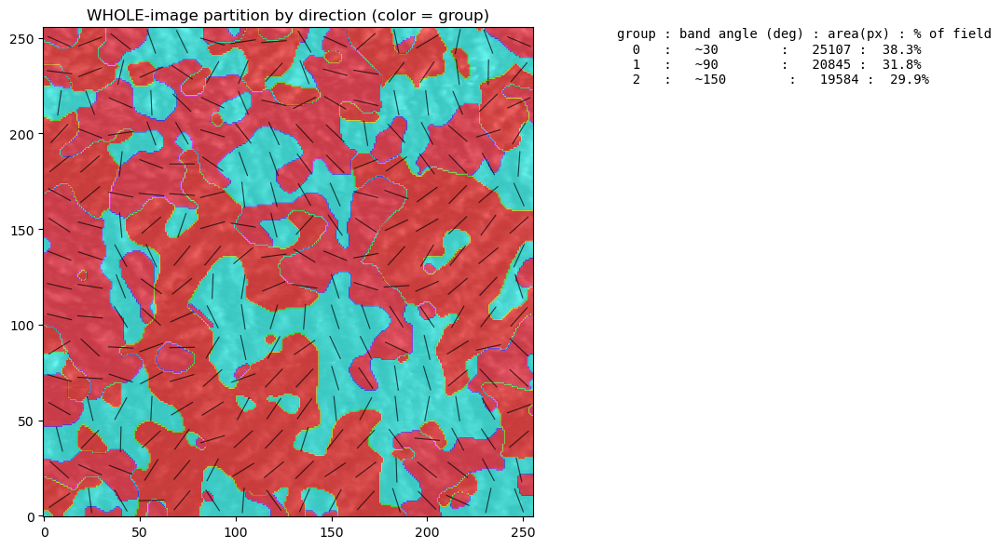

group : band angle (deg) : area(px) : % of field
  0   :   ~30        :   25107 :  38.3%
  1   :   ~90        :   20845 :  31.8%
  2   :   ~150        :   19584 :  29.9%


In [107]:
# from gen_superdomain_direction_traces import show_direction_groups, gen_superdomain_direction_traces

# 1) see the direction groups, read off the one you want
# labels, dinfo = show_direction_groups(img.data[2], channel="phase", n_levels=2, n_dir_groups=3)

group_map, dinfo = show_direction_groups(img.data[1],  n_dir_groups=3, tensor_smooth_px=5)


In [108]:
# # 2) write across that group
# tb, labels, dinfo, chosen = gen_superdomain_direction_traces(
#     img.data[1], field_um=5.0, center_um=(2.5,2.5), step_um=0.025,
#     channel="amplitude", n_levels=2, n_dir_groups=3,
#     select_group=1,                 # the direction group id
#     along_band=False,               # lines across the bands (or True = along)
#     line_spacing_um=0.04, v_forward=-8, v_backward=0,
#     plot=True, flip_y=False,
# )

# write traces across that entire direction region at a chosen scan angle
tb, group_map, dinfo, g = gen_superdomain_direction_traces(
    img.data[1], field_um=5.0, center_um=(2.5,2.5), step_um=0.04,
    n_dir_groups=3, select_group=0,
    scan_angle_deg=50.0,              # <- explicit scan angle of the traces
    line_spacing_um=0.04, v_forward=0, v_backward=-8,
    plot=True, flip_y=True,
)

KeyboardInterrupt: 

In [103]:
# Load patterns into the software
fname = os.path.join(CONFIG["work_dir"], "lines.txt")
tb.save(fname)

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

Wrote 65719 pts to 'output\lines.txt'  (path length 2383.8 um, 2102 strokes)
TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\lines.txt")


In [109]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

# Sectors from the center

In [40]:
import numpy as np


def gen_ray_sector_scan(n_sectors=6, rays_per_sector=1, radius_um=0.8,
                        center_um=(1.0, 1.0), V_forw=5.5, V_back=5.5,
                        start_angle_deg=0.0, field_um=2.0, step_um=0.01, tb=None,
                        pts_per_ray=400, flip_sign=False,
                        both_directions_signed=True, sector_fill=0.9):
    """Ray-from-center poling pattern with per-sector alternating sign and
    multiple rays per sector.

    The circle is divided into n_sectors equal angular SECTORS over the full 360 deg.
    Within EACH sector, rays_per_sector rays are written (fanned across the sector's
    angular width).  For every ray:
      * the probe STARTS at the OUTER edge and moves INWARD to the center, applying a
        DC voltage of amplitude V_forw;
      * upon reaching the center it moves BACK OUT to the edge, applying amplitude
        V_back.
    The SIGN of the applied voltage is set by the SECTOR (all rays in a sector share
    it) and ALTERNATES from one sector to the next (+ , - , + , - , ...).  Amplitude
    is V_forw (inward) and V_back (outward); the sector sign multiplies that amplitude.

    n_sectors            : number of equal sectors over 360 deg
    rays_per_sector      : number of rays written within each sector
    radius_um            : ray length (outer edge radius)
    center_um            : (cx, cy) center of the pattern
    V_forw               : voltage AMPLITUDE on the inward pass (edge -> center)
    V_back               : voltage AMPLITUDE on the outward pass (center -> edge)
    start_angle_deg      : rotates the whole pattern / first sector boundary
    pts_per_ray          : samples along one ray traversal (one direction)
    flip_sign            : if True, invert the whole sign sequence (start with -)
    both_directions_signed : True  -> both inward and outward passes use the sector
                                      sign (inward = sign*V_forw, outward = sign*V_back)
                             False -> only the inward pass is signed; the outward
                                      pass uses +V_back (fixed "reset" polarity)
    sector_fill          : fraction (0..1] of the sector width that the rays span.
                           1.0 -> rays reach the sector edges; <1 -> rays packed toward
                           the sector center, leaving a gap at the boundaries.
                           Ignored when rays_per_sector == 1 (single centered ray).

    Sign convention: sector k (k = 0,1,...) gets sign (+1 if k even else -1), inverted
    when flip_sign=True.  With n_sectors odd, a strict +/-/+/- sequence cannot close
    perfectly (the wrap-around adjacent sectors share a sign).
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R = radius_um

    n_sectors = max(1, int(n_sectors))
    rays_per_sector = max(1, int(rays_per_sector))
    sector_width = 2.0 * np.pi / n_sectors
    start_rad = np.deg2rad(start_angle_deg)
    fill = float(np.clip(sector_fill, 1e-6, 1.0))

    for k in range(n_sectors):
        sector_center = start_rad + (k + 0.5) * sector_width

        # sector sign, alternating +,-,+,-...
        sign = (+1.0 if (k % 2 == 0) else -1.0)
        if flip_sign:
            sign = -sign

        # ray angles within this sector, fanned across (fill * sector_width)
        if rays_per_sector == 1:
            ray_angles = np.array([sector_center])
        else:
            span = fill * sector_width
            ray_angles = sector_center + np.linspace(-span / 2.0, span / 2.0,
                                                     rays_per_sector, endpoint=True)

        for phi in ray_angles:
            ux, uy = np.cos(phi), np.sin(phi)          # unit vector along the ray (outward)

            # ---- INWARD pass: outer edge -> center, amplitude V_forw, sector sign ----
            r_in = np.linspace(R, 0.0, pts_per_ray, endpoint=True)
            x_in = cx + r_in * ux
            y_in = cy + r_in * uy
            v_in = np.full(pts_per_ray, sign * abs(V_forw), float)
            tb.stroke(np.column_stack([x_in, y_in]), v_in)

            # ---- OUTWARD pass: center -> outer edge, amplitude V_back ----
            r_out = np.linspace(0.0, R, pts_per_ray, endpoint=True)
            x_out = cx + r_out * ux
            y_out = cy + r_out * uy
            if both_directions_signed:
                v_out_amp = sign * abs(V_back)
            else:
                v_out_amp = abs(V_back)
            v_out = np.full(pts_per_ray, v_out_amp, float)
            tb.stroke(np.column_stack([x_out, y_out]), v_out)

    return tb

Wrote 10396 pts to 'output\rays.txt'  (path length 100.9 um, 120 strokes)


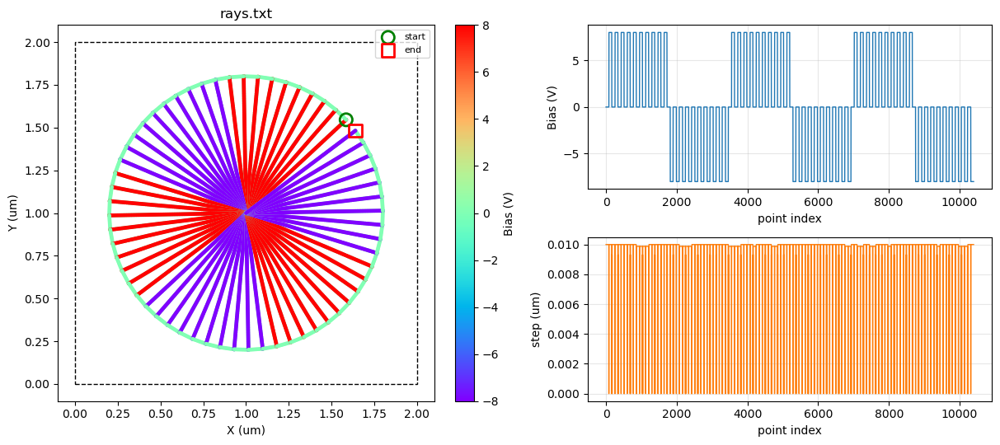

In [107]:
# example: 6-leaf flower in your 2 um frame

tb = gen_ray_sector_scan(n_sectors=6, rays_per_sector=10, radius_um=0.8,
                        center_um=(1.0, 1.), V_forw=0, V_back=8,
                        start_angle_deg=40.0, field_um=2.0, step_um=0.01, tb=None,
                        pts_per_ray=100, flip_sign=False,
                        both_directions_signed=True, sector_fill=0.9)

fname = os.path.join(CONFIG["work_dir"], "rays.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="rays.txt")

In [33]:
folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260625\20260625_PZTO"

exp = ae.Experiment(folder=folder)

In [116]:
ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')

ae.tune_probe(num=4, center=350e3, width=100e3)

In [117]:
exp.execute('ChangeName', "PZTO_VDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

True

In [ ]:
img_v = exp.load_ibw(folder=exp.folder)

In [111]:
cmd = 'XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n\
XPTButtonFunc("WriteXPT")\n\
XPTBoxFunc("DontChangeXPTCheck", 1)'

ae.write_spm(cmd)

time.sleep(2)

In [112]:
ae.tune_probe(num=4, center=650e3, width=100e3)

In [113]:
exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

img_l = exp.load_ibw(folder=exp.folder)

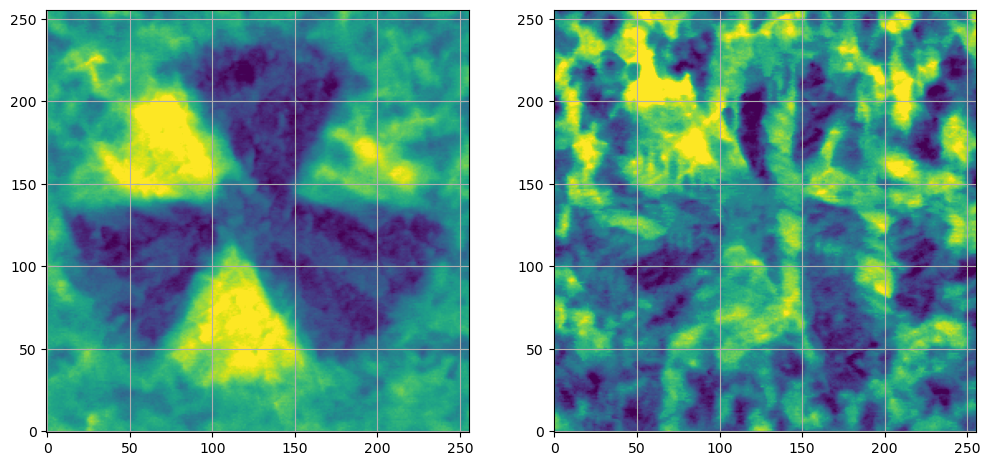

In [90]:
#img_l = exp.load_ibw(folder=exp.folder)

fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * np.cos(img_v.data[4] / 180 * np.pi)
tp2 = img_l.data[2] * np.cos(img_l.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

c1 = np.mean(tp2)
s1 = np.std(tp2)

ax[0].imshow(tp1, clim=[c-2/1*s, c+2/1*s], origin='lower', )
im = ax[1].imshow(tp2, clim=[c1-2/1*s1, c1+2/1*s1], origin='lower', )

# plt.colorbar(im, ax=ax[1])
ax[0].grid()
ax[1].grid()

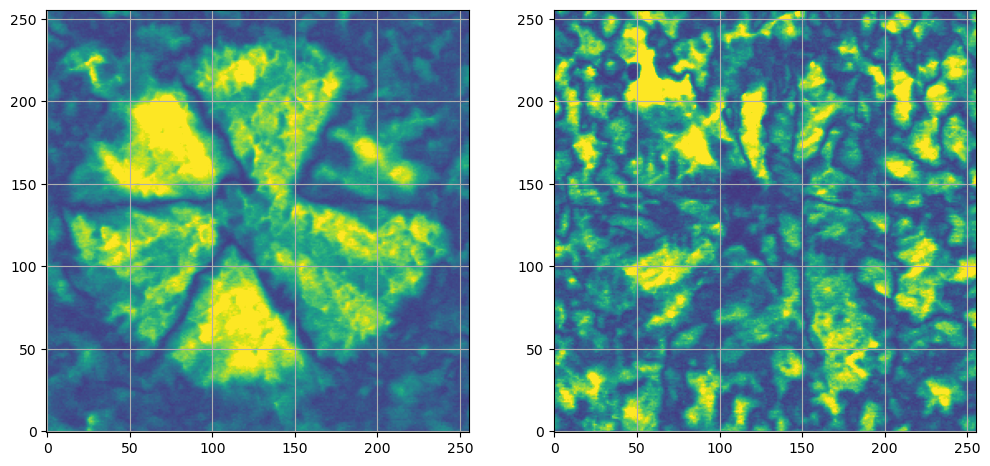

In [91]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * 1
tp2 = img_l.data[2] * 1
c = np.mean(tp1)
s = np.std(tp1)

c1 = np.mean(tp2)
s1 = np.std(tp2)

ax[0].imshow(tp1, clim=[c-2/1*s, c+2/1*s], origin='lower', )
im = ax[1].imshow(tp2, clim=[c1-2/1*s1, c1+2/1*s1], origin='lower', )

# plt.colorbar(im, ax=ax[1])
ax[0].grid()
ax[1].grid()

In [108]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rays.txt")


In [109]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [110]:
ae.write_spm(commands='TL_ToggleOverlay()')

## Line by line scan

In [118]:
import numpy as np


def gen_rotated_raster_backward(n_rows=10, pts_per_row=400, angle_deg=30.0,
                                v=-5.5, center_um=(1.0, 1.0), field_um=2.0,
                                step_um=0.01, tb=None, coverage=1.0,
                                serpentine=True):
    """Row-by-row (raster) poling pattern, rotated by an angle, voltage on the
    BACKWARD pass only.

    The raster is a regular grid of n_rows rows x pts_per_row columns.  The whole
    grid is ROTATED by angle_deg about the pattern center, but the scanned area is
    shrunk so the rotated grid still fits entirely inside the field_um x field_um
    square (a rotated square of side s fits inside a square of side field only if
    s <= field / (|cos| + |sin|); we use that bound, optionally scaled by coverage).

    Each row is traversed twice:
      * FORWARD pass  -> ZERO volts (no poling, just travel),
      * BACKWARD pass -> voltage v applied (DC) along the return.
    With serpentine=True the start side alternates per row (boustrophedon), so the
    tip doesn't fly back across the field between rows; the "backward" (poled) leg is
    always the second leg of each row regardless of direction.

    n_rows        : number of rows (slow-axis steps)
    pts_per_row   : samples per row (fast-axis resolution)
    angle_deg     : rotation of the whole raster about the center
    v             : DC voltage applied on the backward pass (signed)
    center_um     : (cx, cy) center of the pattern (and rotation center)
    field_um      : side of the square field the pattern must stay within
    coverage      : 0..1 fraction of the max in-square fitting size to actually use
                    (1.0 = largest rotated square that fits; <1 leaves a margin)
    serpentine    : True -> alternate row direction (no long flyback); the poled
                    backward leg is always the 2nd leg of the row.
                    False -> every row starts from the same side (forward leg has a
                    flyback); backward leg still the poled one.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)

    # largest axis-aligned square (centered) whose rotation by th fits in the field,
    # optionally scaled down by coverage to leave a margin.
    fit = field_um / (abs(c) + abs(s))
    side = float(np.clip(coverage, 1e-6, 1.0)) * fit
    half = side / 2.0

    n_rows = max(1, int(n_rows))
    pts_per_row = max(2, int(pts_per_row))

    # local (unrotated) grid coordinates, centered on origin, spanning +/- half
    if n_rows == 1:
        ys = np.array([0.0])
    else:
        ys = np.linspace(-half, half, n_rows, endpoint=True)     # slow axis
    xs = np.linspace(-half, half, pts_per_row, endpoint=True)     # fast axis

    def to_world(lx, ly):
        # rotate local (lx,ly) by th and translate to center
        wx = cx + lx * c - ly * s
        wy = cy + lx * s + ly * c
        return wx, wy

    for i, ly in enumerate(ys):
        # fast-axis order for this row (serpentine alternates the start side)
        if serpentine and (i % 2 == 1):
            row_x = xs[::-1]
        else:
            row_x = xs

        # FORWARD leg: zero volts
        fx, fy = to_world(row_x, np.full_like(row_x, ly))
        tb.stroke(np.column_stack([fx, fy]), np.zeros(pts_per_row, float))

        # BACKWARD leg (return along the same row): apply v
        bx, by = to_world(row_x[::-1], np.full_like(row_x, ly))
        tb.stroke(np.column_stack([bx, by]), np.full(pts_per_row, v, float))

    return tb

Wrote 24911 pts to 'output\lines.txt'  (path length 246.4 um, 80 strokes)


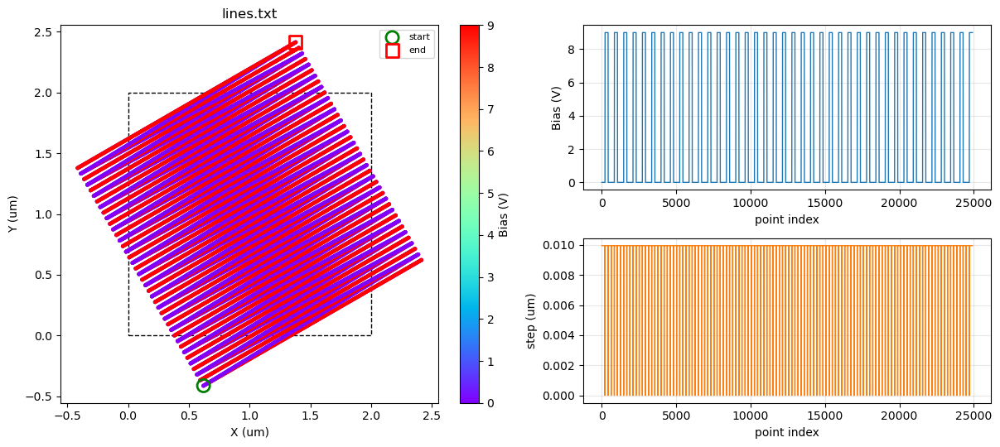

In [132]:
# example: 6-leaf flower in your 2 um frame

tb = gen_rotated_raster_backward(n_rows=40, pts_per_row=40, angle_deg=30.0,
                                v=9, center_um=(1.0, 1.0), field_um=2.0*np.sqrt(2),
                                step_um=0.01, tb=None, coverage=1.0,
                                serpentine=True)

fname = os.path.join(CONFIG["work_dir"], "lines.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="lines.txt")

In [133]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\lines.txt")


In [134]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')      # live scan center, 0.5 um/s

In [135]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

In [143]:
for i in range(10):
    exp.execute('ScanDown', wait=2)
    exp.check_files(wait=600)
    exp.execute('Stop')

# Example use of trajectorylitho functions

## Generate the file and load/build

Wrote 16384 points to 'spiral_live.txt'
  field = 2.0 um, center = (1.0, 1.0) um
  outer radius = 0.950 um, turns = 40
  X range: [0.062, 1.950] um
  Y range: [0.056, 1.932] um
  V = -6.0*sin(3.0*theta + 0) + 0.0
  V range: [-6.000, -6.000] V


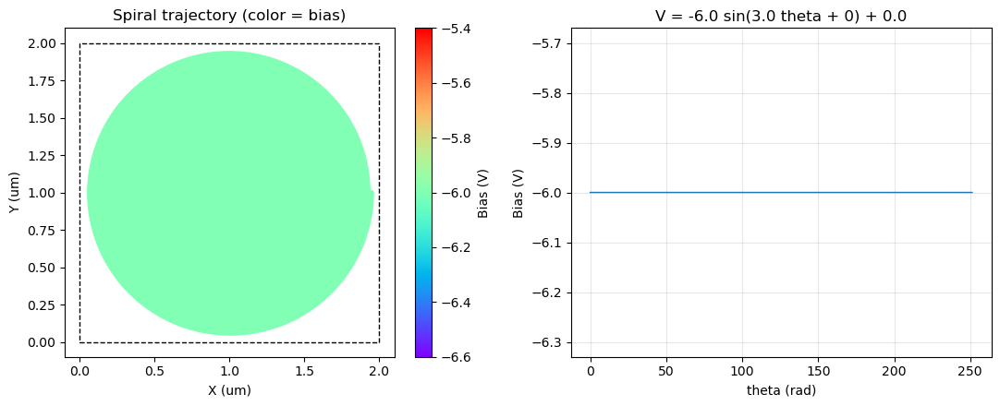

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\spiral_live.txt")


In [103]:
import os
fname = "spiral_live.txt"
generate_spiral_trajectory(
    turns=40, n_points=128**2, k=3.0, offset=0,
    v_amplitude=-6.0, v_offset=0.0, field_um=2.0,
    filename=fname,
    constant_v=True
)

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)

In [104]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Run with optional speed + center

In [ ]:
# Engage the tip first, then:

ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s
ae.write_spm(commands='TL_RunPy(2, 1, 5, 1)')        # manual center (5,1) um, 2 um/s
ae.write_spm(commands='TL_RunPy(0, 0, 0, 0)')        # keep current speed, live center

ae.write_spm(commands='TL_StopPy()')                  # stop

## Convenience wrapper + completion poll

In [ ]:
def run_trajectory(ae, txt=None, speed_ums=1.0, center=None):
    if txt:
        p = os.path.abspath(txt).replace("\\", "/")
        ae.write_spm(commands=f'TL_LoadBuildPy("{p}")')
    if center is None:
        ae.write_spm(commands=f'TL_RunPy({speed_ums}, 0, 0, 0)')
    else:
        ae.write_spm(commands=f'TL_RunPy({speed_ums}, 1, {center[0]}, {center[1]})')

# the run is async; poll LithoRunning (1=running, 0=done):
# ae.write_spm(commands='print GV("LithoRunning")')

# Working with real data


## Load the most recent PFM scan

In [ ]:
# Start a PFM scan

exp.execute('DownScan', wait=2)
exp.check_files(wait=600)

In [5]:
topo = exp.load_ibw()

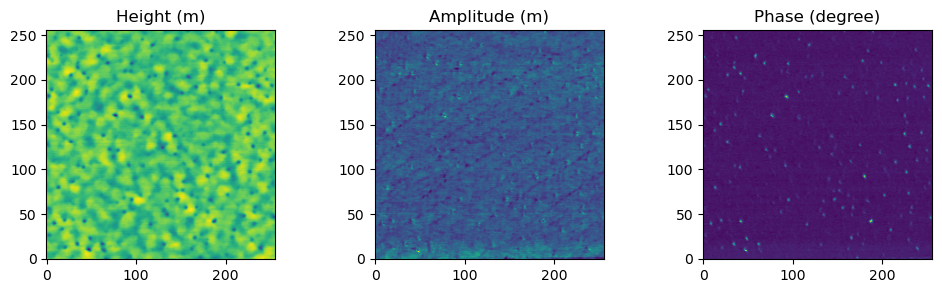

In [6]:
titles = ['Height (m)', 'Amplitude (m)', 'Phase (degree)']

fig, ax = plt.subplots(1,3,figsize=[10,3])
ax[0].imshow(topo.data[0], origin='lower')
ax[1].imshow(topo.data[1], origin='lower')
ax[2].imshow(topo.data[3], origin='lower')

for i, axis in enumerate(ax):
    axis.set_title(titles[i])
    
plt.tight_layout()

In [7]:
topo_ip = exp.load_ibw()

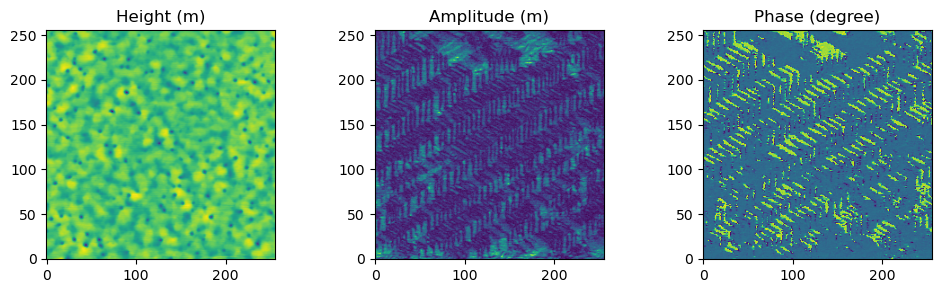

In [8]:
titles = ['Height (m)', 'Amplitude (m)', 'Phase (degree)']

fig, ax = plt.subplots(1,3,figsize=[10,3])
ax[0].imshow(topo_ip.data[0], origin='lower')
ax[1].imshow(topo_ip.data[1], origin='lower')
ax[2].imshow(topo_ip.data[3], origin='lower')

for i, axis in enumerate(ax):
    axis.set_title(titles[i])
    
plt.tight_layout()

## quadra-writing

In [1]:
def gen_quadrant_raster(tb, rect, retrace_angle_deg, pitch_um, v_write,
                        samp_um=0.005, constant_bias=False):
    """Serpentine fill: every line traced at 0 V against the named direction,
    then retraced at v_write ALONG it. rect = (x0, x1, y0, y1) in um."""
    x0, x1, y0, y1 = rect
    a = np.deg2rad(retrace_angle_deg)
    u = np.array([np.cos(a), np.sin(a)])          # biased (retrace) direction
    n = np.array([-u[1], u[0]])                   # line-stepping direction
    corners = np.array([[x0,y0],[x1,y0],[x0,y1],[x1,y1]])
    tmin, tmax = (corners@n).min(), (corners@n).max()
    smin, smax = (corners@u).min(), (corners@u).max()
    s = np.arange(smin, smax + samp_um, samp_um)
    for t in np.arange(tmin + pitch_um/2, tmax, pitch_um):
        pts = np.outer(s, u) + t*n
        ok = ((pts[:,0] >= x0) & (pts[:,0] <= x1) &
              (pts[:,1] >= y0) & (pts[:,1] <= y1))
        if ok.sum() < 2:
            continue
        i0, i1 = np.flatnonzero(ok)[[0, -1]]
        A, B = pts[i0], pts[i1]
        if constant_bias:
            tb.stroke(np.array([B, A]), 0)          # trace  (no bias)
        else:
            tb.stroke(np.array([B, A]), -v_write)          # trace  (no bias)
        tb.stroke(np.array([A, B]), v_write)      # retrace (biased, along arrow)
    return tb

FIELD, V_W, PITCH, GAP = 2.0, 9, 0.05, 0.06
h = FIELD/2
tb = TrajectoryBuilder(field_um=FIELD, step_um=0.01, travel_v=0.0)
quads = [   # visit order chosen so each exit lands near the next entry
    ((GAP,     h-GAP/2,   GAP,     h-GAP/2),    0.0),   # BL: left -> right
    ((h+GAP/2, FIELD-GAP, GAP,     h-GAP/2),   90.0),   # BR: down -> up
    ((h+GAP/2, FIELD-GAP, h+GAP/2, FIELD-GAP), 60.0),   # TR: 45 deg
    ((GAP,     h-GAP/2,   h+GAP/2, FIELD-GAP), 150.0),  # TL: 135 deg
]
for rect, ang in quads:
    gen_quadrant_raster(tb, rect, ang, PITCH, V_W)

fname = os.path.join(CONFIG["work_dir"], "quadrant_raster_2um.txt")
tb.save(fname)
visualize_trajectory(tb=tb, field_um=FIELD, title="4-quadrant trace/retrace test")

# at the scope:
# send_trajectory(fname); start_trajectory(speed_ums=1.0); wait_for_litho(tb, 1.0)
# then rescan lateral + vertical with identical settings and run the diff cell

NameError: name 'TrajectoryBuilder' is not defined

In [116]:
full_path = os.path.abspath(fname)       
full_path

'C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\quadrant_raster_2um.txt'

In [117]:
# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\quadrant_raster_2um.txt")


In [120]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

In [119]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [81]:
topo_ip2 = exp.load_ibw()

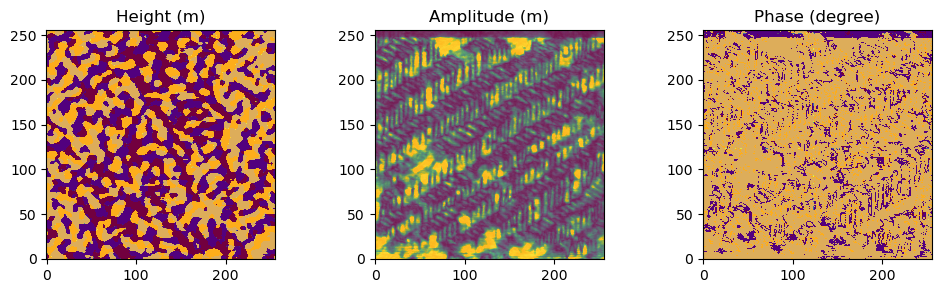

In [82]:
titles = ['Height (m)', 'Amplitude (m)', 'Phase (degree)']

fig, ax = plt.subplots(1,3,figsize=[10,3])

ax[0].imshow(topo_ip2.data[0], origin='lower', clim=[0, 1e-11])
ax[1].imshow(topo_ip2.data[1], origin='lower', clim=[0, 3e-10])
ax[2].imshow(topo_ip2.data[3], origin='lower', clim=[0, 1e-11])

ax[0].imshow(topo_ip.data[0], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 1e-11])
ax[1].imshow(topo_ip.data[1], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 3e-10])
ax[2].imshow(topo_ip.data[3], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 1e-11])

for i, axis in enumerate(ax):
    axis.set_title(titles[i])
    
plt.tight_layout()

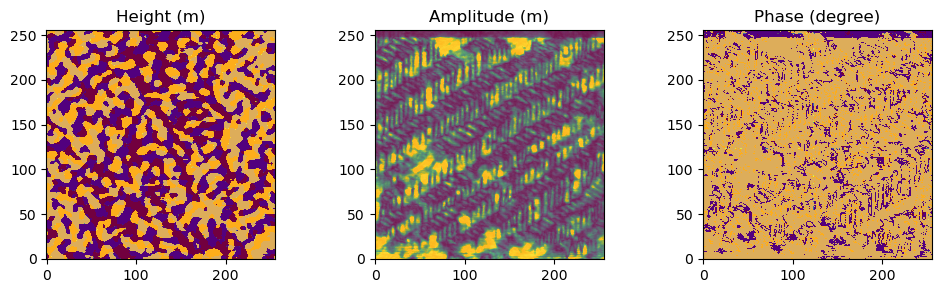

In [83]:
titles = ['Height (m)', 'Amplitude (m)', 'Phase (degree)']

fig, ax = plt.subplots(1,3,figsize=[10,3])

ax[0].imshow(topo_ip2.data[0], origin='lower', clim=[0, 1e-11])
ax[1].imshow(topo_ip2.data[1], origin='lower', clim=[0, 3e-10])
ax[2].imshow(topo_ip2.data[3], origin='lower', clim=[0, 1e-11])

ax[0].imshow(topo_ip.data[0], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 1e-11])
ax[1].imshow(topo_ip.data[1], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 3e-10])
ax[2].imshow(topo_ip.data[3], origin='lower', cmap=plt.cm.rainbow_r, alpha=0.25, clim=[0, 1e-11])

for i, axis in enumerate(ax):
    axis.set_title(titles[i])
    
plt.tight_layout()

In [64]:
tp = np.copy(topo_ip.data[1])
mask1 = np.where(np.abs(tp-np.mean(tp))>3*np.std(tp))
mask2 = np.where(np.abs(tp-np.mean(tp))<=3*np.std(tp))
tp[mask1] = np.nan
tp[mask2] = 1
len(mask[0])

730

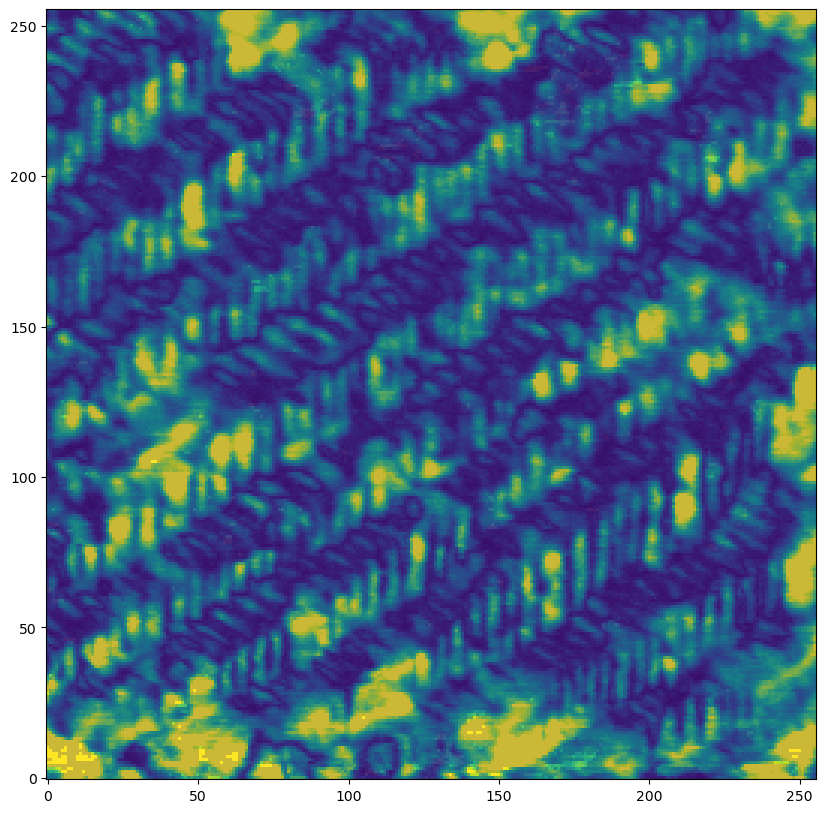

In [67]:
plt.figure(figsize=[10,10])
plt.imshow(topo_ip2.data[1], origin='lower', clim=[0, 3e-10])
plt.imshow(tp, origin='lower', cmap=plt.cm.jet, alpha=0.2)


In [68]:
tp

array([[ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1., nan, nan, ...,  1.,  1.,  1.],
       ...,
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.]], dtype=float32)

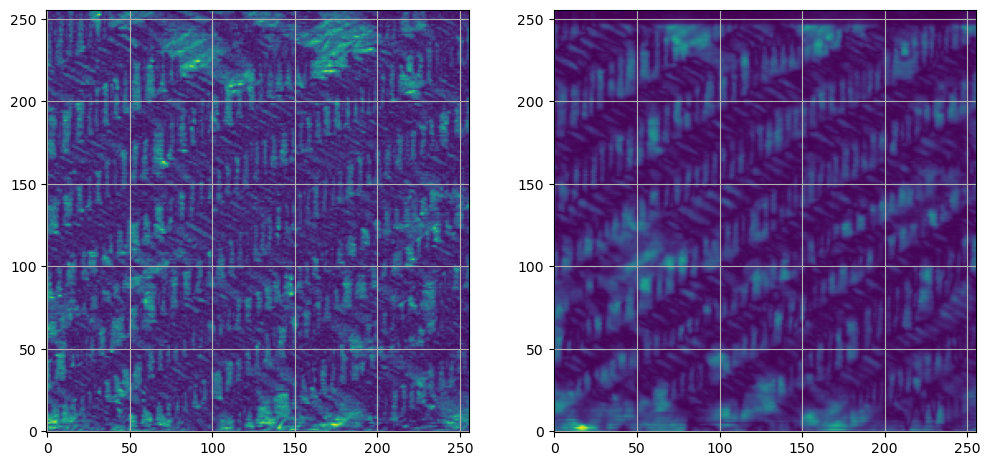

In [85]:
fig, ax = plt.subplots(1,2, figsize=(12,8))

ax[0].imshow(topo_ip.data[1], origin='lower')
ax[1].imshow(topo_ip2.data[1], origin='lower')

ax[0].grid()
ax[1].grid()

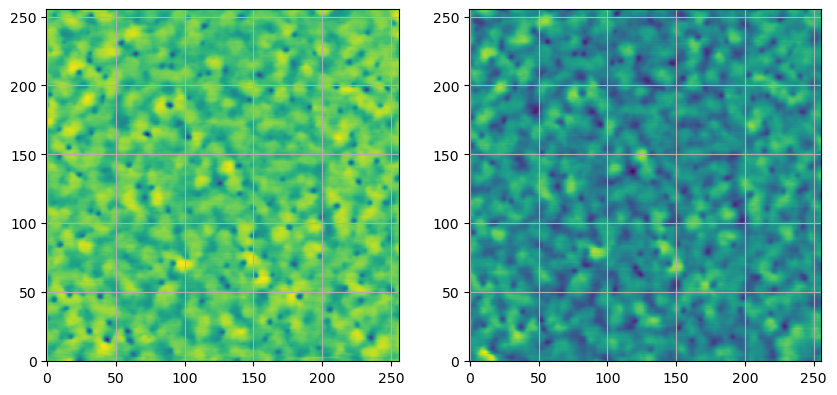

In [87]:
fig, ax = plt.subplots(1,2, figsize=(10,20))

ax[0].imshow(topo_ip.data[0], origin='lower')
ax[1].imshow(topo_ip2.data[0], origin='lower')
# ax[0].plot(48, 22, 'rx', ms=8)
# ax[1].plot(65, 8, 'rx', ms=8)

ax[0].grid()
ax[1].grid()

In [78]:
np.array([48-65, 22-8]) * 2e3 / 256

array([-132.8125,  109.375 ])

In [79]:
-43.26-132.8

-176.06

In [80]:
-1450+109.375

-1340.625

## Flower-type traj

In [8]:
def gen_rose_flower(n_leaves=6, radius_um=0.8, center_um=(1.0, 1.0), v=-5.5,
                    chirality='ccw', start_angle_deg=0.0, layers=1,
                    bias_on_outward_only=False, field_um=2.0, step_um=0.01,
                    tb=None, pts_per_leaf=400):
    """Continuous rhodonea ('rose') flower: r = R|cos(N*theta/2)| traces exactly
    N leaves in one smooth closed loop, passing through the center between
    leaves. n_leaves works for ANY integer >= 1.

    layers > 1            : repeats at shrinking radii (R, R*(L-1)/L, ...) for a
                            denser fill — still one continuous path
    chirality             : 'ccw' / 'cw' leaf visiting order
    start_angle_deg       : rotates the flower (align leaves to easy axes)
    bias_on_outward_only  : bias only on the center->tip half of each leaf,
                            0 V on the way back -> one clean radial writing
                            direction per leaf
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    sgn = 1.0 if chirality == 'ccw' else -1.0
    cx, cy = center_um
    n_pts = int(pts_per_leaf * n_leaves)
    for L in range(layers, 0, -1):
        R = radius_um * L / layers
        th = np.pi / n_leaves + np.linspace(0, 2*np.pi, n_pts, endpoint=True)
        r = R * np.abs(np.cos(n_leaves * th / 2))      # N zeros -> N leaves
        phi = sgn * th + np.deg2rad(start_angle_deg)
        x, y = cx + r*np.cos(phi), cy + r*np.sin(phi)
        if np.isscalar(v) and bias_on_outward_only:
            vv = np.where(np.gradient(r) > 0, v, 0.0)
        else:
            vv = np.full(n_pts, v, float)
        tb.stroke(np.column_stack([x, y]), vv)
    return tb

# # example: 6-leaf flower in your 2 um frame
# tb = gen_rose_flower(n_leaves=96, radius_um=0.8, center_um=(1, 1), v=-9)
# fname = os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt")
# tb.save(fname)

# # tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
# visualize_trajectory(tb=tb, field_um=2.0, title="rose flower, N=6")

In [129]:
# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N6_2um.txt")


In [131]:
ae.write_spm(commands='TL_ToggleOverlay()')

In [130]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')      # live scan center, 0.5 um/s

## Start from fresh area

In [4]:
# Square patterns

FIELD, V_W, PITCH, GAP = 2.0, 9, 0.05, 0.06
h = FIELD/2
tb = TrajectoryBuilder(field_um=FIELD, step_um=0.01, travel_v=0.0)
quads = [   # visit order chosen so each exit lands near the next entry
    ((GAP,     h-GAP/2,   GAP,     h-GAP/2),    0.0),   # BL: left -> right
    ((h+GAP/2, FIELD-GAP, GAP,     h-GAP/2),   90.0),   # BR: down -> up
    ((h+GAP/2, FIELD-GAP, h+GAP/2, FIELD-GAP), 60.0),   # TR: 45 deg
    ((GAP,     h-GAP/2,   h+GAP/2, FIELD-GAP), 150.0),  # TL: 135 deg
]
for rect, ang in quads:
    gen_quadrant_raster(tb, rect, ang, PITCH, V_W, constant_bias=True)

fname = os.path.join(CONFIG["work_dir"], "quadrant_raster_2um.txt")
tb.save(fname)
visualize_trajectory(tb=tb, field_um=FIELD, title="4-quadrant trace/retrace test")


NameError: name 'np' is not defined

Wrote 15347 pts to 'output\rose_flower_N6_2um.txt'  (path length 152.7 um, 1 strokes)


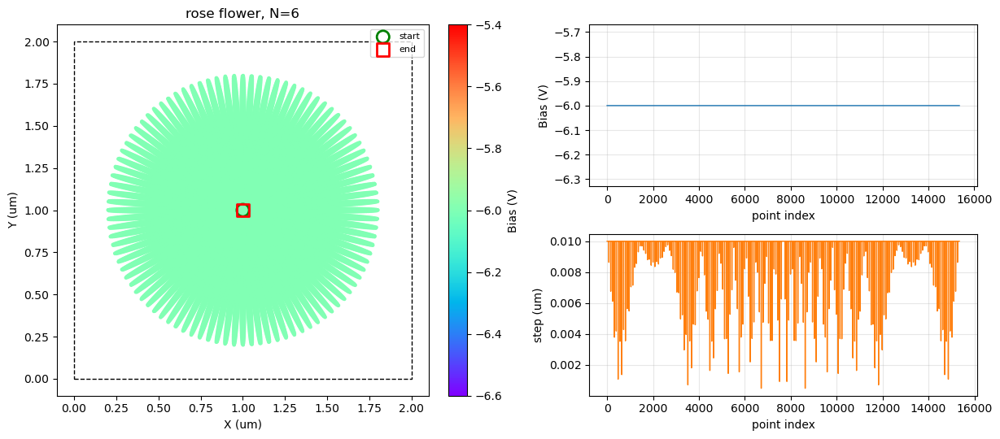

In [162]:
# example: 6-leaf flower in your 2 um frame

tb = gen_rose_flower(n_leaves=96, radius_um=0.8, center_um=(1, 1), v=-6)
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="rose flower, N=6")

In [166]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N6_2um.txt")


In [168]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

In [167]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [171]:
img1 = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260612\PZTO_MOBO_DKL\PZTO_DART_0000.ibw")
img2 = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260612\PZTO_MOBO_DKL\PZTO_SS_0006.ibw")

In [172]:
tp1 = img1.data[1]*np.cos(img1.data[3]/180*np.pi) * 1e9
tp2 = img2.data[1]*np.cos(img2.data[4]/180*np.pi) * 1e9

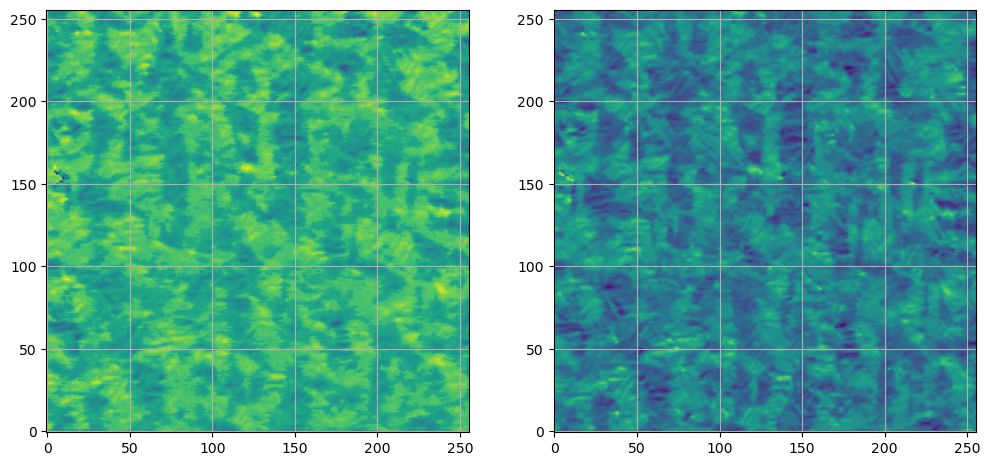

In [173]:
fig, ax = plt.subplots(1,2, figsize=(12,8))

ax[0].imshow(tp1, origin='lower')
ax[1].imshow(tp2, origin='lower')

ax[0].grid()
ax[1].grid()

Wrote 27129 pts to 'output\rose_flower_N6_2um.txt'  (path length 270.5 um, 1 strokes)


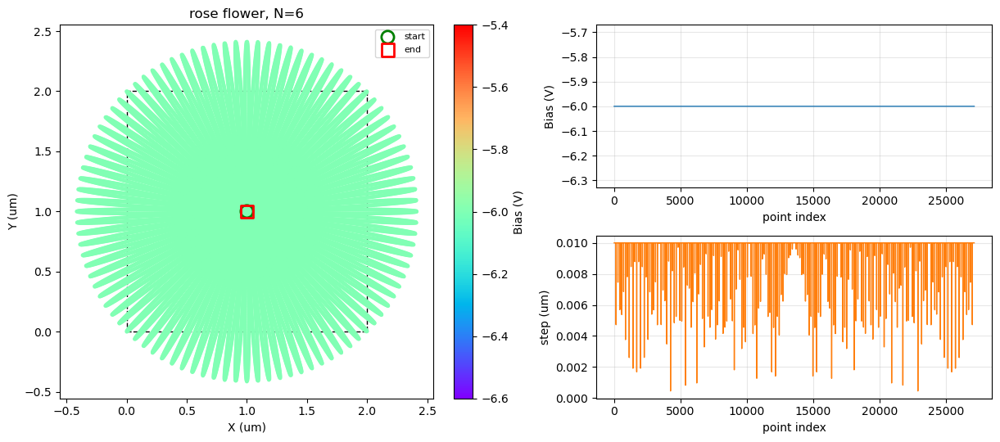

In [176]:
# example: 6-leaf flower in your 2 um frame

tb = gen_rose_flower(n_leaves=96, radius_um=1*np.sqrt(2), center_um=(1, 1), v=-6)
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2.0, title="rose flower, N=6")

In [177]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N6_2um.txt")


In [178]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [179]:
ae.write_spm(commands='TL_ToggleOverlay()')

In [9]:
def gen_rose_flower(n_leaves=6, radius_um=0.8, center_um=(1.0, 1.0), v=-5.5,
                    chirality='ccw', start_angle_deg=0.0, layers=1,
                    bias_on_outward_only=False, signed_radial_bias=True,
                    field_um=2.0, step_um=0.01,
                    tb=None, pts_per_leaf=400):
    """Continuous rhodonea ('rose') flower: r = R|cos(N*theta/2)| traces exactly
    N leaves in one smooth closed loop, passing through the center between
    leaves. n_leaves works for ANY integer >= 1.
    layers > 1            : repeats at shrinking radii (R, R*(L-1)/L, ...) for a
                            denser fill — still one continuous path
    chirality             : 'ccw' / 'cw' leaf visiting order
    start_angle_deg       : rotates the flower (align leaves to easy axes)
    signed_radial_bias    : +v on the center->tip (outbound) half of each leaf,
                            -v on the tip->center (inbound) half -> opposite poling
                            polarity for the two radial writing directions.
                            Takes precedence over bias_on_outward_only.
    bias_on_outward_only  : (only if signed_radial_bias is False) bias only on the
                            center->tip half, 0 V on the way back.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    sgn = 1.0 if chirality == 'ccw' else -1.0
    cx, cy = center_um
    n_pts = int(pts_per_leaf * n_leaves)
    for L in range(layers, 0, -1):
        R = radius_um * L / layers
        th = np.pi / n_leaves + np.linspace(0, 2*np.pi, n_pts, endpoint=True)
        r = R * np.abs(np.cos(n_leaves * th / 2))      # N zeros -> N leaves
        phi = sgn * th + np.deg2rad(start_angle_deg)
        x, y = cx + r*np.cos(phi), cy + r*np.sin(phi)
        dr = np.gradient(r)
        if np.isscalar(v) and signed_radial_bias:
            vv = np.where(dr > 0, v, -v)               # +v outbound, -v inbound
        elif np.isscalar(v) and bias_on_outward_only:
            vv = np.where(dr > 0, v, 0.0)
        else:
            vv = np.full(n_pts, v, float)
        tb.stroke(np.column_stack([x, y]), vv)
    return tb

Wrote 14378 pts to 'output\rose_flower_N6_4um.txt'  (path length 712.9 um, 1 strokes)


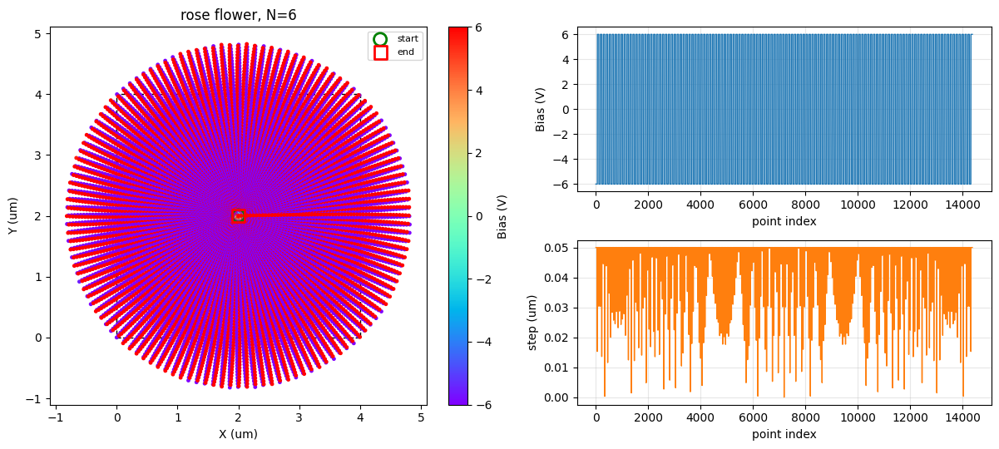

In [15]:
# example: 6-leaf flower in your 2 um frame

tb = gen_rose_flower(n_leaves=128, radius_um=2*np.sqrt(2), center_um=(2, 2), v=-6, field_um=4, step_um=0.05, pts_per_leaf=100)
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N6_4um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=4.0, title="rose flower, N=6")

In [19]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N6_4um.txt")


In [17]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')      # live scan center, 0.5 um/s

In [18]:
ae.write_spm(commands='TL_ToggleOverlay()')

In [10]:
def gen_diameter_scan(n_lines=6, radius_um=0.8, center_um=(1.0, 1.0), v=-5.5,
                      start_angle_deg=0.0, signed_pass_bias=True,
                      field_um=2.0, step_um=0.01, tb=None, pts_per_line=400):
    """Diameter-scan poling pattern.

    Each line is a full DIAMETER: from one edge, through the center, to the opposite
    edge. The line is written twice -- forward (edge A -> edge B) at -|v| and back
    (edge B -> edge A) at +|v| -- then the angle advances to the next diameter.
    Because a diameter at theta and theta+180 deg are the same line, the angles span
    only [0, 180) deg: n_lines diameters at 0, 180/n, 2*180/n, ...

    n_lines           : number of distinct diameter orientations (over 180 deg)
    radius_um         : half-length of each diameter (diameter length = 2*radius_um)
    center_um         : (cx, cy) center of the pattern
    v                 : pulse magnitude; sign is set per-pass (see signed_pass_bias).
                        Its absolute value is what matters; the forward pass uses
                        -|v|, the return pass +|v|.
    start_angle_deg   : rotates the whole pattern (align to easy axes)
    signed_pass_bias  : True  -> forward pass at -|v|, return pass at +|v|
                        False -> both passes at v (no sign flip)
    pts_per_line      : samples along one diameter traversal (one direction)
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R = radius_um
    vmag = abs(v)

    # diameter orientations over 180 deg only (theta and theta+180 are the same line)
    angles = np.deg2rad(start_angle_deg) + np.linspace(0, np.pi, n_lines, endpoint=False)

    for phi in angles:
        ux, uy = np.cos(phi), np.sin(phi)          # unit vector along this diameter

        # parametrize from -R (edge A) to +R (edge B)
        t = np.linspace(-R, R, pts_per_line, endpoint=True)
        xf = cx + t * ux
        yf = cy + t * uy

        # forward pass: edge A -> edge B at -|v|
        v_fwd = (-vmag if signed_pass_bias else v)
        tb.stroke(np.column_stack([xf, yf]), np.full(pts_per_line, v_fwd, float))

        # return pass: edge B -> edge A at +|v|  (reverse the same points)
        v_ret = (+vmag if signed_pass_bias else v)
        tb.stroke(np.column_stack([xf[::-1], yf[::-1]]), np.full(pts_per_line, v_ret, float))

    return tb

Wrote 15036 pts to 'output\rose_flower_N64_4um.txt'  (path length 732.8 um, 128 strokes)


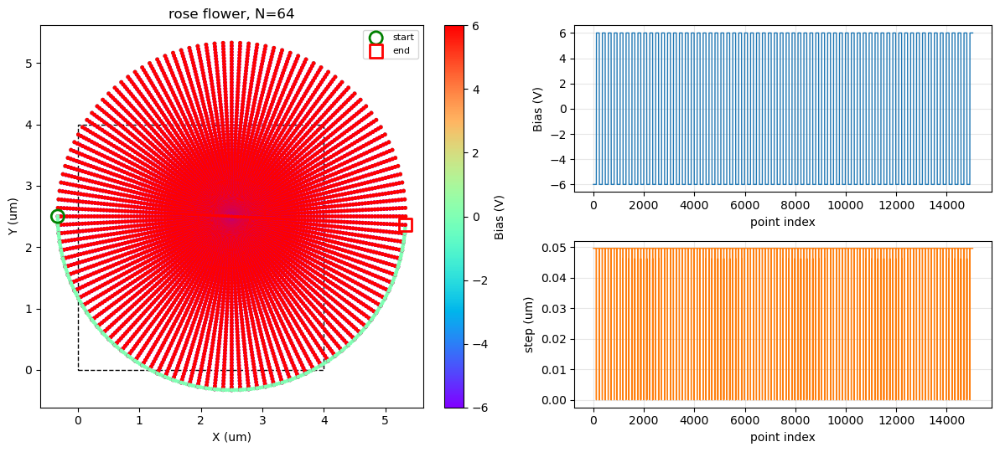

In [13]:
# example: 6-leaf flower in your 2 um frame

tb = gen_diameter_scan(n_lines=64, radius_um=2*np.sqrt(2), center_um=(2.5, 2.5), v=6, field_um=4, step_um=0.05, pts_per_line=100)
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_4um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=4.0, title="rose flower, N=64")

In [14]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_4um.txt")


In [15]:
ae.write_spm(commands='TL_RunPy(0.5, 0, 0, 0)')      # live scan center, 0.5 um/s

In [16]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')